# ML4N Project 9 - Patterns in encrypted HTTPS traffic

In [1]:
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/ml4n_mplconfig")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, RobustScaler, label_binarize
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,


)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

from sklearn.linear_model import Lasso

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

# ---------------------------------------------------------------------------
# Reproducibility and runtime controls
# ---------------------------------------------------------------------------
RANDOM_STATE = 42

PLOT_SAMPLE = 12_000
TSNE_SAMPLE = 50_000
CLASSIFICATION_TUNING_SAMPLE = 12_000
REGRESSION_TUNING_SAMPLE = 12_000
CV_SAMPLE = 25_000

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
np.random.seed(RANDOM_STATE)

## 1. Data Loading And Shared Preprocessing

The official files are already split into training and test sets. We keep that split fixed throughout the notebook to avoid leakage from the test set into preprocessing, feature selection, model tuning or model selection.


In [2]:
train_raw = pd.read_csv('https_training.csv')
test_raw = pd.read_csv('https_test.csv')

print(f"Training set: {train_raw.shape[0]:,} rows, {train_raw.shape[1]} columns")
print(f"Test set:     {test_raw.shape[0]:,} rows, {test_raw.shape[1]} columns")
print(f"Training labels: {train_raw['label'].nunique()} domain names")
print(f"Test labels:     {test_raw['label'].nunique()} domain names")

raw_audit = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train_raw), len(test_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1]],
    "missing_values": [train_raw.isna().sum().sum(), test_raw.isna().sum().sum()],
    "duplicate_rows": [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    "domain_labels": [train_raw["label"].nunique(), test_raw["label"].nunique()],
    "client_ips": [train_raw["c_ip"].nunique(), test_raw["c_ip"].nunique()],
})
display(raw_audit)

display(train_raw.head(3))

Training set: 147,863 rows, 123 columns
Test set:     114,580 rows, 123 columns
Training labels: 26 domain names
Test labels:     26 domain names


,dataset,rows,columns,missing_values,duplicate_rows,domain_labels,client_ips
0,train,147863,123,0,0,26,738
1,test,114580,123,0,0,26,788


,_c_ack_cnt,_c_ack_cnt_p,_c_appdataB,_c_appdataT,_c_bytes_all,_c_bytes_retx,_c_bytes_uniq,_c_cwin_ini,_c_cwin_max,_c_cwin_min,_c_fin_cnt,_c_first,_c_first_ack,_c_last,_c_last_handshakeT,_c_msgsize1,_c_msgsize_count,_c_mss,_c_mss_max,_c_mss_min,_c_pkts_all,_c_pkts_data,_c_pkts_data_avg,_c_pkts_data_std,_c_pkts_dup,_c_pkts_fc,_c_pkts_ooo,_c_pkts_push,_c_pkts_reor,_c_pkts_retx,_c_pkts_rto,_c_pkts_unfs,_c_pkts_unk,_c_pkts_unrto,_c_pktsize1,_c_pktsize_count,_c_port,_c_rst_cnt,_c_rtt_avg,_c_rtt_cnt,_c_rtt_max,_c_rtt_min,_c_rtt_std,_c_sack_cnt,_c_sack_opt,_c_seg_cnt,_c_sit1,_c_sit_avg,_c_sit_std,_c_syn_cnt,_c_syn_retx,_c_tm_opt,_c_ttl_max,_c_ttl_min,_c_win_0,_c_win_max,_c_win_min,_c_win_scl,_durat,_s_ack_cnt,...,_s_bytes_all,_s_bytes_retx,_s_bytes_uniq,_s_cwin_ini,_s_cwin_max,_s_cwin_min,_s_f1323_opt,_s_fin_cnt,_s_first,_s_first_ack,_s_last,_s_last_handshakeT,_s_msgsize1,_s_msgsize_count,_s_mss,_s_mss_max,_s_mss_min,_s_pkts_all,_s_pkts_data,_s_pkts_data_avg,_s_pkts_data_std,_s_pkts_dup,_s_pkts_fc,_s_pkts_fs,_s_pkts_ooo,_s_pkts_push,_s_pkts_reor,_s_pkts_retx,_s_pkts_rto,_s_pkts_unfs,_s_pkts_unk,_s_pkts_unrto,_s_pktsize1,_s_pktsize_count,_s_port,_s_rst_cnt,_s_rtt_avg,_s_rtt_cnt,_s_rtt_max,_s_rtt_min,_s_rtt_std,_s_sack_cnt,_s_sack_opt,_s_seg_cnt,_s_sit1,_s_sit_avg,_s_sit_std,_s_syn_cnt,_s_syn_retx,_s_tm_opt,_s_ttl_max,_s_ttl_min,_s_win_0,_s_win_max,_s_win_min,_s_win_scl,_tls_session_stat,c_ip,time,label
0,8.0,4.0,569.0,522.003,1672.0,0.0,1672.0,517.0,590.0,51.0,0.0,51.545,42.635,7998.583,91.370,517.0,4.0,1460.0,590.0,51.0,9.0,4.0,418.00,247.177399,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,517.0,4.0,59903.0,0.0,21.707766,5.0,50.633,2.457,24.984218,1.0,1.0,4.0,39.825,2649.012667,4185.359900,1.0,0.0,1.0,59.0,59.0,0.0,91328.0,65535.0,6.0,8408.433,9.0,...,2066.0,773.0,1293.0,160.0,773.0,160.0,1.0,0.0,56.003,54.002,8382.032,56.003,160.0,3.0,1396.0,773.0,160.0,9.0,4.0,516.500,307.229013,0.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,160.0,4.0,443.0,0.0,52.354922,3.0,84.444,33.993,27.885124,0.0,1.0,4.0,470.001,2775.343000,4165.619085,1.0,0.0,1.0,59.0,59.0,0.0,31232.0,27680.0,9.0,1.0,67.32.225.92,1.561932e+09,krxd.net
1,10.0,7.0,275.0,39.504,636.0,0.0,636.0,181.0,362.0,1.0,0.0,4.630,3.086,39.504,32.202,181.0,3.0,1460.0,362.0,93.0,11.0,3.0,212.00,137.153199,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,181.0,3.0,57142.0,0.0,14.712132,4.0,46.291,3.169,21.077462,0.0,1.0,3.0,27.572,17.437000,14.333054,1.0,0.0,1.0,62.0,62.0,0.0,51208.0,29200.0,0.0,161.798,11.0,...,7845.0,0.0,7845.0,0.0,6774.0,258.0,0.0,0.0,9.799,7.799,161.798,37.798,6774.0,4.0,1396.0,1384.0,194.0,11.0,8.0,980.625,533.027187,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1384.0,8.0,443.0,0.0,0.959986,7.0,1.706,0.184,0.473252,0.0,1.0,8.0,0.000,21.714143,46.295097,1.0,0.0,1.0,59.0,59.0,0.0,29480.0,27680.0,0.0,0.0,67.32.181.213,1.561932e+09,_other
2,7.0,3.0,569.0,110.003,3325.0,0.0,3325.0,517.0,1435.0,51.0,0.0,32.562,27.002,122.256,61.999,517.0,3.0,1460.0,1384.0,51.0,8.0,4.0,831.25,659.941601,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,517.0,4.0,57831.0,0.0,12.239355,5.0,48.006,2.003,20.008976,0.0,1.0,4.0,29.437,29.898000,17.879958,1.0,0.0,1.0,59.0,59.0,0.0,91584.0,65535.0,6.0,222.823,7.0,...,1513.0,0.0,1513.0,160.0,1353.0,160.0,1.0,0.0,38.003,36.003,156.005,38.003,160.0,2.0,1396.0,1353.0,160.0,7.0,2.0,756.500,843.578390,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,160.0,2.0,443.0,0.0,37.272424,3.0,66.818,22.000,25.591058,0.0,1.0,2.0,118.002,118.002000,0.000000,1.0,0.0,1.0,59.0,59.0,0.0,34304.0,27680.0,9.0,1.0,67.32.225.92,1.561932e+09,contextweb.com


The raw data contains only numeric Tstat flow features plus `c_ip`, `time` and `label`. The first audit checks the conditions that would make later processing unsafe: missing values, duplicate rows, inconsistent labels, and client/domain cardinalities.


In [3]:
def numeric_feature_columns(df):
    """Return Tstat numeric feature columns, i.e. columns whose names start with '_' ."""
    return [c for c in df.columns if c.startswith("_")]


def clean_split(train_df, test_df):
    """Clean train/test consistently while fitting every decision on train only."""
    train = train_df.drop_duplicates().dropna().copy().reset_index(drop=True)
    test = test_df.drop_duplicates().dropna().copy().reset_index(drop=True)

    numeric_cols = numeric_feature_columns(train)
    constant_cols = [c for c in numeric_cols if train[c].nunique(dropna=False) <= 1]

    train = train.drop(columns=constant_cols)
    test = test.drop(columns=[c for c in constant_cols if c in test.columns])

    # Domain Knowledge feature pruning:
    # 1. Ports are categorical identifiers, not numerical features.
    domain_drop = ['_c_port', '_s_port']
    train = train.drop(columns=[c for c in domain_drop if c in train.columns])
    test = test.drop(columns=[c for c in domain_drop if c in test.columns])

    audit = {
        "dropped_constant_columns": constant_cols,
        "dropped_domain_columns": domain_drop,
        "train_rows_after_cleaning": len(train),
        "test_rows_after_cleaning": len(test),
        "server_rtt_zero_train": int((train["_s_rtt_avg"] == 0).sum()) if "_s_rtt_avg" in train.columns else 0,
        "server_rtt_zero_test": int((test["_s_rtt_avg"] == 0).sum()) if "_s_rtt_avg" in test.columns else 0,
    }
    return train, test, audit


def prune_correlated_features(X_train, threshold=0.95):
    """Drop one feature from each highly correlated pair, using train only.
    We prefer retaining '_mean' features over '_max' or '_min'.
    """
    # Sort columns so that '_mean' features appear first.
    # The upper triangle logic drops features that appear later in the list.
    sorted_cols = sorted(X_train.columns, key=lambda c: (not 'mean' in c.lower(), c))
    X_sorted = X_train[sorted_cols]

    corr = X_sorted.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    selected = [c for c in X_sorted.columns if c not in to_drop]
    return selected, to_drop


def build_model_matrix(train_df, test_df, target_col="label", drop_cols=None, corr_threshold=0.95):
    """Create a log-scaled, correlation-pruned, standardized matrix fitted on train only."""
    drop_cols = set(drop_cols or []) | {target_col, "label", "c_ip", "time"}
    candidate_cols = [c for c in numeric_feature_columns(train_df) if c not in drop_cols]

    X_train_log = np.log1p(train_df[candidate_cols].clip(lower=0))
    X_test_log = np.log1p(test_df[candidate_cols].clip(lower=0))

    selected_cols, corr_dropped = prune_correlated_features(X_train_log, threshold=corr_threshold)
    X_train_log = X_train_log[selected_cols]
    X_test_log = X_test_log[selected_cols]

    # RobustScaler is robust to the heavy-tailed outliers typical in network traffic
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_log)
    X_test_scaled = scaler.transform(X_test_log)

    X_train_model = pd.DataFrame(X_train_scaled, columns=selected_cols, index=train_df.index)
    X_test_model = pd.DataFrame(X_test_scaled, columns=selected_cols, index=test_df.index)

    info = {
        "candidate_features": len(candidate_cols),
        "selected_features": len(selected_cols),
        "correlation_dropped": corr_dropped,
        "scaler": scaler,
    }
    return X_train_model, X_test_model, info


train_clean, test_clean, preprocessing_audit = clean_split(train_raw, test_raw)
X_train_model, X_test_model, model_info = build_model_matrix(train_clean, test_clean)
y_train = train_clean["label"].copy()
y_test = test_clean["label"].copy()

summary = pd.DataFrame({
    "item": [
        "train rows after cleaning",
        "test rows after cleaning",
        "constant columns removed",
        "domain knowledge columns removed",
        "candidate numeric model features",
        "features after correlation pruning",
        "server RTT equal to zero in train",
    ],
    "value": [
        preprocessing_audit["train_rows_after_cleaning"],
        preprocessing_audit["test_rows_after_cleaning"],
        len(preprocessing_audit["dropped_constant_columns"]),
        len(preprocessing_audit["dropped_domain_columns"]),
        model_info["candidate_features"],
        model_info["selected_features"],
        preprocessing_audit["server_rtt_zero_train"],
    ],
})
display(summary)
print("Constant columns removed:")
print(preprocessing_audit["dropped_constant_columns"])
print(f"Correlation-pruned columns: {len(model_info['correlation_dropped'])}")


,item,value
0,train rows after cleaning,147863
1,test rows after cleaning,114580
2,constant columns removed,9
3,domain knowledge columns removed,2
4,candidate numeric model features,110
5,features after correlation pruning,79
6,server RTT equal to zero in train,31


Constant columns removed:
['_c_pkts_fc', '_c_pkts_unfs', '_c_sack_opt', '_c_syn_retx', '_s_pkts_unfs', '_s_port', '_s_sack_opt', '_s_syn_retx', '_s_win_0']
Correlation-pruned columns: 31


The dataset has no missing values and no duplicate rows, so cleaning does not discard informative observations. Constant features are removed because they cannot help any classifier, regressor or clustering algorithm. Network-flow measurements are heavy-tailed, therefore numeric features are transformed with `log1p` before scaling; this compresses extreme byte/packet/duration values while preserving zeros. Correlation pruning is fitted on the training set only, so the test set remains unseen. `c_ip`, `time` and `label` are excluded from predictive feature matrices to avoid memorizing clients, timestamps or the target itself.

Rows with `_s_rtt_avg == 0` are not removed globally, because they are valid rows for EDA/classification/clustering. They are removed only in the RTT regression task, exactly where the specification requires it.

In [4]:
def build_level_aggregates(df):
    numeric_cols = numeric_feature_columns(df)
    ip_level = df.groupby("c_ip")[numeric_cols].mean()
    ip_level["flow_count"] = df.groupby("c_ip").size()
    ip_level["domain_count"] = df.groupby("c_ip")["label"].nunique()

    domain_level = df.groupby("label")[numeric_cols].mean()
    domain_level["flow_count"] = df.groupby("label").size()
    domain_level["unique_ips"] = df.groupby("label")["c_ip"].nunique()

    return ip_level, domain_level

ip_level, domain_level = build_level_aggregates(train_clean)

print(f"Flow level rows:   {len(train_clean):,}")
print(f"IP level rows:     {len(ip_level):,}")
print(f"Domain level rows: {len(domain_level):,}")

display(domain_level[["flow_count", "unique_ips", "_s_bytes_all", "_s_rtt_avg", "_durat"]]
        .sort_values("flow_count", ascending=False)
        .head(12))


Flow level rows:   147,863
IP level rows:     738
Domain level rows: 26


,flow_count,unique_ips,_s_bytes_all,_s_rtt_avg,_durat
label,,,,,
_other,35083,615,439105.069008,325.875353,145383.631219
scdn.co,25322,103,946607.316089,143.718459,265087.353846
taboola.com,21018,431,172617.867780,458.902233,104987.150445
krxd.net,11144,325,11186.676328,347.624240,98630.660262
outbrain.com,5637,349,59900.991130,599.505653,166837.207330
githubusercontent.com,4271,147,87859.561695,744.574257,150028.200823
giphy.com,3886,23,532018.393721,58.598729,53323.693444
adnxs.com,3839,233,31287.114092,329.285696,87006.696000
reddit.com,3457,48,196562.028348,183.377016,81178.010435


For the IP and domain-name levels, features are merged by averaging numeric flow statistics and adding count variables (`flow_count`, number of contacted domains per IP, number of unique IPs per domain). This keeps the interpretation simple: a row represents the typical behavior of a client or domain plus its popularity in the trace.


## 1.1 Exploratory Data Analysis

The EDA focuses on distributions, class imbalance, correlations, bytes/RTT behavior, and low-dimensional projections at the three requested levels.


,flows,percentage
label,,
_other,35083,23.73
scdn.co,25322,17.13
taboola.com,21018,14.21
krxd.net,11144,7.54
outbrain.com,5637,3.81
githubusercontent.com,4271,2.89
giphy.com,3886,2.63
adnxs.com,3839,2.60
reddit.com,3457,2.34


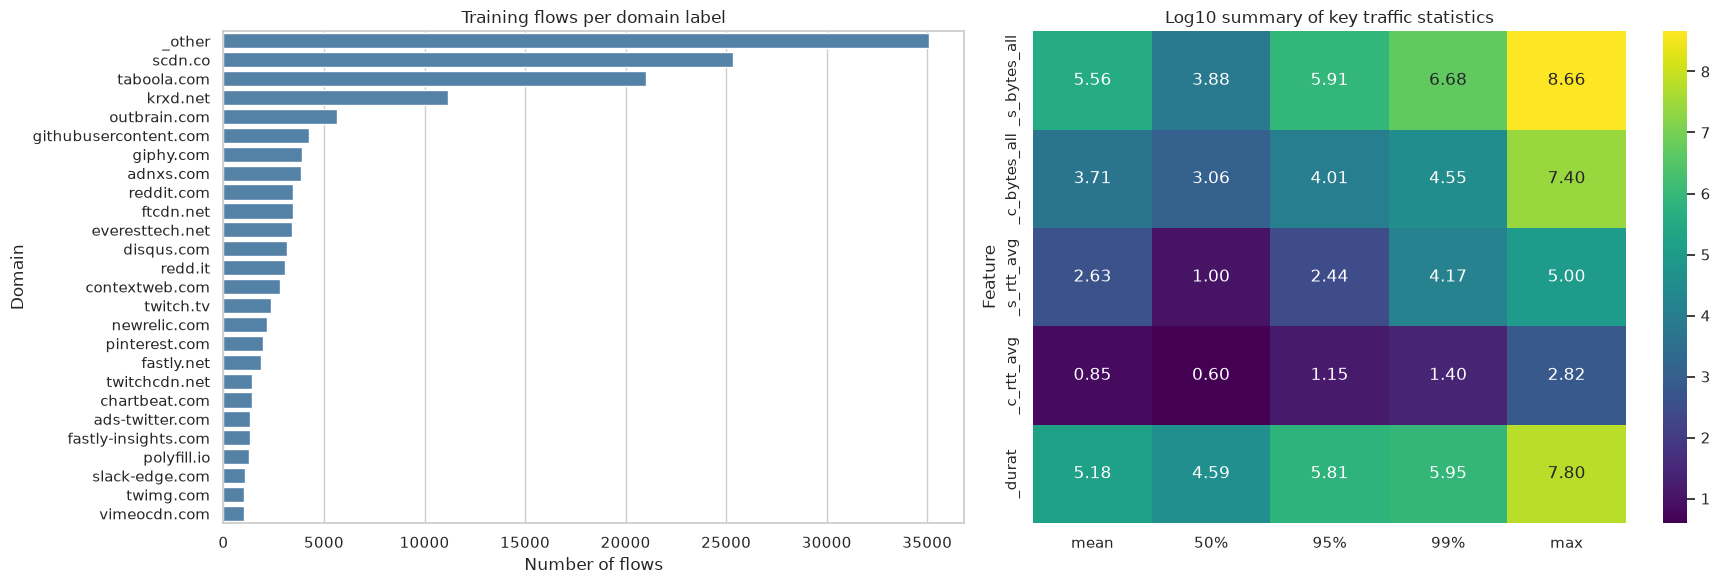

,count,mean,std,min,50%,75%,90%,95%,99%,max
_s_bytes_all,147863.0,359310.891859,4.018652e+06,7.000000,7617.000000,48580.500000,268364.800000,809733.300000,4.795948e+06,4.549762e+08
_c_bytes_all,147863.0,5112.462090,1.403877e+05,117.000000,1142.000000,2068.000000,5487.000000,10198.700000,3.559464e+04,2.539156e+07
_s_rtt_avg,147863.0,426.364216,3.053152e+03,0.000000,9.903334,22.913697,75.474136,272.669310,1.480122e+04,1.006823e+05
_c_rtt_avg,147863.0,7.093867,1.276800e+01,0.780184,3.982534,9.825270,12.597315,14.227394,2.505497e+01,6.617158e+02
_durat,147863.0,152767.798820,3.542997e+05,7.990000,38608.138000,189897.584000,565617.403600,645135.960700,8.866330e+05,6.240620e+07


In [5]:
label_counts = train_clean["label"].value_counts()
label_percent = (label_counts / label_counts.sum() * 100).round(2)
label_table = pd.DataFrame({"flows": label_counts, "percentage": label_percent})
display(label_table)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[0], color="steelblue")
axes[0].set_title("Training flows per domain label")
axes[0].set_xlabel("Number of flows")
axes[0].set_ylabel("Domain")

key_stats = train_clean[["_s_bytes_all", "_c_bytes_all", "_s_rtt_avg", "_c_rtt_avg", "_durat"]].describe(percentiles=[.5, .75, .9, .95, .99]).T
sns.heatmap(np.log10(key_stats[["mean", "50%", "95%", "99%", "max"]].clip(lower=1)), annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
axes[1].set_title("Log10 summary of key traffic statistics")
axes[1].set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(key_stats)


The label distribution is clearly imbalanced: `_other`, `scdn.co` and `taboola.com` dominate the trace, while several domains have around one thousand flows. This motivates weighted F1-score, per-class reports and normalized confusion matrices instead of accuracy alone. The byte, RTT and duration summaries show heavy-tailed behavior, confirming the need for log-scaled visualizations and log preprocessing.


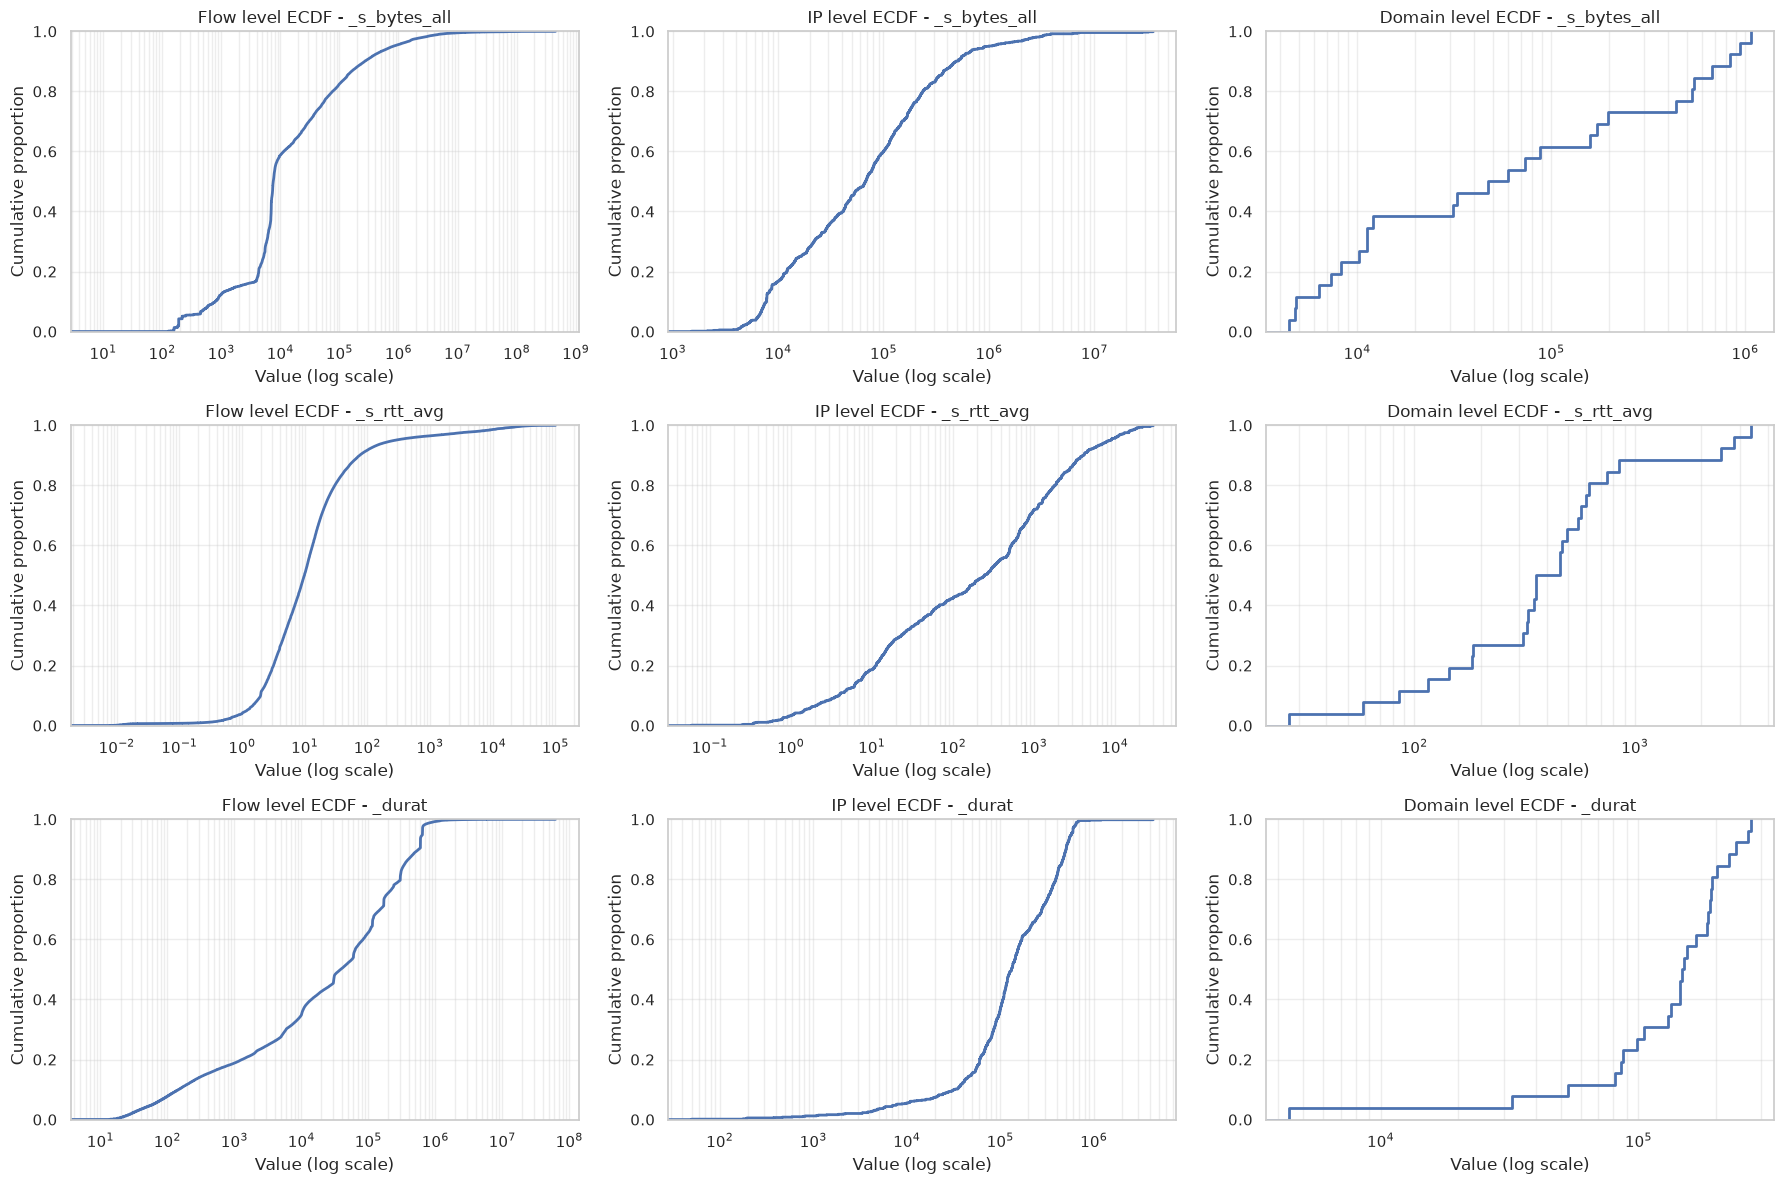

In [6]:
def plot_ecdf_levels(flow_df, ip_df, domain_df, features):
    fig, axes = plt.subplots(len(features), 3, figsize=(18, 4 * len(features)))
    level_data = [("Flow", flow_df), ("IP", ip_df), ("Domain", domain_df)]

    for row, feature in enumerate(features):
        for col, (level_name, data) in enumerate(level_data):
            ax = axes[row, col] if len(features) > 1 else axes[col]
            if feature not in data.columns:
                ax.axis("off")
                continue
            values = data.loc[data[feature] > 0, feature]
            sns.ecdfplot(x=values, ax=ax, linewidth=2)
            ax.set_xscale("log")
            ax.set_title(f"{level_name} level ECDF - {feature}")
            ax.set_xlabel("Value (log scale)")
            ax.set_ylabel("Cumulative proportion")
            ax.grid(True, which="both", alpha=0.35)
    plt.tight_layout()
    plt.show()

plot_ecdf_levels(train_clean, ip_level, domain_level, ["_s_bytes_all", "_s_rtt_avg", "_durat"])


The ECDFs show the same qualitative pattern at all three levels: most flows/domains are small or moderate, while a minority produces very large byte counts, long durations or high RTT values. The aggregation smooths single-flow noise but does not remove the long tail, which is why robust/log preprocessing remains useful for downstream models.


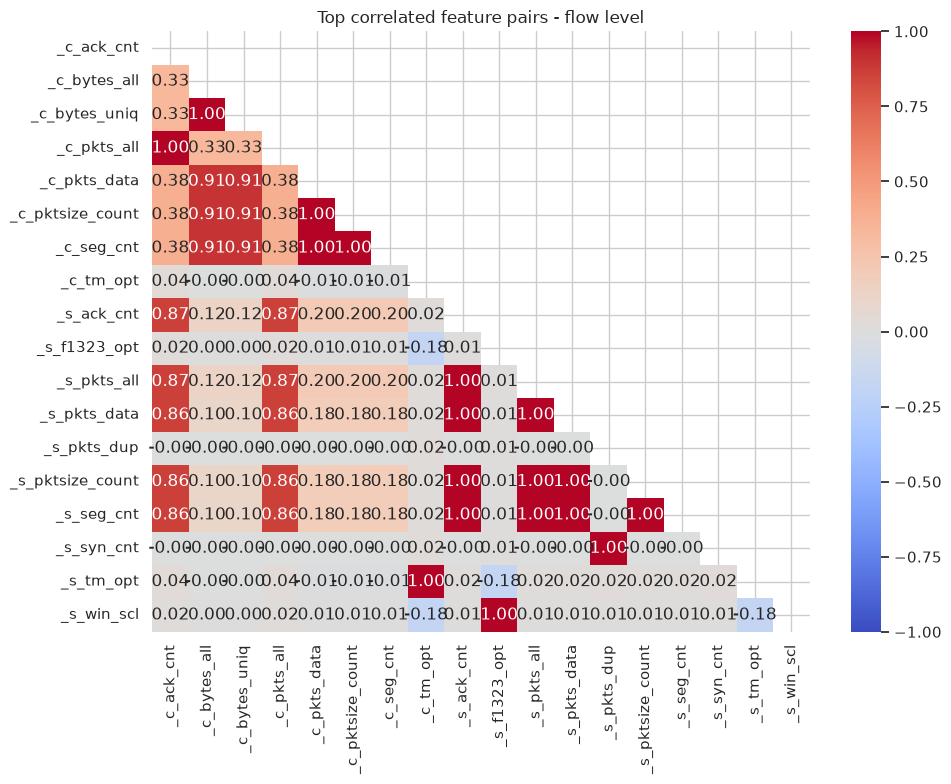

,feature_1,feature_2,abs_corr,corr
0,_s_f1323_opt,_s_win_scl,1.000000,1.000000
1,_s_pkts_data,_s_pktsize_count,1.000000,1.000000
2,_c_pkts_data,_c_pktsize_count,1.000000,1.000000
3,_c_tm_opt,_s_tm_opt,1.000000,1.000000
4,_s_pkts_dup,_s_syn_cnt,1.000000,1.000000
5,_s_pkts_data,_s_seg_cnt,1.000000,1.000000
6,_s_pktsize_count,_s_seg_cnt,1.000000,1.000000
7,_s_ack_cnt,_s_pkts_all,1.000000,1.000000
8,_c_pkts_data,_c_seg_cnt,1.000000,1.000000
9,_c_pktsize_count,_c_seg_cnt,1.000000,1.000000


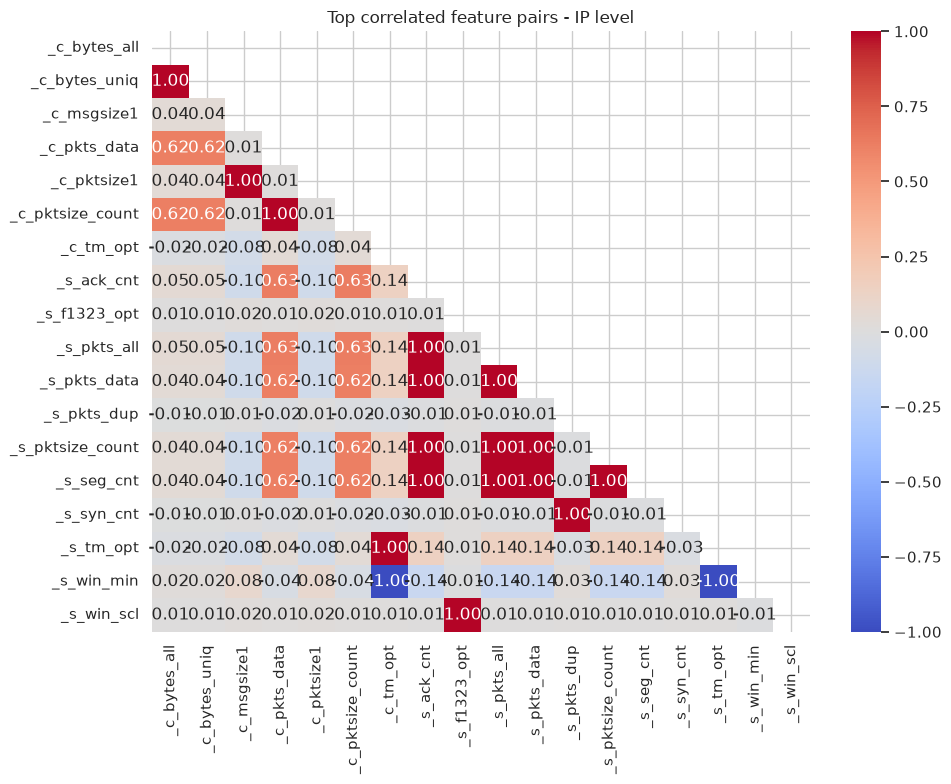

,feature_1,feature_2,abs_corr,corr
0,_c_tm_opt,_s_tm_opt,1.0,1.0
1,_s_f1323_opt,_s_win_scl,1.0,1.0
2,_s_pkts_data,_s_pktsize_count,1.0,1.0
3,_c_pkts_data,_c_pktsize_count,1.0,1.0
4,_s_pkts_dup,_s_syn_cnt,1.0,1.0
5,_c_tm_opt,_s_win_min,1.0,-1.0
6,_s_tm_opt,_s_win_min,1.0,-1.0
7,_s_pkts_data,_s_seg_cnt,1.0,1.0
8,_s_pktsize_count,_s_seg_cnt,1.0,1.0
9,_s_ack_cnt,_s_pkts_all,1.0,1.0


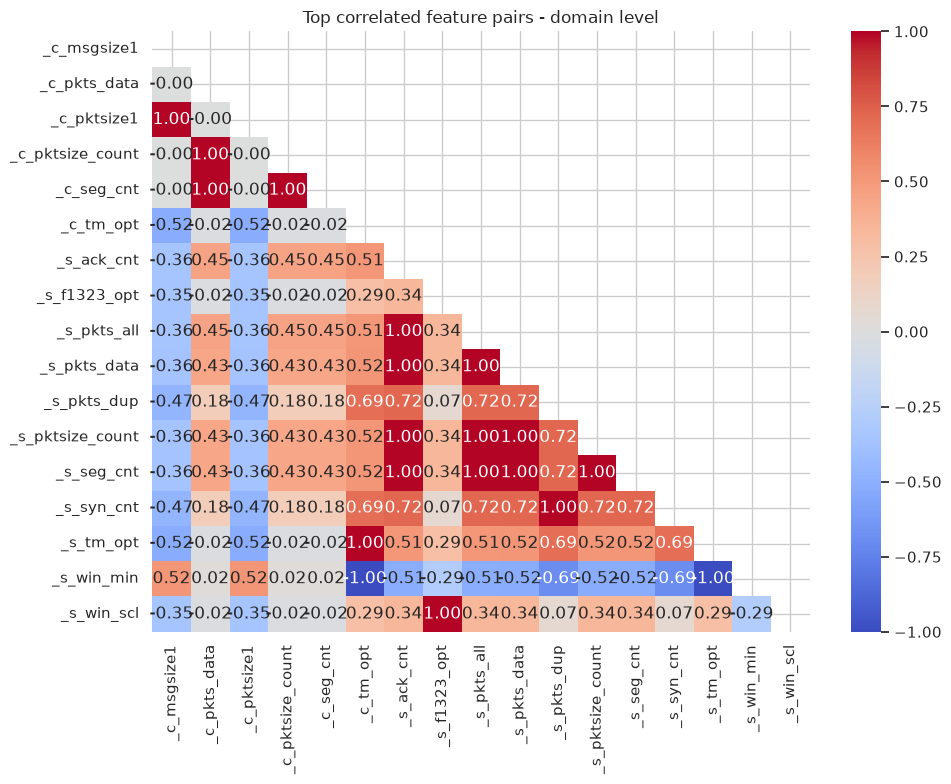

,feature_1,feature_2,abs_corr,corr
0,_s_pkts_data,_s_pktsize_count,1.0,1.0
1,_c_tm_opt,_s_tm_opt,1.0,1.0
2,_c_pkts_data,_c_pktsize_count,1.0,1.0
3,_s_f1323_opt,_s_win_scl,1.0,1.0
4,_s_pkts_dup,_s_syn_cnt,1.0,1.0
5,_c_tm_opt,_s_win_min,1.0,-1.0
6,_s_tm_opt,_s_win_min,1.0,-1.0
7,_s_pktsize_count,_s_seg_cnt,1.0,1.0
8,_s_pkts_data,_s_seg_cnt,1.0,1.0
9,_s_ack_cnt,_s_pkts_all,1.0,1.0


In [7]:
def top_correlations(df, n=12):
    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr()
    pairs = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
    top_pairs = pairs.head(n).reset_index()
    top_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
    top_pairs["corr"] = [corr.loc[a, b] for a, b in zip(top_pairs["feature_1"], top_pairs["feature_2"])]
    return corr, top_pairs


def plot_top_corr_heatmap(df, title, n=12):
    corr, pairs = top_correlations(df, n=n)
    features = sorted(set(pairs["feature_1"]).union(set(pairs["feature_2"])))
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones((len(features), len(features)), dtype=bool))
    sns.heatmap(corr.loc[features, features], mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    display(pairs)

plot_top_corr_heatmap(train_clean[numeric_feature_columns(train_clean)], "Top correlated feature pairs - flow level")
plot_top_corr_heatmap(ip_level, "Top correlated feature pairs - IP level")
plot_top_corr_heatmap(domain_level, "Top correlated feature pairs - domain level")


In [8]:
def inspect_correlation_drops(X_train, threshold=0.95):
    sorted_cols = sorted(X_train.columns, key=lambda c: (not 'mean' in c.lower(), c))
    X_sorted = X_train[sorted_cols]
    corr = X_sorted.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    rows = []
    for col in to_drop:
        partners = upper[col][upper[col] > threshold]
        best_partner = partners.idxmax()
        rows.append({"dropped": col, "kept_partner": best_partner, "abs_corr": partners[best_partner]})
    return pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)


X_train_log_all = np.log1p(
    train_clean[[c for c in numeric_feature_columns(train_clean) if c not in {"label", "c_ip", "time"}]]
    .clip(lower=0)
)
drop_reasons = inspect_correlation_drops(X_train_log_all, threshold=0.95)
print(f"{len(drop_reasons)} columns dropped at |r| > 0.95")
display(drop_reasons)

31 columns dropped at |r| > 0.95


,dropped,kept_partner,abs_corr
0,_c_pktsize_count,_c_pkts_data,1.000000
1,_s_tm_opt,_c_tm_opt,1.000000
2,_s_pktsize_count,_s_pkts_data,1.000000
3,_s_win_scl,_s_f1323_opt,1.000000
4,_s_pkts_all,_s_ack_cnt,0.999995
5,_s_win_min,_c_tm_opt,0.999982
6,_c_msgsize1,_c_cwin_ini,0.999943
7,_s_bytes_uniq,_s_bytes_all,0.999579
8,_c_pkts_all,_c_ack_cnt,0.999440
9,_s_seg_cnt,_s_pkts_data,0.999247


The strongest correlations are mostly between counters that describe the same TCP direction from different angles: bytes, packets, segment counts, application-data bytes and retransmission-related quantities. This justifies removing highly correlated columns for model matrices, because otherwise linear models and distance-based clustering would over-weight repeated measurements of the same behavior.


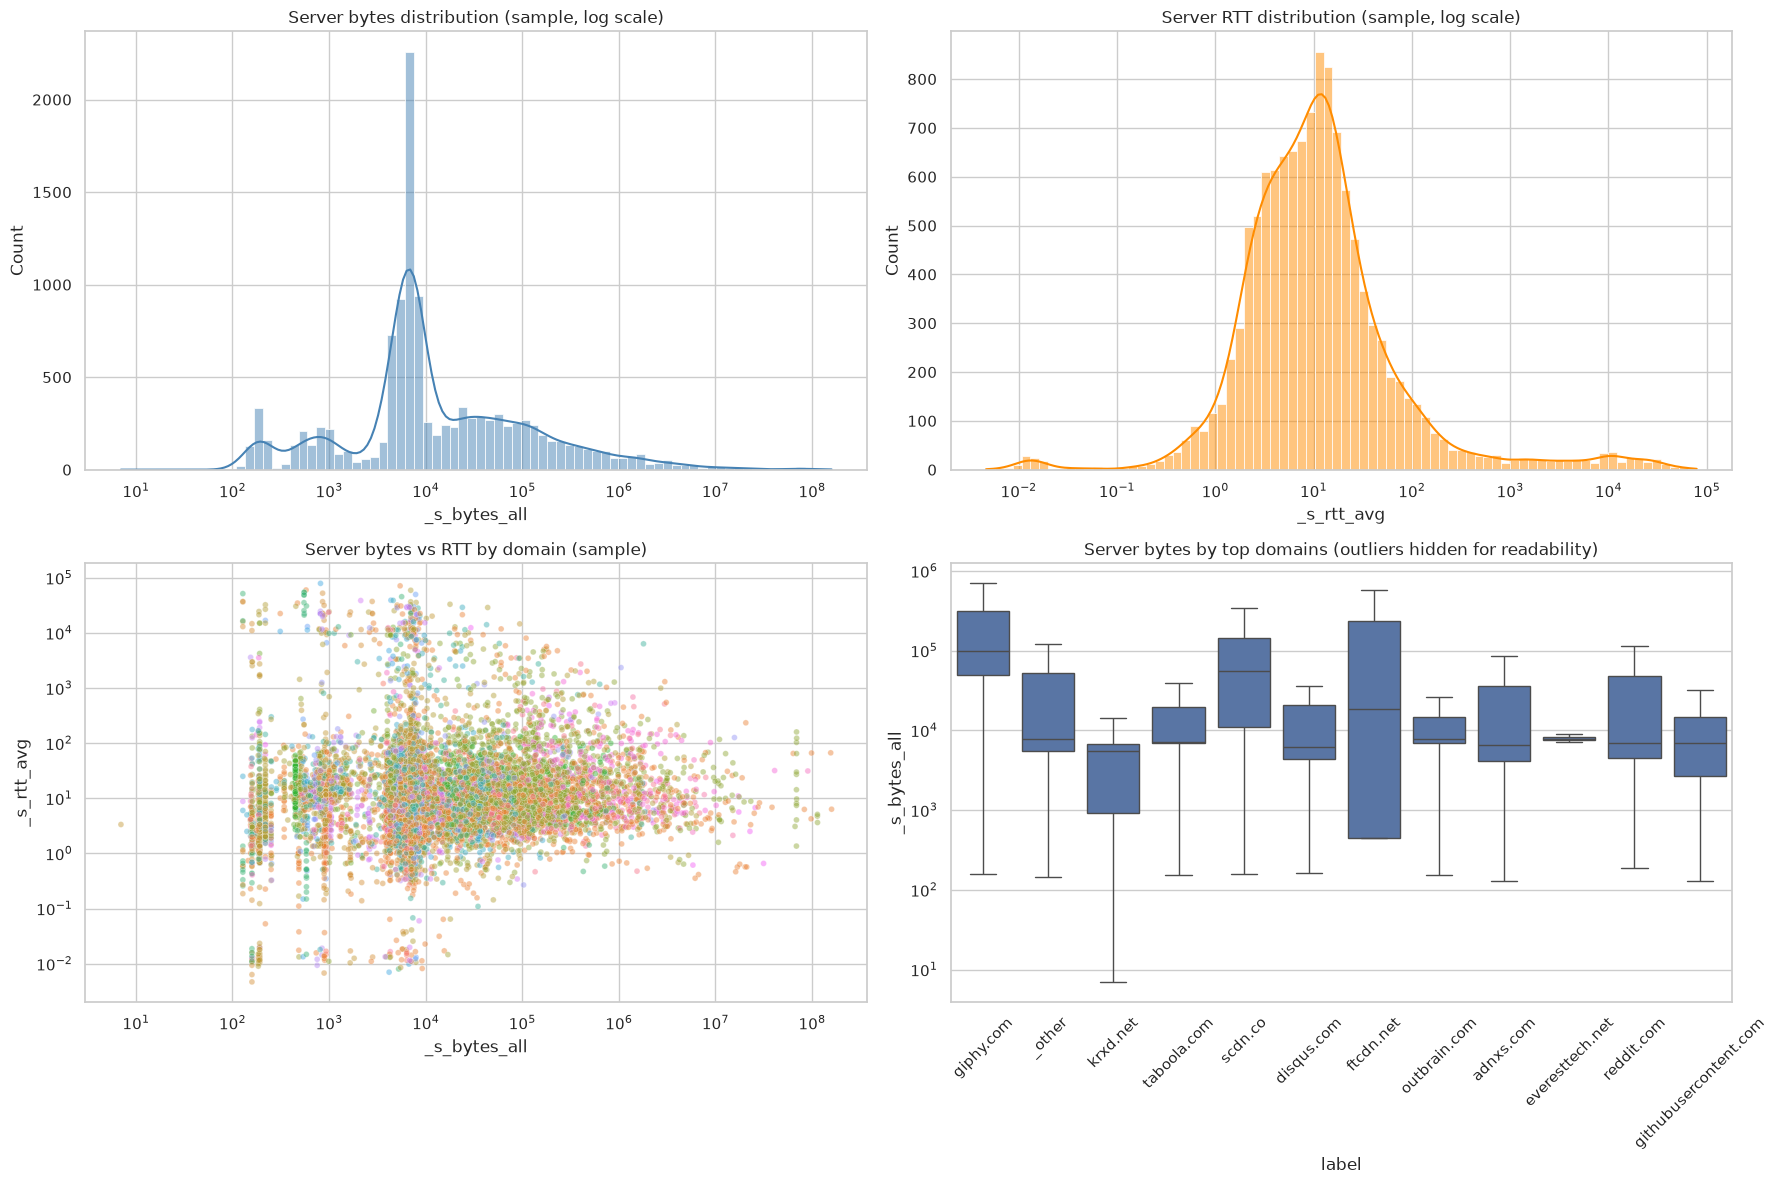

In [9]:
plot_df = train_clean.sample(min(PLOT_SAMPLE, len(train_clean)), random_state=RANDOM_STATE)
top_domains = label_counts.head(12).index
plot_top = plot_df[plot_df["label"].isin(top_domains)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.histplot(data=plot_df, x="_s_bytes_all", bins=80, log_scale=True, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Server bytes distribution (sample, log scale)")

sns.histplot(data=plot_df[plot_df["_s_rtt_avg"] > 0], x="_s_rtt_avg", bins=80, log_scale=True, kde=True, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Server RTT distribution (sample, log scale)")

sns.scatterplot(data=plot_df, x="_s_bytes_all", y="_s_rtt_avg", hue="label", alpha=0.45, s=18, legend=False, ax=axes[1, 0])
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Server bytes vs RTT by domain (sample)")

sns.boxplot(data=plot_top, x="label", y="_s_bytes_all", ax=axes[1, 1], showfliers=False)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Server bytes by top domains (outliers hidden for readability)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


The byte distribution is much more dispersed than the RTT distribution, and the boxplot shows domain-specific payload profiles: media/content domains tend to have larger server-to-client byte volumes, while advertising or tracking domains often produce smaller but frequent flows. The scatter plot also confirms that high byte volume and high RTT are not the same phenomenon, so the two regression targets should be treated as separate problems.


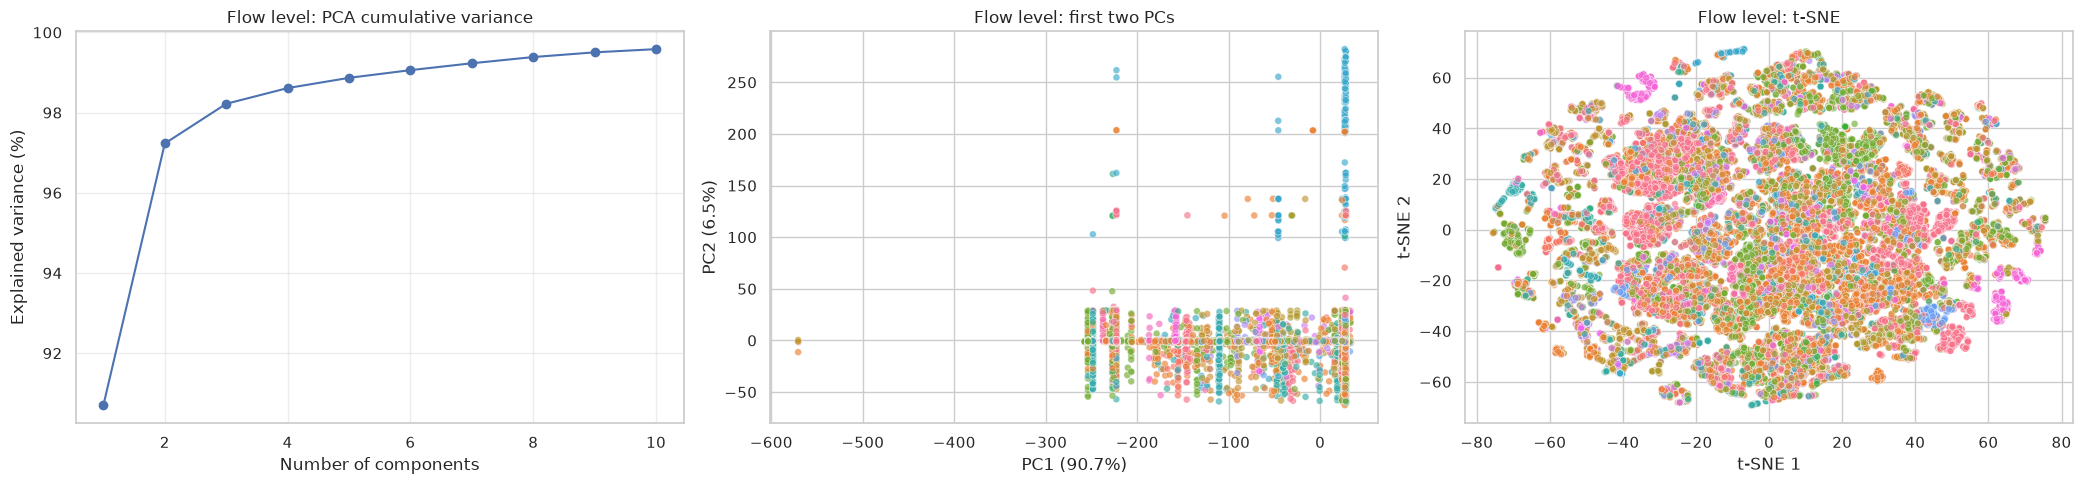

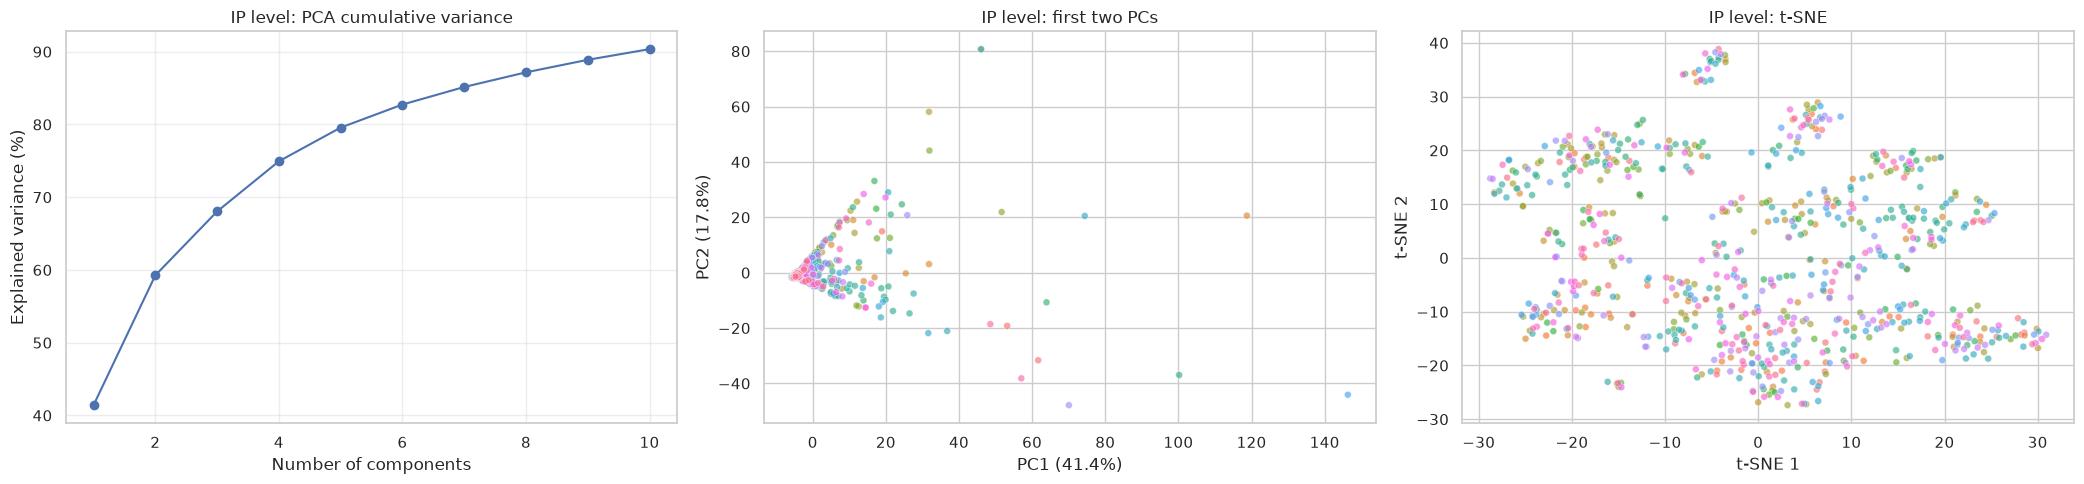

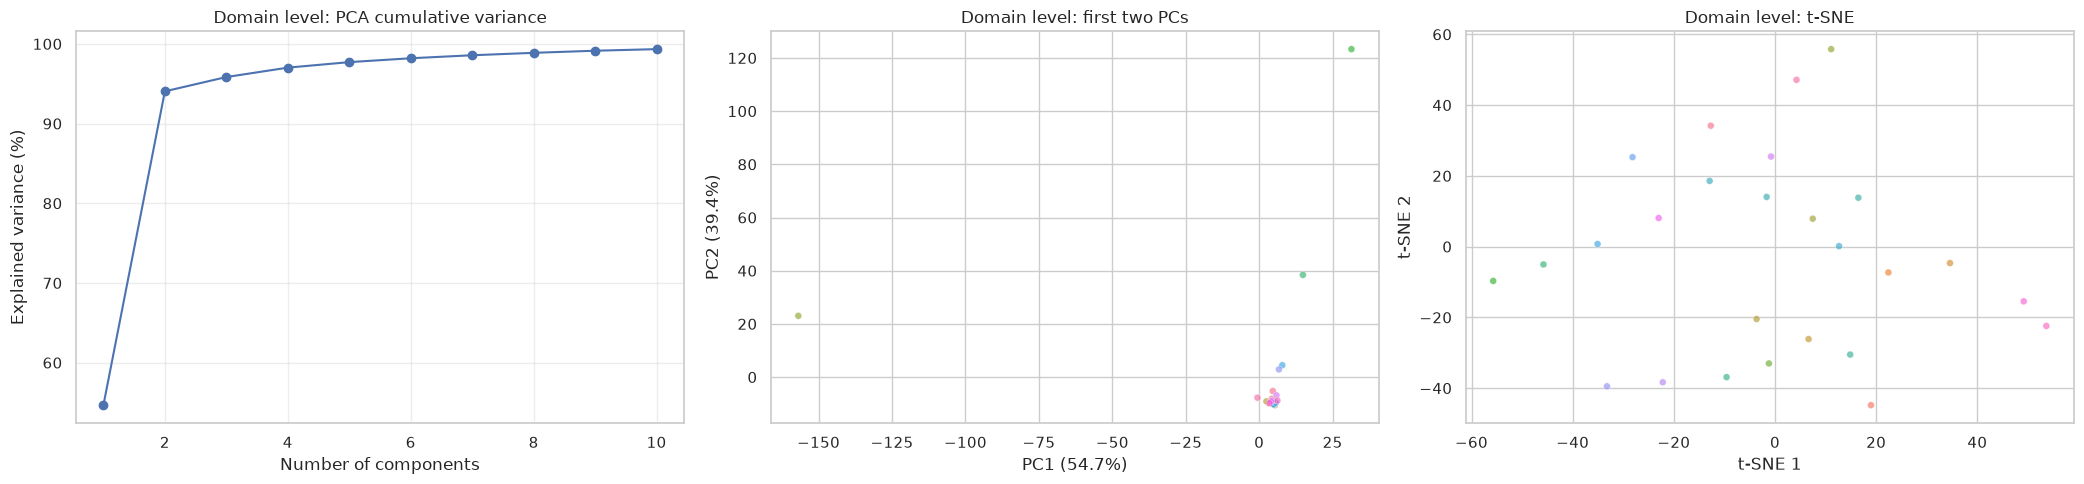

In [45]:
def scaled_for_projection(df, feature_cols=None):
    if feature_cols is None:
        feature_cols = numeric_feature_columns(df)
    X = np.log1p(df[feature_cols].clip(lower=0))
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    scaler = RobustScaler()
    return scaler.fit_transform(X), feature_cols


def pca_tsne_projection(X, labels, title, sample_size=None, perplexity=30):
    if sample_size is not None and len(X) > sample_size:
        idx = np.random.default_rng(RANDOM_STATE).choice(len(X), size=sample_size, replace=False)
        X_plot = X[idx]
        labels_plot = np.asarray(labels)[idx]
    else:
        X_plot = X
        labels_plot = np.asarray(labels)

    pca = PCA(n_components=min(10, X_plot.shape[1], X_plot.shape[0] - 1), random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_plot)
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    tsne_perplexity = min(perplexity, max(2, (len(X_plot) - 1) // 3))
    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, init="pca", learning_rate="auto", max_iter=600, random_state=RANDOM_STATE)
    X_tsne = tsne.fit_transform(X_plot)

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    axes[0].plot(np.arange(1, len(cumulative) + 1), cumulative * 100, marker="o")
    axes[0].set_title(f"{title}: PCA cumulative variance")
    axes[0].set_xlabel("Number of components")
    axes[0].set_ylabel("Explained variance (%)")
    axes[0].grid(True, alpha=0.35)

    hue = pd.Series(labels_plot).astype(str)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hue, s=25, alpha=0.65, legend=False, ax=axes[1])
    axes[1].set_title(f"{title}: first two PCs")
    axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")

    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=hue, s=25, alpha=0.65, legend=False, ax=axes[2])
    axes[2].set_title(f"{title}: t-SNE")
    axes[2].set_xlabel("t-SNE 1")
    axes[2].set_ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

    return pca, cumulative

flow_X, _ = scaled_for_projection(train_clean)
flow_pca, flow_cum = pca_tsne_projection(flow_X, train_clean["label"].values, "Flow level", sample_size=TSNE_SAMPLE, perplexity=35)

ip_X, _ = scaled_for_projection(ip_level.reset_index(drop=True))
ip_pca, ip_cum = pca_tsne_projection(ip_X, ip_level.index.astype(str).values, "IP level", sample_size=None, perplexity=25)

domain_X, _ = scaled_for_projection(domain_level.reset_index(drop=True))
domain_pca, domain_cum = pca_tsne_projection(domain_X, domain_level.index.astype(str).values, "Domain level", sample_size=None, perplexity=5)


PCA and t-SNE are used here as exploratory tools, not as proof of separability. At flow level, labels overlap because many domains generate similar encrypted TCP patterns. At domain level, aggregation makes the structure clearer: domains separate more by traffic behavior (payload size, RTT, duration and popularity) than by exact domain name. This observation motivates the clustering section.


## Section 2 – Supervised Classification

In [10]:
# ---------------------------------------------------------------------------
# Prepare features for Supervised Pipelines
# ---------------------------------------------------------------------------
# Section 1 produced train_clean and test_clean.
# We apply the log1p transformation to handle heavy-tailed network counters,
# but we do NOT apply RobustScaler globally.
# Our supervised models use sklearn Pipelines (RobustScaler -> PCA -> Clf)
# to ensure scaling is fitted *only* on the training fold during Cross-Validation,
# preventing data leakage.

selected_feature_names = X_train_model.columns.tolist()

X_train_cv = np.log1p(train_clean[selected_feature_names].clip(lower=0))
X_test_cv = np.log1p(test_clean[selected_feature_names].clip(lower=0))

# Align target labels with the new feature matrices
y_train_cv = pd.Series(y_train.values, index=X_train_cv.index, name='label')
y_test_cv = pd.Series(y_test.values, index=X_test_cv.index, name='label')

### Section 2.1 – Default models and 5-Fold Cross Validation

In [11]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# ---------------------------------------------------------------------------
# Default model pipelines --- TRUE sklearn defaults
# ---------------------------------------------------------------------------
# As required by the assignment trace ("default parameter configuration"),
# we use sklearn's built-in defaults for each classifier:
#   - DecisionTreeClassifier: max_depth=None (unlimited), min_samples_leaf=1
#   - RandomForestClassifier: n_estimators=100, max_depth=None, min_samples_leaf=1
#   - KNeighborsClassifier:   n_neighbors=5, weights='uniform', metric='minkowski'
#
# The only additions are:
#   - random_state=42 for reproducibility
#   - n_jobs=-1 for parallelism where supported
#   - Scaler in the pipeline (preprocessing, not a model hyper-parameter)
#   - PCA for KNN (necessary to make distance computation meaningful)
# ---------------------------------------------------------------------------

def build_classification_models_default():
    """Return model pipelines with TRUE sklearn default hyper-parameters."""
    return {
        'Decision Tree': Pipeline([
            ('scaler', RobustScaler()),
            ('pca', 'passthrough'),
            ('clf', DecisionTreeClassifier(random_state=42))
        ]),
        'Random Forest': Pipeline([
            ('scaler', RobustScaler()),
            ('pca', 'passthrough'),
            ('clf', RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1
            ))
        ]),
        'K-Nearest Neighbors': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.85, random_state=42)),
            ('clf', KNeighborsClassifier(n_jobs=-1))
        ])
    }


# ---------------------------------------------------------------------------
# Evaluation helpers
# ---------------------------------------------------------------------------

def diagnose_classification_fit(train_f1, test_f1):
    """Simple heuristic to flag overfitting or underfitting.

    - Gap > 0.15: the model memorises training data but fails to generalise.
    - Both F1 < 0.60: the model lacks capacity or the features are too noisy.
    - Otherwise: acceptable generalisation.
    """
    gap = train_f1 - test_f1
    if gap > 0.15:
        return f'possible overfitting (F1 gap={gap:.3f})'
    if train_f1 < 0.60 and test_f1 < 0.60:
        return 'possible underfitting (low train/test F1)'
    return f'acceptable generalisation (F1 gap={gap:.3f})'


def evaluate_classification_models(models, X_train, y_train, X_test, y_test):
    """Train each model on X_train and evaluate on both train and test sets.

    Returns:
        results_df: DataFrame with F1, accuracy and diagnosis for each model.
        trained_models: dict of fitted model instances.
    """
    rows = []
    trained_models = {}

    for name, model in models.items():
        print(f"\n{'='*70}\n{name} - training\n{'='*70}")
        fitted = clone(model)
        fitted.fit(X_train, y_train)
        trained_models[name] = fitted

        y_pred_train = fitted.predict(X_train)
        y_pred_test = fitted.predict(X_test)

        train_f1 = f1_score(y_train, y_pred_train, average='weighted')
        test_f1 = f1_score(y_test, y_pred_test, average='weighted')
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        rows.append({
            'model': name,
            'train_f1_weighted': train_f1,
            'test_f1_weighted': test_f1,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'diagnosis': diagnose_classification_fit(train_f1, test_f1)
        })

        print(f"Train weighted F1: {train_f1:.4f} | Test weighted F1: {test_f1:.4f}")
        print(f"Train accuracy:    {train_acc:.4f} | Test accuracy:    {test_acc:.4f}")
        print(f"Diagnosis: {rows[-1]['diagnosis']}")
        print("\nPer-class F-measure on official test set:")
        print(classification_report(y_test, y_pred_test, digits=3))

        # Output the confusion matrix as requested by the assignment
        cm = confusion_matrix(y_test, y_pred_test, labels=fitted.classes_, normalize='true')
        plt.figure(figsize=(14, 11))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                    annot_kws={'size': 6},
                    xticklabels=fitted.classes_, yticklabels=fitted.classes_)
        plt.title(f'Confusion Matrix (row-normalized) \u2014 {name}', fontsize=13, fontweight='bold')
        plt.xlabel('Predicted domain', fontsize=11)
        plt.ylabel('True domain', fontsize=11)
        plt.xticks(rotation=60, ha='right', fontsize=8)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

    results_df = pd.DataFrame(rows).sort_values('test_f1_weighted', ascending=False)
    return results_df, trained_models


def stratified_sample_for_tuning(X, y, sample_size=40000, random_state=42):
    """Return a stratified sample preserving the domain distribution."""
    if sample_size is None or sample_size >= len(X):
        return X, y
    _, X_sample, _, y_sample = train_test_split(
        X, y,
        test_size=sample_size,
        stratify=y,
        random_state=random_state
    )
    return X_sample, y_sample


def cross_validate_classification_models(models, X, y, k=5, sample_size=40000):
    """Run k-fold stratified cross-validation for each model."""
    rows = []

    if sample_size is not None and sample_size < len(X):
        _, X_cv, _, y_cv = train_test_split(
            X, y,
            test_size=sample_size,
            stratify=y,
            random_state=42
        )
        print(f"Cross-validation sample shape: {X_cv.shape}")
    else:
        X_cv, y_cv = X, y

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for name, model in models.items():
        scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='f1_weighted', n_jobs=-1)
        rows.append({
            'model': name,
            'cv_f1_weighted_mean': scores.mean(),
            'cv_f1_weighted_std': scores.std()
        })
        print(f"{name}: CV weighted F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

    return pd.DataFrame(rows).sort_values('cv_f1_weighted_mean', ascending=False)


Decision Tree - training
Train weighted F1: 1.0000 | Test weighted F1: 0.8028
Train accuracy:    1.0000 | Test accuracy:    0.8019
Diagnosis: possible overfitting (F1 gap=0.197)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.835     0.749     0.790     34777
            adnxs.com      0.899     0.899     0.899      2942
      ads-twitter.com      0.765     0.893     0.824      1135
        chartbeat.com      0.565     0.919     0.699      1717
       contextweb.com      0.795     0.842     0.818      2383
           disqus.com      0.738     0.686     0.711      3246
      everesttech.net      0.887     0.855     0.870      2894
  fastly-insights.com      0.783     0.757     0.769       686
           fastly.net      0.741     0.765     0.753      1455
            ftcdn.net      0.961     0.963     0.962      1607
            giphy.com      0.756     0.812     0.783      1730
githubusercontent.com

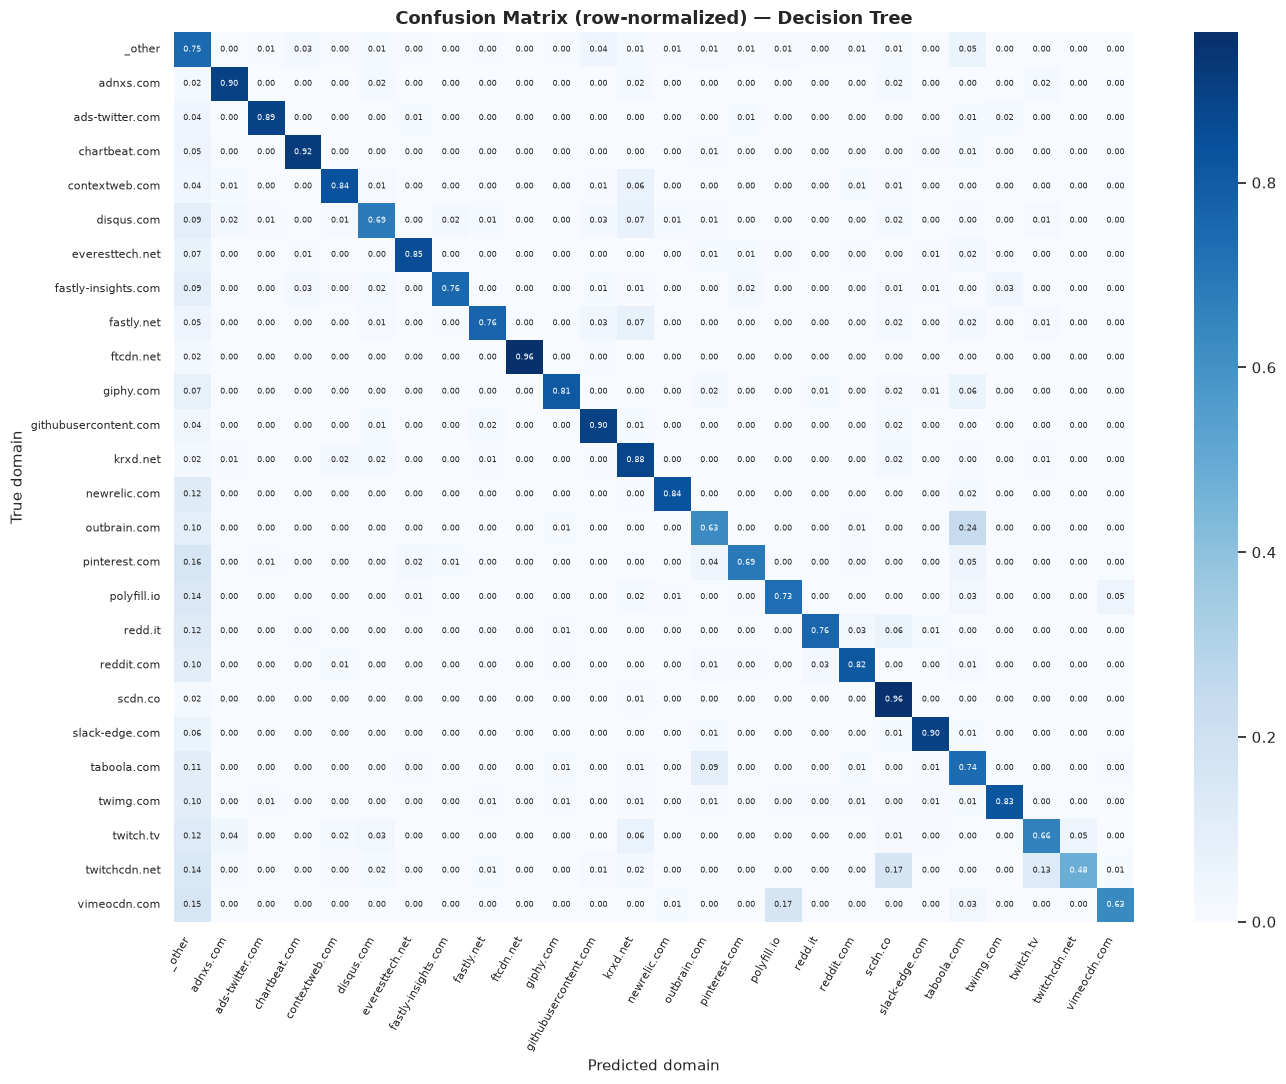


Random Forest - training
Train weighted F1: 1.0000 | Test weighted F1: 0.8503
Train accuracy:    1.0000 | Test accuracy:    0.8521
Diagnosis: acceptable generalisation (F1 gap=0.150)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.826     0.861     0.843     34777
            adnxs.com      0.946     0.884     0.914      2942
      ads-twitter.com      0.960     0.823     0.886      1135
        chartbeat.com      0.941     0.942     0.941      1717
       contextweb.com      0.897     0.846     0.871      2383
           disqus.com      0.815     0.655     0.726      3246
      everesttech.net      0.938     0.868     0.901      2894
  fastly-insights.com      0.973     0.841     0.902       686
           fastly.net      0.899     0.645     0.751      1455
            ftcdn.net      0.992     0.940     0.965      1607
            giphy.com      0.925     0.868     0.895      1730
githubuserconten

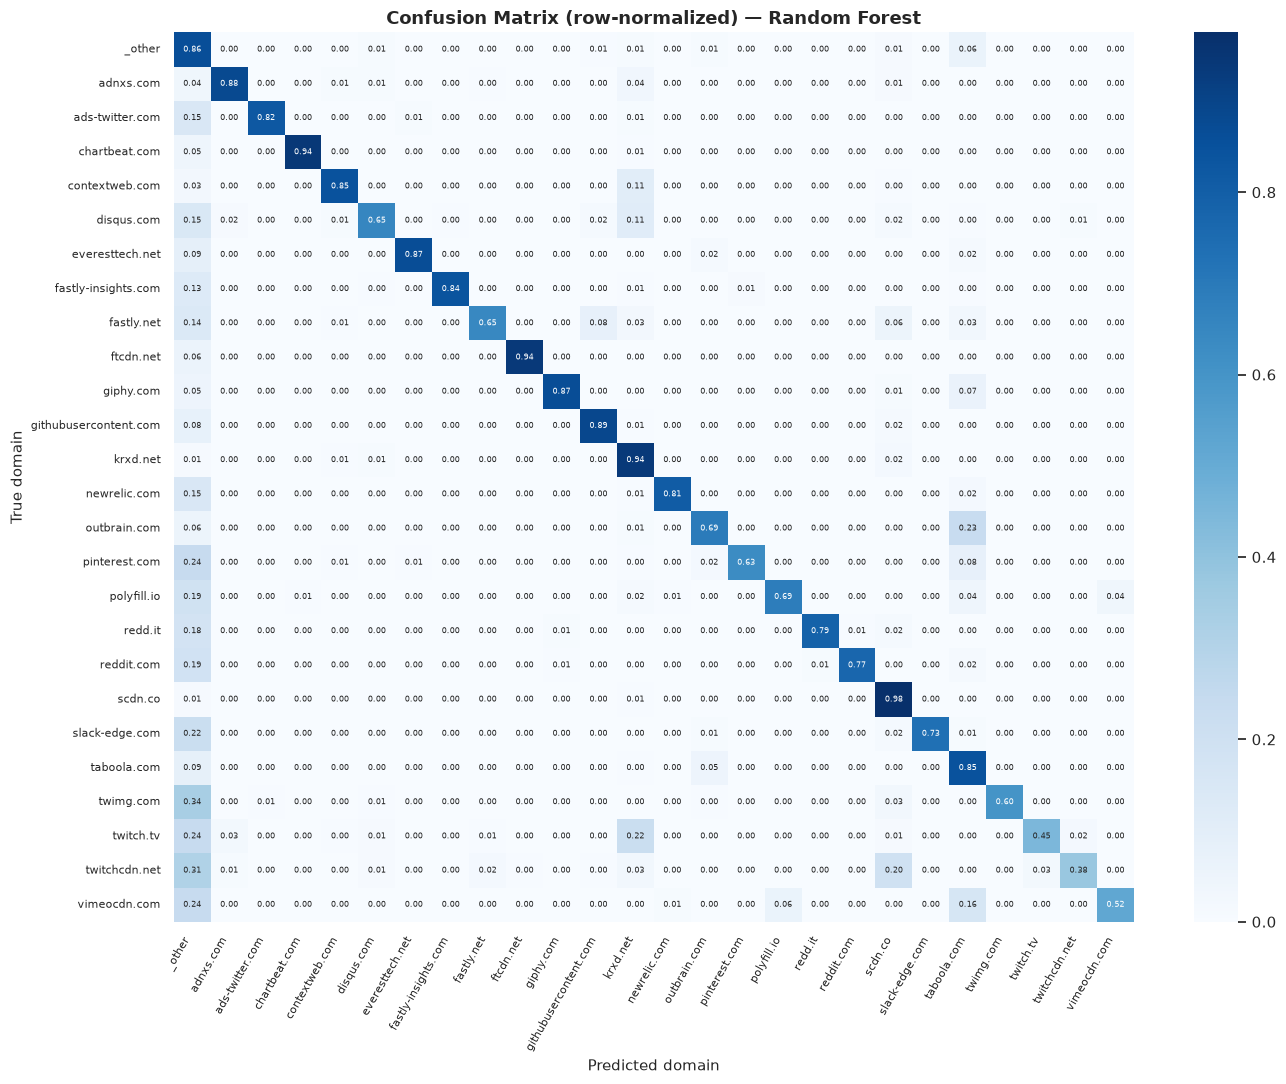


K-Nearest Neighbors - training
Train weighted F1: 0.7495 | Test weighted F1: 0.4840
Train accuracy:    0.7573 | Test accuracy:    0.4977
Diagnosis: possible overfitting (F1 gap=0.265)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.532     0.593     0.561     34777
            adnxs.com      0.428     0.399     0.413      2942
      ads-twitter.com      0.189     0.122     0.149      1135
        chartbeat.com      0.312     0.296     0.304      1717
       contextweb.com      0.302     0.295     0.298      2383
           disqus.com      0.341     0.202     0.253      3246
      everesttech.net      0.307     0.253     0.277      2894
  fastly-insights.com      0.536     0.723     0.615       686
           fastly.net      0.166     0.116     0.137      1455
            ftcdn.net      0.928     0.904     0.916      1607
            giphy.com      0.432     0.584     0.496      1730
githubuserconte

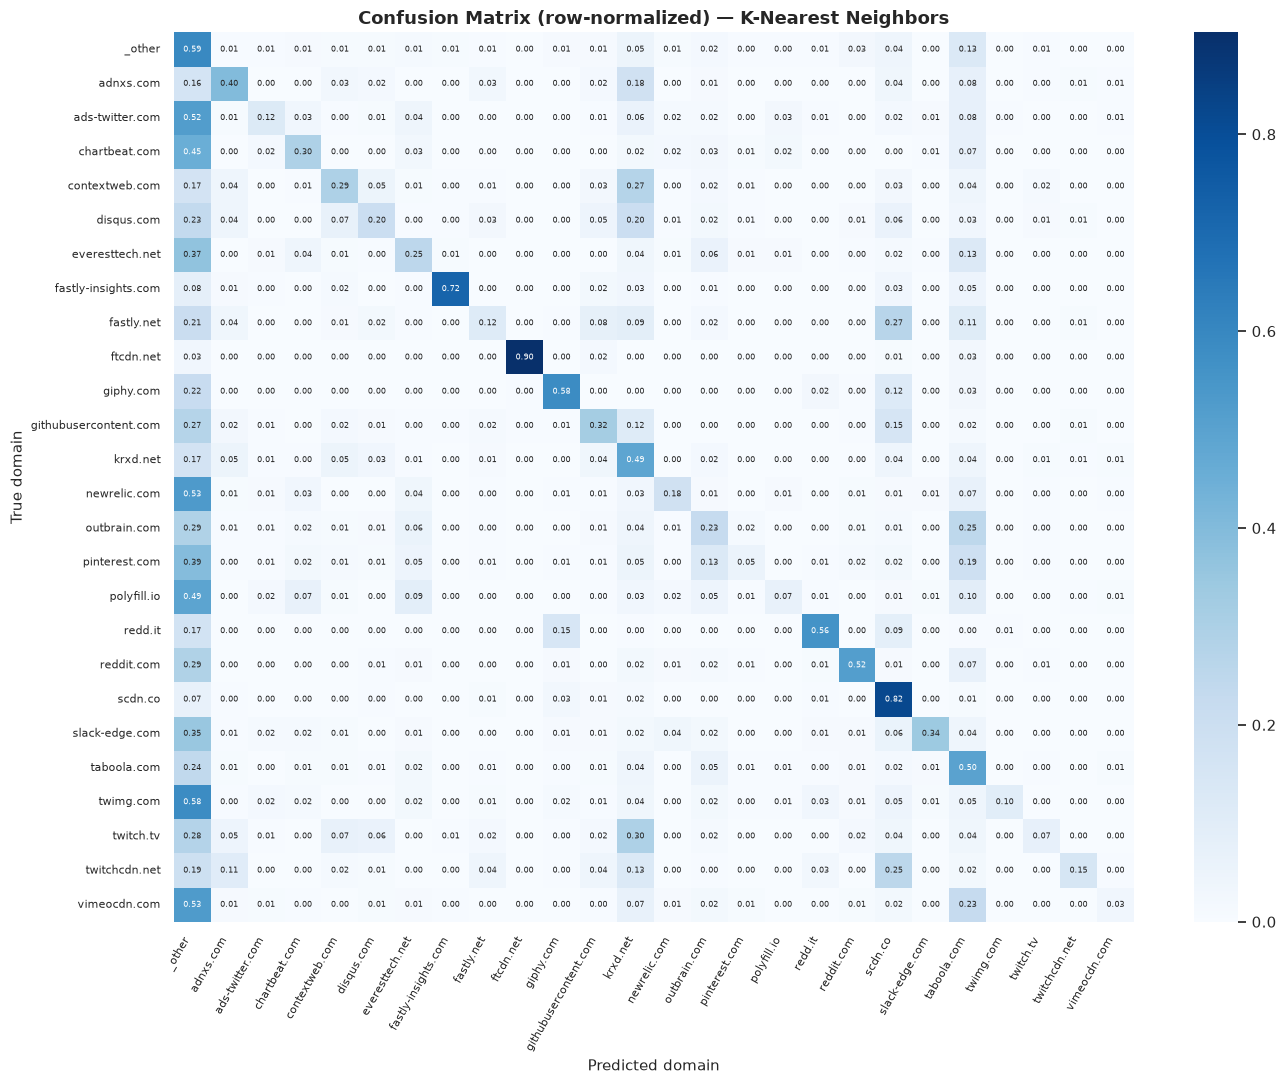


Default model ranking on official test set


,model,train_f1_weighted,test_f1_weighted,train_accuracy,test_accuracy,diagnosis
1,Random Forest,1.000000,0.850325,1.000000,0.852077,acceptable generalisation (F1 gap=0.150)
0,Decision Tree,1.000000,0.802751,1.000000,0.801938,possible overfitting (F1 gap=0.197)
2,K-Nearest Neighbors,0.749519,0.484027,0.757323,0.497678,possible overfitting (F1 gap=0.265)


Decision Tree: CV weighted F1 = 0.9061 +/- 0.0033
Random Forest: CV weighted F1 = 0.9281 +/- 0.0011
K-Nearest Neighbors: CV weighted F1 = 0.6299 +/- 0.0020

5-fold cross-validation ranking (default models)


,model,cv_f1_weighted_mean,cv_f1_weighted_std
1,Random Forest,0.928147,0.001099
0,Decision Tree,0.906069,0.003322
2,K-Nearest Neighbors,0.629897,0.001987


In [12]:
# -- Build default model pipelines --
models_default_parameters = build_classification_models_default()

# -- Train and evaluate default models on BOTH train and test sets --
# As required by the assignment trace, we evaluate the baseline models
# on the official test set immediately to observe their intrinsic generalisation
# capability before any tuning.

classification_default_results, trained_default_models = evaluate_classification_models(
    models_default_parameters,
    X_train_cv,
    y_train_cv,
    X_test_cv,
    y_test_cv
)

print("\nDefault model ranking on official test set")
display(classification_default_results)

# -- 5-fold cross-validation --
# We also compute the 5-fold CV score on the training set to get a more
# robust estimate of performance without relying solely on a single test split.
classification_cv_results = cross_validate_classification_models(
    models_default_parameters,
    X_train_cv,
    y_train_cv,
    k=5,
    sample_size=None
)

print("\n5-fold cross-validation ranking (default models)")
display(classification_cv_results)

### Section 2.2 – Hyper-parameter Tuning

We tune each model's hyper-parameters through **validation curves** (`sklearn.model_selection.validation_curve`), which use 5-fold stratified cross-validation internally. For each parameter of interest, we compute the training and validation scores across a range of values while keeping all other parameters fixed, producing a clear **bias–variance trade-off** plot.

The tuning proceeds **iteratively**: after finding the best value for the most critical parameter (e.g., `max_depth`), we fix it and move to the next parameter (e.g., `min_samples_leaf`). This sequential approach is more efficient than exhaustive grid search while still capturing parameter interactions in the order that matters most.

In [13]:
from sklearn.model_selection import validation_curve
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# ---------------------------------------------------------------------------
# Iterative Validation Curve Tuning
# ---------------------------------------------------------------------------
# For each model, we tune parameters one at a time in sequence.
# After finding the best value for parameter_i, we set it on the
# pipeline and proceed to parameter_{i+1}. This produces one clear
# training-vs-validation plot per parameter.
# ---------------------------------------------------------------------------

PARAM_GRIDS = {
    "Random Forest": {
        'estimator': Pipeline([
            ('scaler', RobustScaler()),
            ('pca', 'passthrough'),
            ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        'params': [
            ('clf__n_estimators',     [50, 100, 200, 300]),
            ('clf__max_depth',        [10, 15, 20, 25, 30]),
            ('clf__min_samples_leaf', [1, 2, 5, 10, 20]),
            ('clf__max_features',     ['sqrt', 'log2']),
        ]
    },
    "Decision Tree": {
        'estimator': Pipeline([
            ('scaler', RobustScaler()),
            ('pca', 'passthrough'),
            ('clf', DecisionTreeClassifier(random_state=42))
        ]),
        'params': [
            ('clf__max_depth',        [5, 10, 15, 20, 25, 30]),
            ('clf__min_samples_leaf', [1, 5, 10, 20, 50]),
            ('clf__criterion',        ['gini', 'entropy']),
        ]
    },
    "K-Nearest Neighbors": {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', 'passthrough'),
            ('clf', KNeighborsClassifier(n_jobs=1))
        ]),
        'params': [
            ('pca', [
                PCA(n_components=0.50),
                PCA(n_components=0.65),
                PCA(n_components=0.80),
                PCA(n_components=0.95),
                LDA(),
            ]),
            ('clf__n_neighbors', [3, 5, 7, 9, 11]),
            ('clf__weights',     ['uniform', 'distance']),
            ('clf__metric',      ['cosine', 'manhattan', 'minkowski']),
        ]
    }
}


def tune_and_plot(model_name, X, y, cv=5):
    """
    Iteratively tune hyper-parameters using sklearn's validation_curve.

    For each parameter in sequence:
      1. Compute the validation curve (training + CV score for each value).
      2. Select the value with the highest mean CV score.
      3. Set that value on the pipeline.
      4. Move to the next parameter.

    Returns:
        best_params: dict of optimal parameter values
        best_score: CV score at the last tuned parameter
        trained_model: pipeline fitted with all best parameters on full X, y
    """
    if model_name not in PARAM_GRIDS:
        raise ValueError(f"Unknown model: {model_name}")

    config = PARAM_GRIDS[model_name]
    estimator = clone(config['estimator'])
    param_sequence = config['params']

    print(f"\n{'='*80}")
    print(f" TUNING: {model_name} (Iterative Validation Curves)")
    print(f"{'='*80}\n")

    best_params = {}
    last_best_score = 0.0

    for param_name, param_range in param_sequence:
        print(f"\nAnalyzing {param_name}...")

        # Compute validation curve
        train_scores, val_scores = validation_curve(
            estimator, X, y,
            param_name=param_name,
            param_range=param_range,
            cv=cv,
            scoring='f1_weighted',
            n_jobs=-1,
            error_score='raise',
            verbose=0
        )

        # Statistics
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)

        # Find best value
        best_idx = np.argmax(val_mean)
        best_value = param_range[best_idx]
        best_val_score = val_mean[best_idx]
        last_best_score = best_val_score

        best_params[param_name] = best_value

        # --- PLOT ---
        plt.figure(figsize=(10, 6))

        # Handle non-numeric parameters (PCA objects, strings)
        if not all(isinstance(v, (int, float)) for v in param_range):
            x_axis = list(range(len(param_range)))
            x_labels = []
            for item in param_range:
                if isinstance(item, str):
                    x_labels.append(item)
                elif hasattr(item, '__class__') and 'LDA' in item.__class__.__name__:
                    x_labels.append("LDA")
                elif hasattr(item, 'n_components'):
                    x_labels.append(f"PCA({item.n_components})")
                else:
                    x_labels.append(str(item))
            best_x = best_idx
        else:
            x_axis = list(param_range)
            x_labels = [str(v) for v in param_range]
            best_x = best_value

        plt.plot(x_axis, train_mean, 'o-', color='darkorange',
                 label='Training score', linewidth=2, markersize=8)
        plt.fill_between(x_axis, train_mean - train_std, train_mean + train_std,
                         alpha=0.15, color='darkorange')

        plt.plot(x_axis, val_mean, 'o-', color='navy',
                 label='Validation score (CV)', linewidth=2, markersize=8)
        plt.fill_between(x_axis, val_mean - val_std, val_mean + val_std,
                         alpha=0.15, color='navy')

        plt.plot(best_x, best_val_score, 'r*', markersize=20,
                 label=f'Best: {x_labels[best_idx]}', zorder=5)

        if not all(isinstance(v, (int, float)) for v in param_range):
            plt.xticks(x_axis, x_labels, rotation=45, ha='right')

        param_display = param_name.split('__')[-1]
        plt.xlabel(param_display, fontsize=12, fontweight='bold')
        plt.ylabel('F1 Score (weighted)', fontsize=12, fontweight='bold')
        plt.title(f'{model_name} \u2014 Validation Curve: {param_display}',
                  fontsize=14, fontweight='bold')
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

        # Print diagnostics
        gap = train_mean[best_idx] - best_val_score
        print(f"  Best {param_display}: {best_value}")
        print(f"    Validation F1: {best_val_score:.4f} (+/- {val_std[best_idx]:.4f})")
        print(f"    Training F1:   {train_mean[best_idx]:.4f} (+/- {train_std[best_idx]:.4f})")
        print(f"    Gap: {gap:.4f}")
        if gap > 0.15:
            print(f"    >> Overfitting detected (gap > 0.15)")
        elif gap < 0.05:
            print(f"    >> Excellent generalisation")
        else:
            print(f"    >> Acceptable generalisation")

        # SET the best value on the estimator for the next iteration
        estimator.set_params(**{param_name: best_value})

    # Train the final model with all best parameters on the full dataset
    print(f"\n{'='*80}")
    print(f" TUNING COMPLETE: {model_name}")
    print(f"{'='*80}")
    print(f"Best parameters found (iteratively):")
    for param, value in best_params.items():
        param_display = param.split('__')[-1]
        print(f"  {param_display}: {value}")
    print(f"\nFinal CV F1 (last parameter): {last_best_score:.4f}")

    print(f"\nTraining {model_name} with best parameters on full training set...")
    trained_model = clone(estimator)
    trained_model.fit(X, y)
    print(f"Model trained and ready for evaluation.")
    print(f"{'='*80}\n")

    return best_params, last_best_score, trained_model


def compare_tuned_models(model_results):
    """Compare tuned models and select the winner."""
    print(f"\n{'='*80}")
    print(f" MODEL COMPARISON \u2014 BEST VALIDATION SCORES")
    print(f"{'='*80}\n")

    sorted_models = sorted(model_results.items(),
                          key=lambda x: x[1][0], reverse=True)

    for rank, (name, (score, params, model)) in enumerate(sorted_models, 1):
        print(f"{rank}. {name}")
        print(f"   Best CV F1-Score: {score:.4f}")
        print(f"   Best parameters:")
        for param, value in params.items():
            param_display = param.split('__')[-1]
            print(f"     {param_display}: {value}")
        print()

    winner_name = sorted_models[0][0]
    print(f"{'='*80}")
    print(f" BEST MODEL: {winner_name}")
    print(f"   CV F1-Score: {sorted_models[0][1][0]:.4f}")
    print(f"{'='*80}\n")

    return winner_name

Training split size:   118290 samples (80%)
Validation split size: 29573 samples (20%)
Number of features:    79

 TUNING: Random Forest (Iterative Validation Curves)


Analyzing clf__n_estimators...


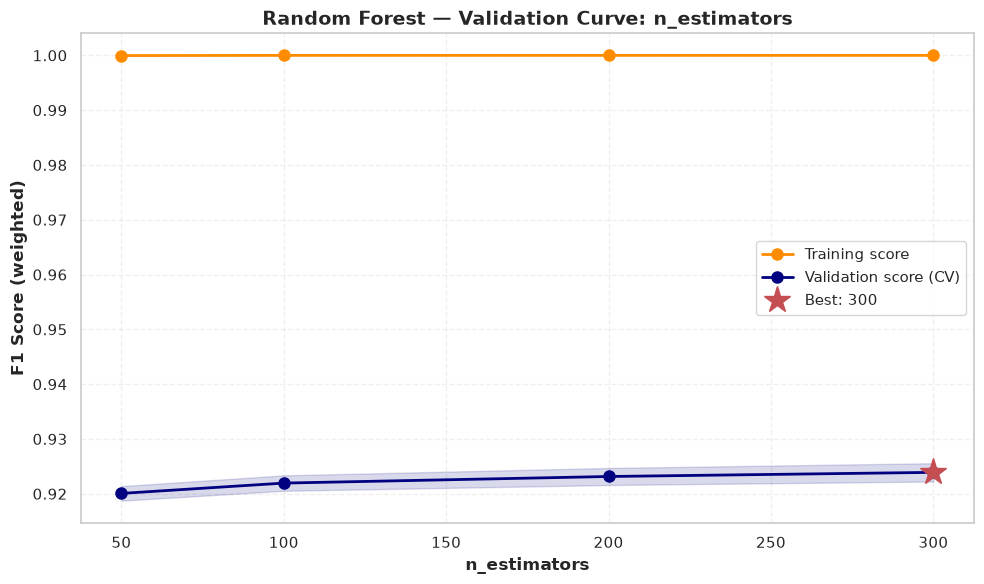

  Best n_estimators: 300
    Validation F1: 0.9239 (+/- 0.0017)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.0761
    >> Acceptable generalisation

Analyzing clf__max_depth...


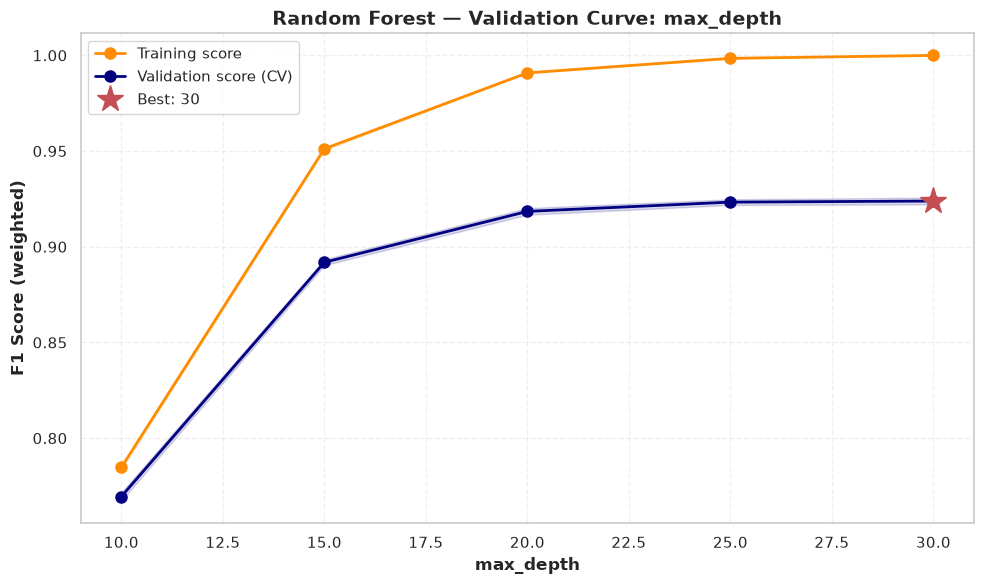

  Best max_depth: 30
    Validation F1: 0.9239 (+/- 0.0018)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.0761
    >> Acceptable generalisation

Analyzing clf__min_samples_leaf...


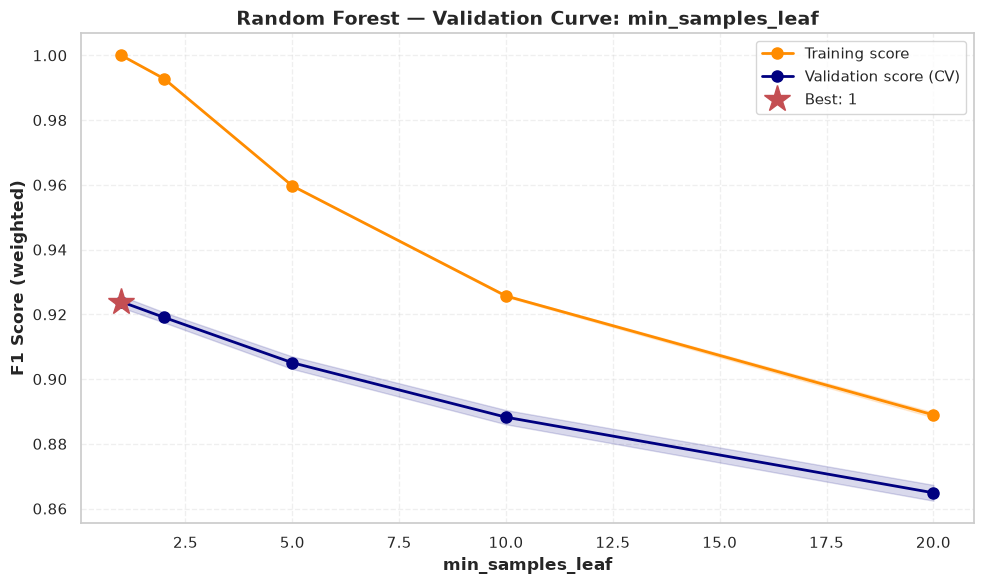

  Best min_samples_leaf: 1
    Validation F1: 0.9239 (+/- 0.0018)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.0761
    >> Acceptable generalisation

Analyzing clf__max_features...


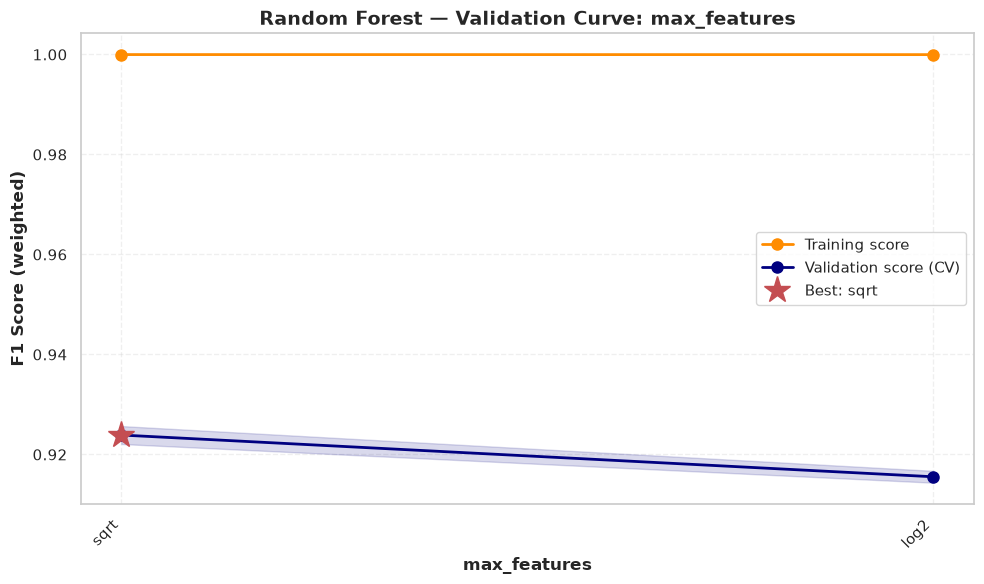

  Best max_features: sqrt
    Validation F1: 0.9239 (+/- 0.0018)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.0761
    >> Acceptable generalisation

 TUNING COMPLETE: Random Forest
Best parameters found (iteratively):
  n_estimators: 300
  max_depth: 30
  min_samples_leaf: 1
  max_features: sqrt

Final CV F1 (last parameter): 0.9239

Training Random Forest with best parameters on full training set...
Model trained and ready for evaluation.



In [14]:
# -- Create train/validation split for tuning --
# We use an 80/20 stratified split of the training set for validation curves.
# The official test set is NOT used during tuning.
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_cv, y_train_cv,
    test_size=0.2,
    stratify=y_train_cv,
    random_state=42
)

print(f"Training split size:   {X_train_split.shape[0]} samples (80%)")
print(f"Validation split size: {X_val_split.shape[0]} samples (20%)")
print(f"Number of features:    {X_train_split.shape[1]}")

# -- Tune each model --
rf_params, rf_score, rf_model = tune_and_plot("Random Forest", X_train_split, y_train_split)


 TUNING: Decision Tree (Iterative Validation Curves)


Analyzing clf__max_depth...


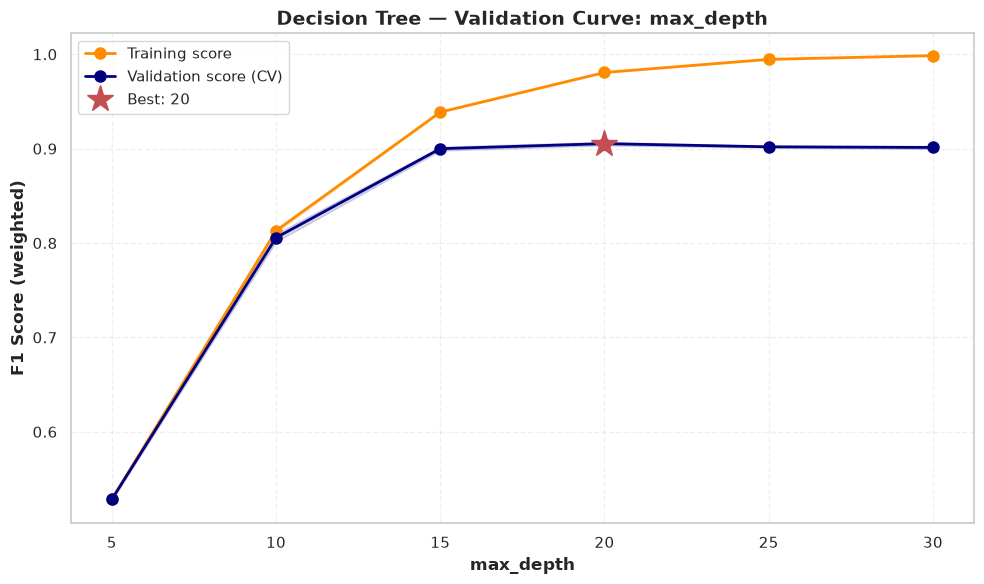

  Best max_depth: 20
    Validation F1: 0.9053 (+/- 0.0019)
    Training F1:   0.9807 (+/- 0.0005)
    Gap: 0.0754
    >> Acceptable generalisation

Analyzing clf__min_samples_leaf...


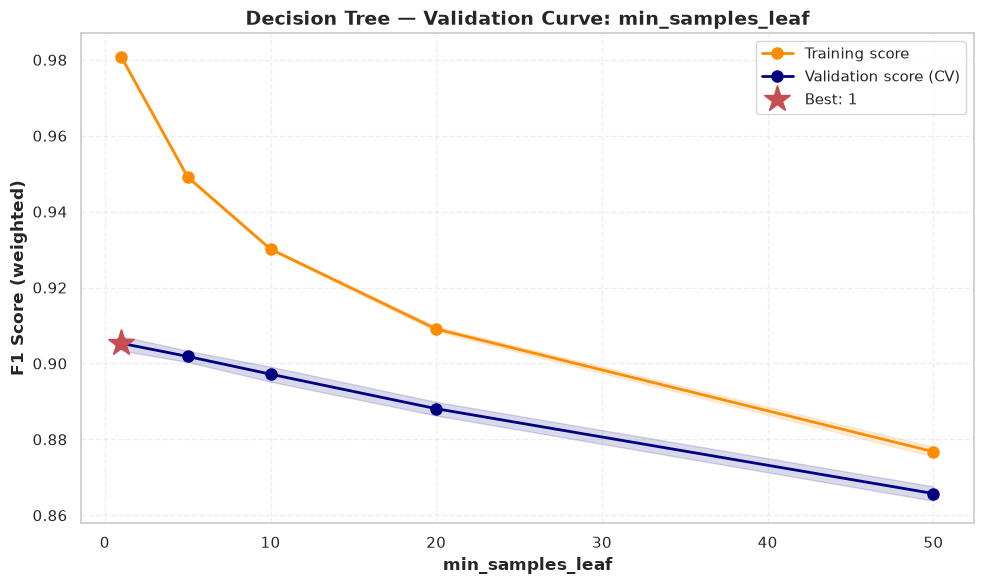

  Best min_samples_leaf: 1
    Validation F1: 0.9053 (+/- 0.0019)
    Training F1:   0.9807 (+/- 0.0005)
    Gap: 0.0754
    >> Acceptable generalisation

Analyzing clf__criterion...


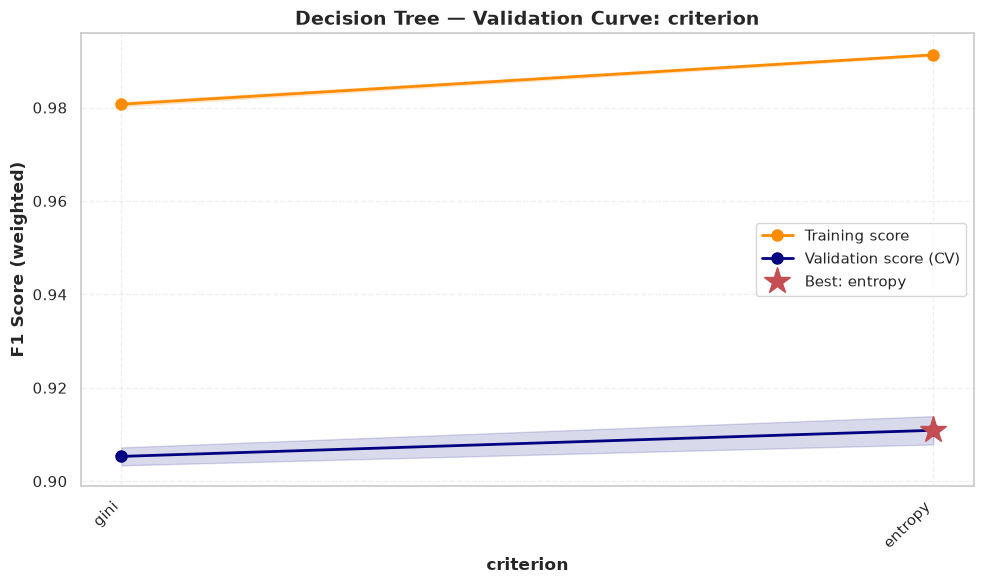

  Best criterion: entropy
    Validation F1: 0.9109 (+/- 0.0030)
    Training F1:   0.9913 (+/- 0.0002)
    Gap: 0.0804
    >> Acceptable generalisation

 TUNING COMPLETE: Decision Tree
Best parameters found (iteratively):
  max_depth: 20
  min_samples_leaf: 1
  criterion: entropy

Final CV F1 (last parameter): 0.9109

Training Decision Tree with best parameters on full training set...
Model trained and ready for evaluation.



In [15]:

dt_params, dt_score, dt_model = tune_and_plot("Decision Tree", X_train_split, y_train_split)


 TUNING: K-Nearest Neighbors (Iterative Validation Curves)


Analyzing pca...


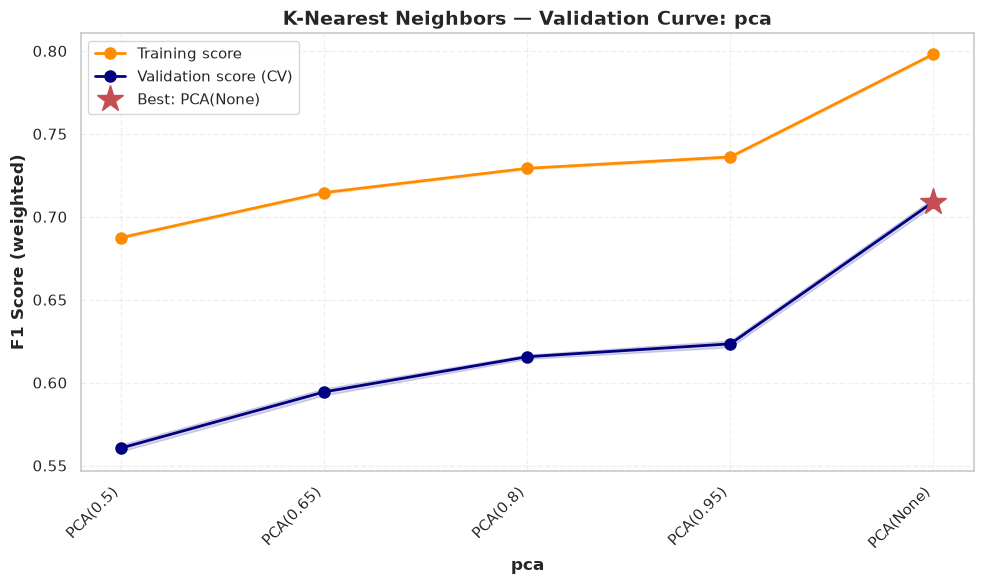

  Best pca: LinearDiscriminantAnalysis()
    Validation F1: 0.7090 (+/- 0.0023)
    Training F1:   0.7981 (+/- 0.0007)
    Gap: 0.0891
    >> Acceptable generalisation

Analyzing clf__n_neighbors...


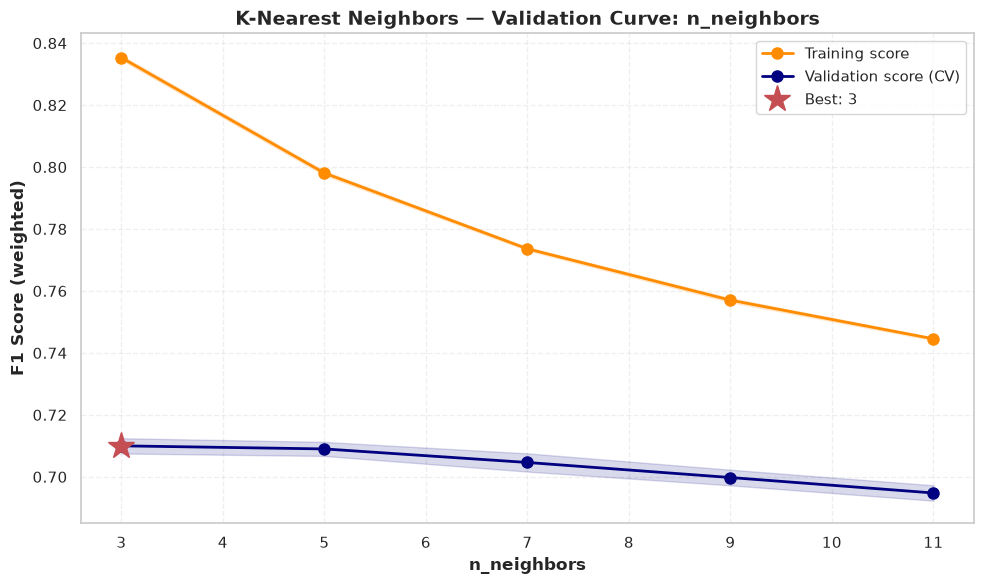

  Best n_neighbors: 3
    Validation F1: 0.7100 (+/- 0.0025)
    Training F1:   0.8353 (+/- 0.0007)
    Gap: 0.1253
    >> Acceptable generalisation

Analyzing clf__weights...


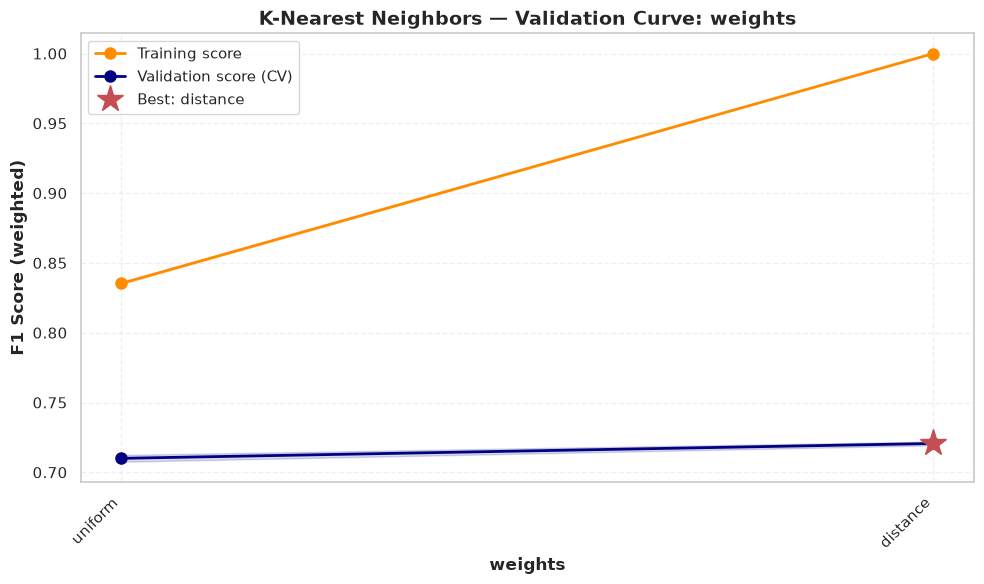

  Best weights: distance
    Validation F1: 0.7206 (+/- 0.0014)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.2794
    >> Overfitting detected (gap > 0.15)

Analyzing clf__metric...


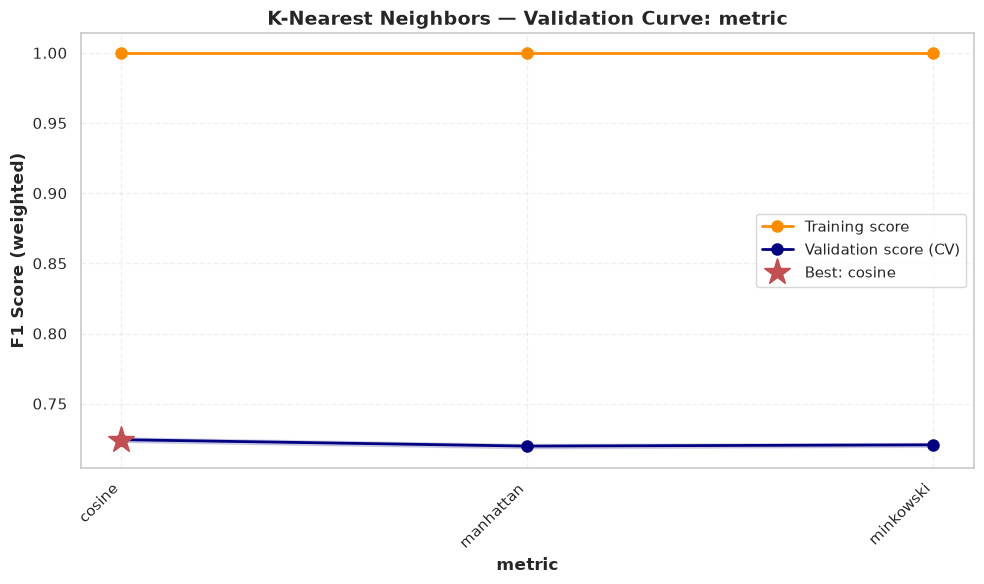

  Best metric: cosine
    Validation F1: 0.7243 (+/- 0.0016)
    Training F1:   1.0000 (+/- 0.0000)
    Gap: 0.2757
    >> Overfitting detected (gap > 0.15)

 TUNING COMPLETE: K-Nearest Neighbors
Best parameters found (iteratively):
  pca: LinearDiscriminantAnalysis()
  n_neighbors: 3
  weights: distance
  metric: cosine

Final CV F1 (last parameter): 0.7243

Training K-Nearest Neighbors with best parameters on full training set...
Model trained and ready for evaluation.



In [16]:
knn_params, knn_score, knn_model = tune_and_plot("K-Nearest Neighbors", X_train_split, y_train_split, cv=5)


 MODEL COMPARISON — BEST VALIDATION SCORES

1. Random Forest
   Best CV F1-Score: 0.9239
   Best parameters:
     n_estimators: 300
     max_depth: 30
     min_samples_leaf: 1
     max_features: sqrt

2. Decision Tree
   Best CV F1-Score: 0.9109
   Best parameters:
     max_depth: 20
     min_samples_leaf: 1
     criterion: entropy

3. K-Nearest Neighbors
   Best CV F1-Score: 0.7243
   Best parameters:
     pca: LinearDiscriminantAnalysis()
     n_neighbors: 3
     weights: distance
     metric: cosine

 BEST MODEL: Random Forest
   CV F1-Score: 0.9239


Random Forest - training
Train weighted F1: 0.9999 | Test weighted F1: 0.8538
Train accuracy:    0.9999 | Test accuracy:    0.8557
Diagnosis: acceptable generalisation (F1 gap=0.146)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.829     0.865     0.847     34777
            adnxs.com      0.945     0.891     0.917      2942
      ads-twitter.com 

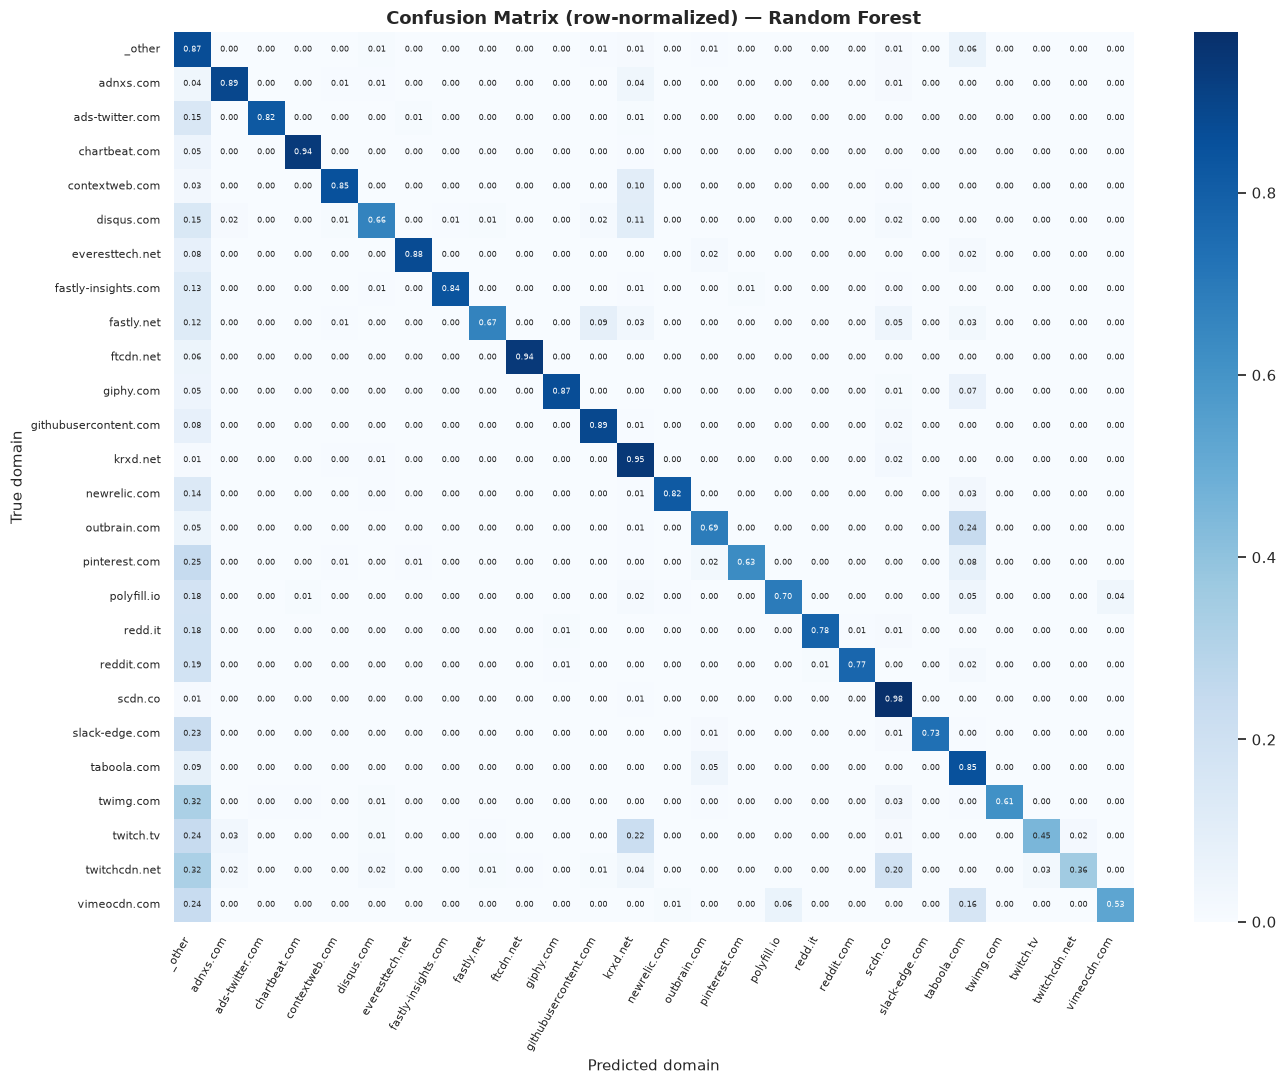


Decision Tree - training
Train weighted F1: 0.9887 | Test weighted F1: 0.8269
Train accuracy:    0.9887 | Test accuracy:    0.8263
Diagnosis: possible overfitting (F1 gap=0.162)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.862     0.782     0.820     34777
            adnxs.com      0.907     0.910     0.909      2942
      ads-twitter.com      0.775     0.936     0.848      1135
        chartbeat.com      0.933     0.937     0.935      1717
       contextweb.com      0.831     0.860     0.845      2383
           disqus.com      0.762     0.722     0.742      3246
      everesttech.net      0.871     0.893     0.882      2894
  fastly-insights.com      0.891     0.790     0.838       686
           fastly.net      0.757     0.718     0.737      1455
            ftcdn.net      0.973     0.970     0.971      1607
            giphy.com      0.747     0.837     0.790      1730
githubusercontent.com

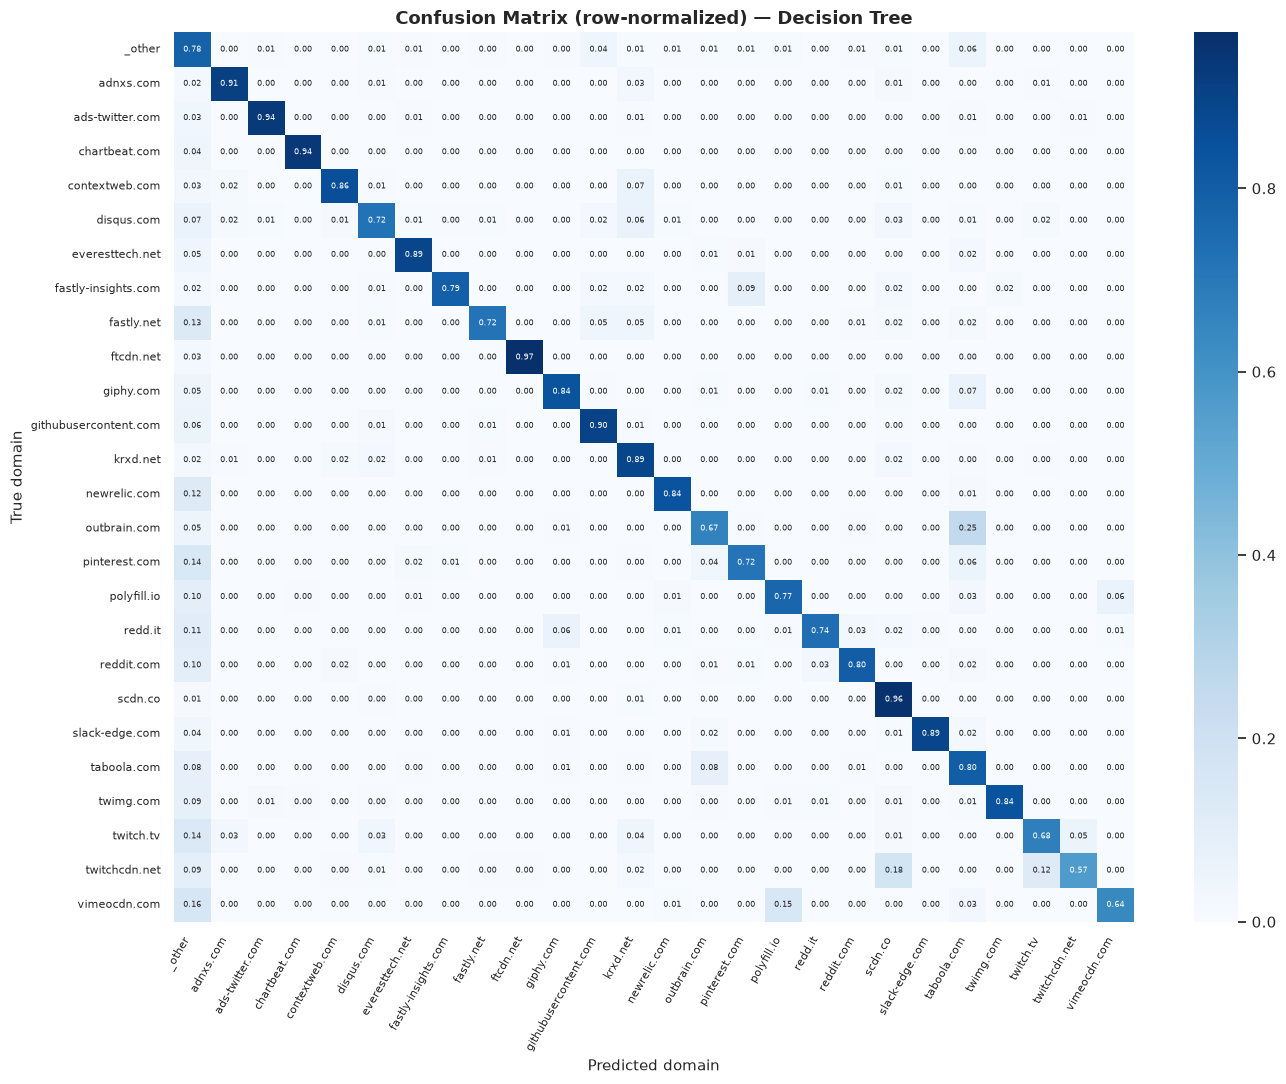


K-Nearest Neighbors - training
Train weighted F1: 1.0000 | Test weighted F1: 0.5698
Train accuracy:    1.0000 | Test accuracy:    0.5726
Diagnosis: possible overfitting (F1 gap=0.430)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.636     0.573     0.603     34777
            adnxs.com      0.509     0.509     0.509      2942
      ads-twitter.com      0.295     0.288     0.291      1135
        chartbeat.com      0.405     0.369     0.386      1717
       contextweb.com      0.537     0.518     0.527      2383
           disqus.com      0.431     0.416     0.423      3246
      everesttech.net      0.463     0.410     0.435      2894
  fastly-insights.com      0.677     0.794     0.731       686
           fastly.net      0.269     0.214     0.239      1455
            ftcdn.net      0.929     0.919     0.924      1607
            giphy.com      0.547     0.696     0.612      1730
githubuserconte

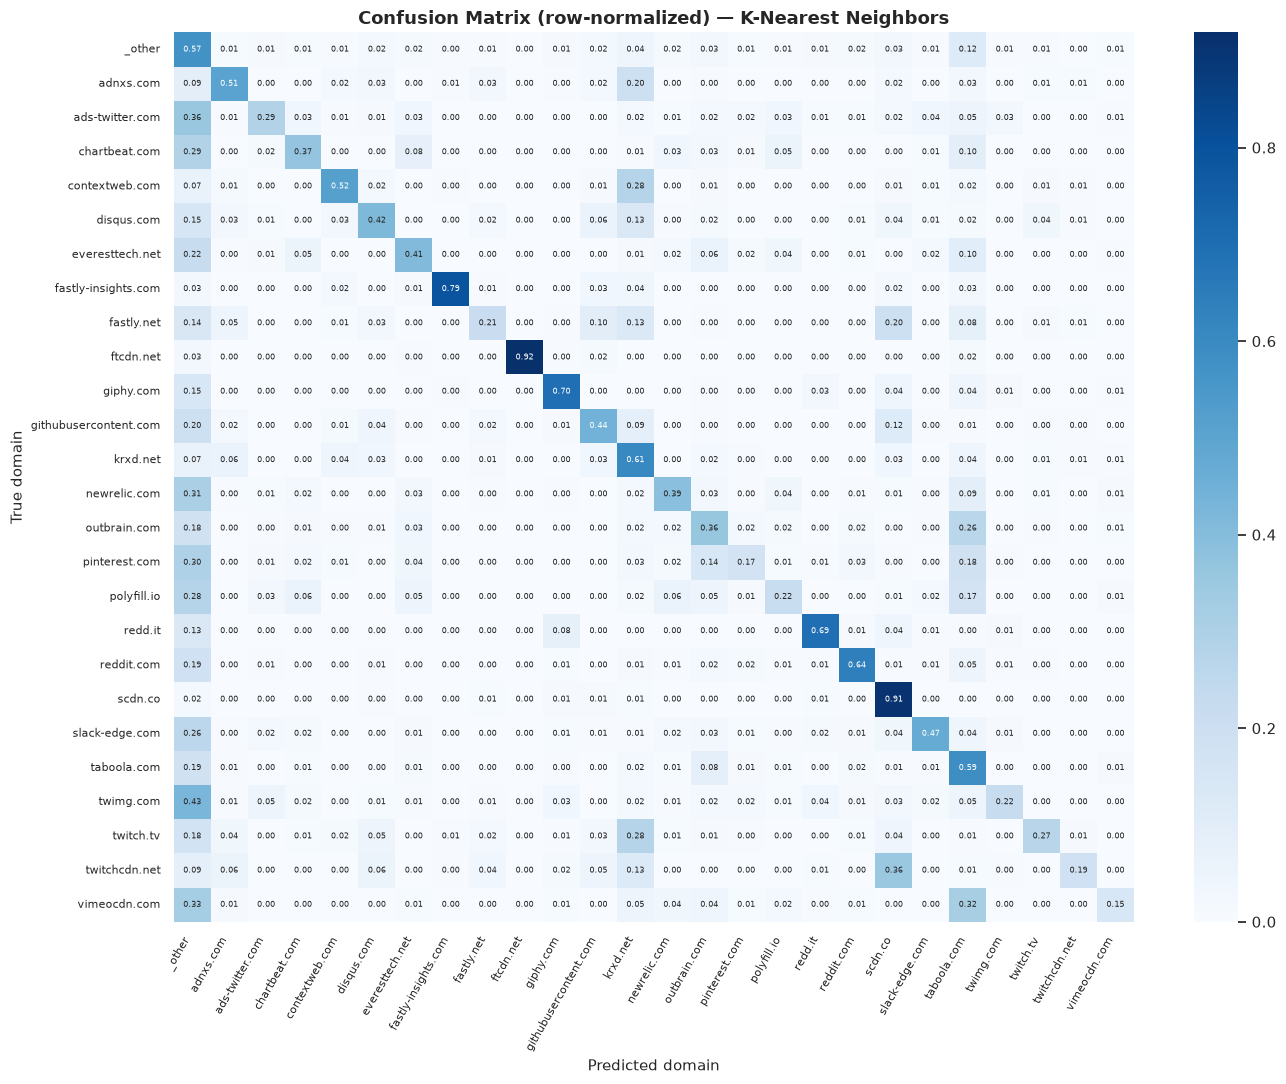


Tuned model ranking on official test set


,model,train_f1_weighted,test_f1_weighted,train_accuracy,test_accuracy,diagnosis
0,Random Forest,0.999892,0.853845,0.999892,0.855699,acceptable generalisation (F1 gap=0.146)
1,Decision Tree,0.988662,0.826873,0.988699,0.826340,possible overfitting (F1 gap=0.162)
2,K-Nearest Neighbors,1.000000,0.569788,1.000000,0.572587,possible overfitting (F1 gap=0.430)


In [17]:
# -- Compare and select best tuned model --
model_comparison = {
    'Random Forest': (rf_score, rf_params, rf_model),
    'Decision Tree': (dt_score, dt_params, dt_model),
    'K-Nearest Neighbors': (knn_score, knn_params, knn_model)
}

best_tuned_name = compare_tuned_models(model_comparison)

# Store tuned models in dict for downstream use
tunbest_models = {
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'K-Nearest Neighbors': knn_model
}

# -- Evaluate tuned models on the official test set --
tuned_test_results, _ = evaluate_classification_models(
    tunbest_models,
    X_train_cv,
    y_train_cv,
    X_test_cv,
    y_test_cv
)

print("\nTuned model ranking on official test set")
display(tuned_test_results)

### Section 2.3 – Error Analysis

A classifier that achieves good aggregate metrics may still fail systematically on certain domains. Error analysis reveals *where* and *why* the best model makes mistakes, which is essential for:
- Understanding the limitations of the traffic features used.
- Identifying domains whose traffic patterns are genuinely indistinguishable.
- Suggesting targeted improvements (e.g., additional features, domain grouping).

We perform two complementary analyses:

1. **Multi-class One-vs-Rest (OvR) ROC Curves & AUC**: the normalised confusion matrix reveals *which* domain pairs are confused, while the ROC curves (One-vs-Rest) and AUC scores quantify how well the model *ranks* class probabilities for each domain, independently of the decision threshold.

2. **False Positive / False Negative analysis**: identify which domain pairs are confused most often, quantifying precision loss (FP) and recall loss (FN) per class, as well as the most frequent confusion pairs.



Decision Tree - training
Train weighted F1: 1.0000 | Test weighted F1: 0.8028
Train accuracy:    1.0000 | Test accuracy:    0.8019
Diagnosis: possible overfitting (F1 gap=0.197)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.835     0.749     0.790     34777
            adnxs.com      0.899     0.899     0.899      2942
      ads-twitter.com      0.765     0.893     0.824      1135
        chartbeat.com      0.565     0.919     0.699      1717
       contextweb.com      0.795     0.842     0.818      2383
           disqus.com      0.738     0.686     0.711      3246
      everesttech.net      0.887     0.855     0.870      2894
  fastly-insights.com      0.783     0.757     0.769       686
           fastly.net      0.741     0.765     0.753      1455
            ftcdn.net      0.961     0.963     0.962      1607
            giphy.com      0.756     0.812     0.783      1730
githubusercontent.com

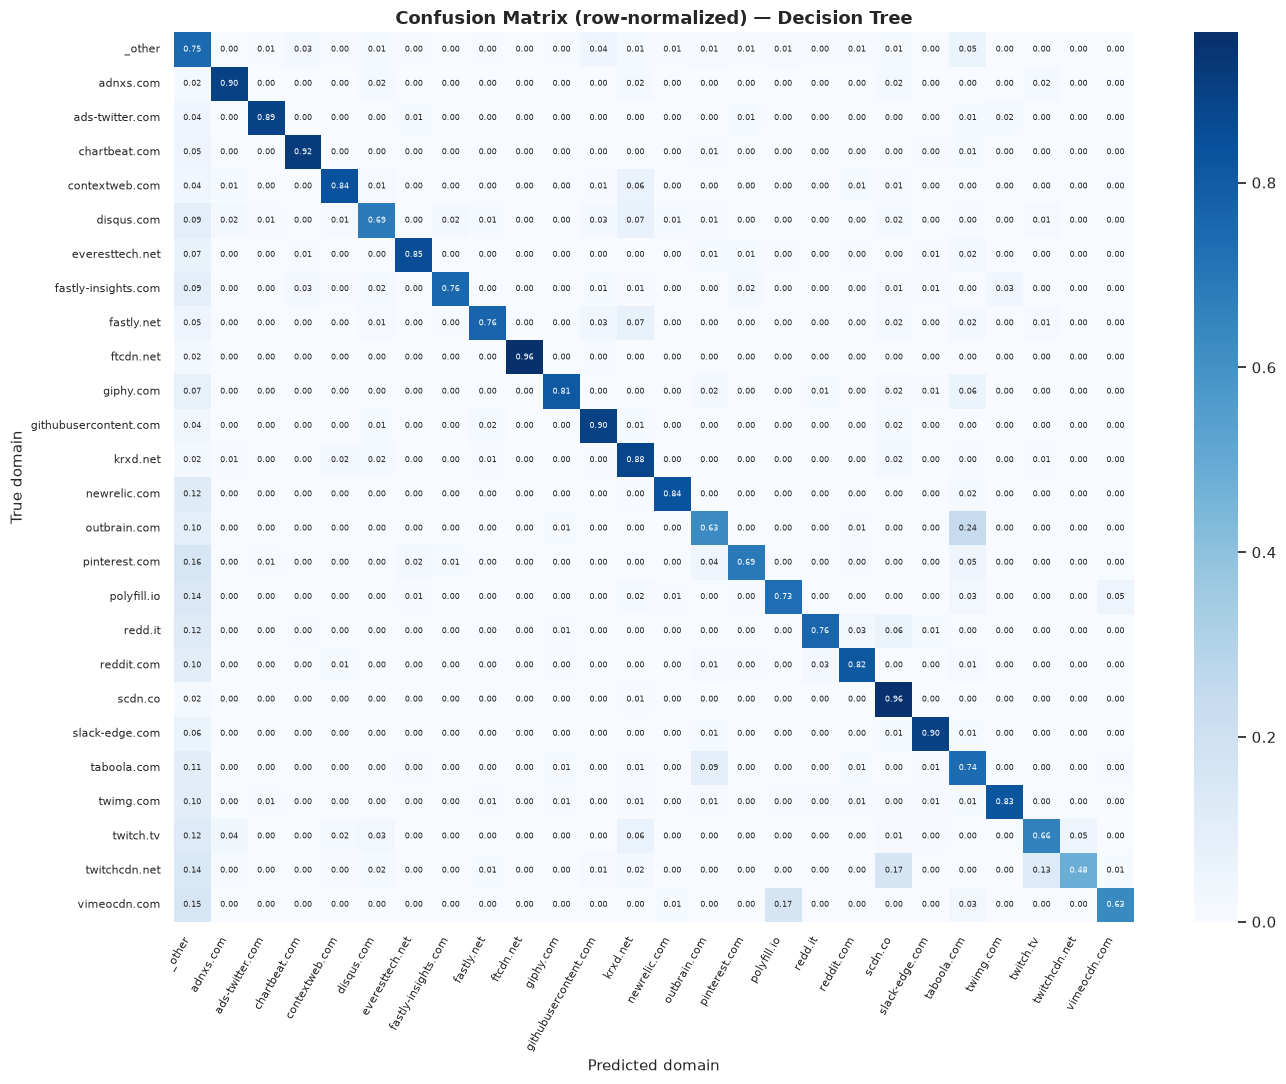


Random Forest - training
Train weighted F1: 1.0000 | Test weighted F1: 0.8503
Train accuracy:    1.0000 | Test accuracy:    0.8521
Diagnosis: acceptable generalisation (F1 gap=0.150)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.826     0.861     0.843     34777
            adnxs.com      0.946     0.884     0.914      2942
      ads-twitter.com      0.960     0.823     0.886      1135
        chartbeat.com      0.941     0.942     0.941      1717
       contextweb.com      0.897     0.846     0.871      2383
           disqus.com      0.815     0.655     0.726      3246
      everesttech.net      0.938     0.868     0.901      2894
  fastly-insights.com      0.973     0.841     0.902       686
           fastly.net      0.899     0.645     0.751      1455
            ftcdn.net      0.992     0.940     0.965      1607
            giphy.com      0.925     0.868     0.895      1730
githubuserconten

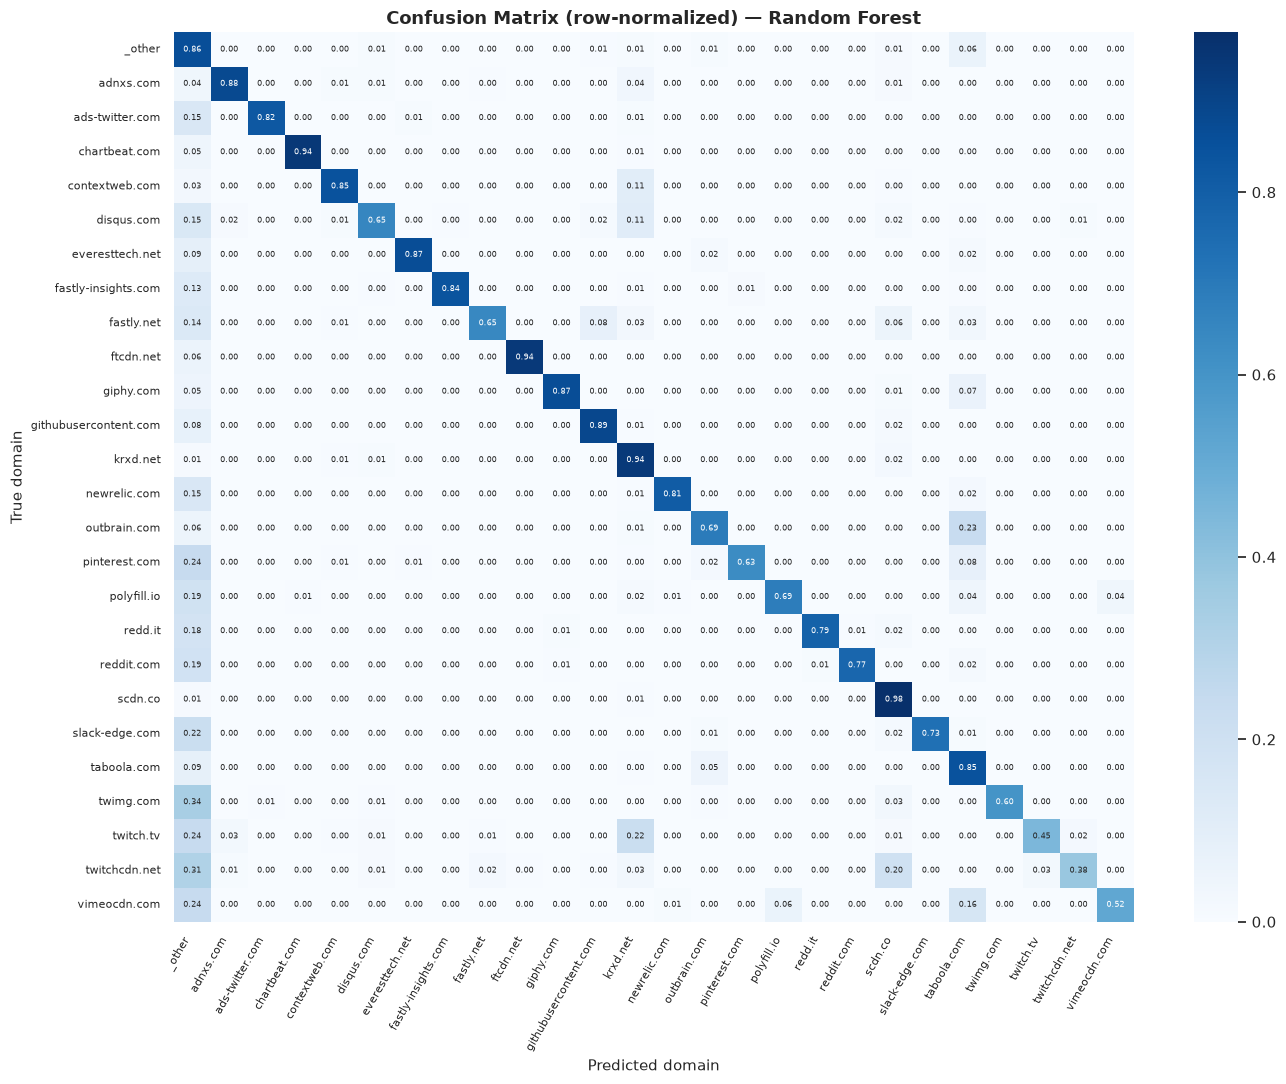


K-Nearest Neighbors - training
Train weighted F1: 0.7495 | Test weighted F1: 0.4840
Train accuracy:    0.7573 | Test accuracy:    0.4977
Diagnosis: possible overfitting (F1 gap=0.265)

Per-class F-measure on official test set:
                       precision    recall  f1-score   support

               _other      0.532     0.593     0.561     34777
            adnxs.com      0.428     0.399     0.413      2942
      ads-twitter.com      0.189     0.122     0.149      1135
        chartbeat.com      0.312     0.296     0.304      1717
       contextweb.com      0.302     0.295     0.298      2383
           disqus.com      0.341     0.202     0.253      3246
      everesttech.net      0.307     0.253     0.277      2894
  fastly-insights.com      0.536     0.723     0.615       686
           fastly.net      0.166     0.116     0.137      1455
            ftcdn.net      0.928     0.904     0.916      1607
            giphy.com      0.432     0.584     0.496      1730
githubuserconte

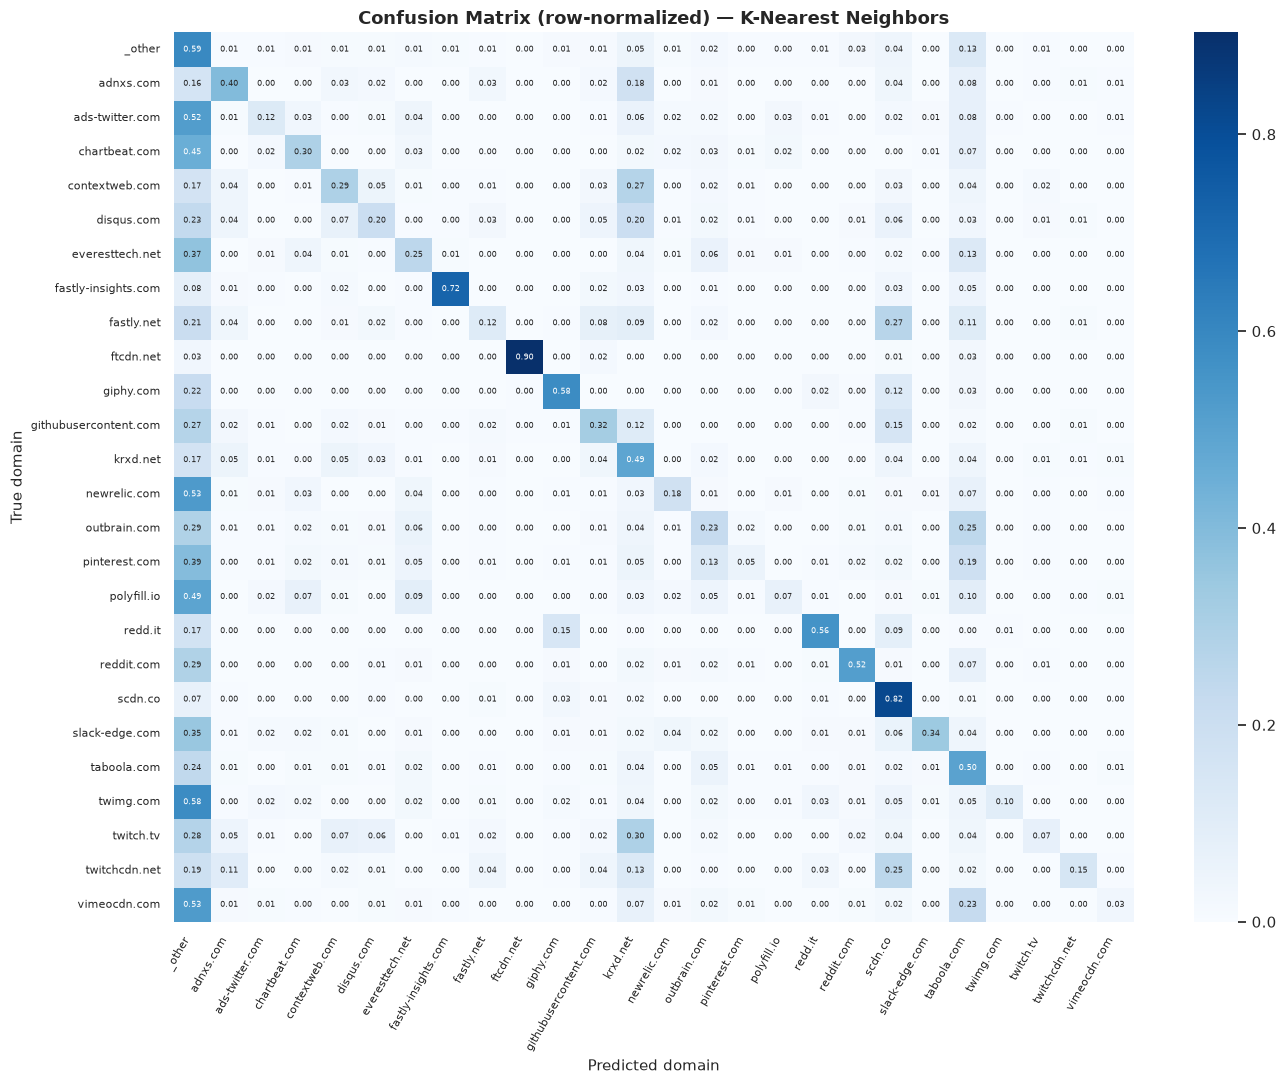


Default model results on official test set


,model,train_f1_weighted,test_f1_weighted,train_accuracy,test_accuracy,diagnosis
1,Random Forest,1.000000,0.850325,1.000000,0.852077,acceptable generalisation (F1 gap=0.150)
0,Decision Tree,1.000000,0.802751,1.000000,0.801938,possible overfitting (F1 gap=0.197)
2,K-Nearest Neighbors,0.749519,0.484027,0.757323,0.497678,possible overfitting (F1 gap=0.265)


Best classifier: Random Forest (tuned)


,model,train_f1_weighted,test_f1_weighted,train_accuracy,test_accuracy,diagnosis,source
3,Random Forest,0.999892,0.853845,0.999892,0.855699,acceptable generalisation (F1 gap=0.146),tuned
0,Random Forest,1.000000,0.850325,1.000000,0.852077,acceptable generalisation (F1 gap=0.150),default
4,Decision Tree,0.988662,0.826873,0.988699,0.826340,possible overfitting (F1 gap=0.162),tuned
1,Decision Tree,1.000000,0.802751,1.000000,0.801938,possible overfitting (F1 gap=0.197),default
5,K-Nearest Neighbors,1.000000,0.569788,1.000000,0.572587,possible overfitting (F1 gap=0.430),tuned
2,K-Nearest Neighbors,0.749519,0.484027,0.757323,0.497678,possible overfitting (F1 gap=0.265),default


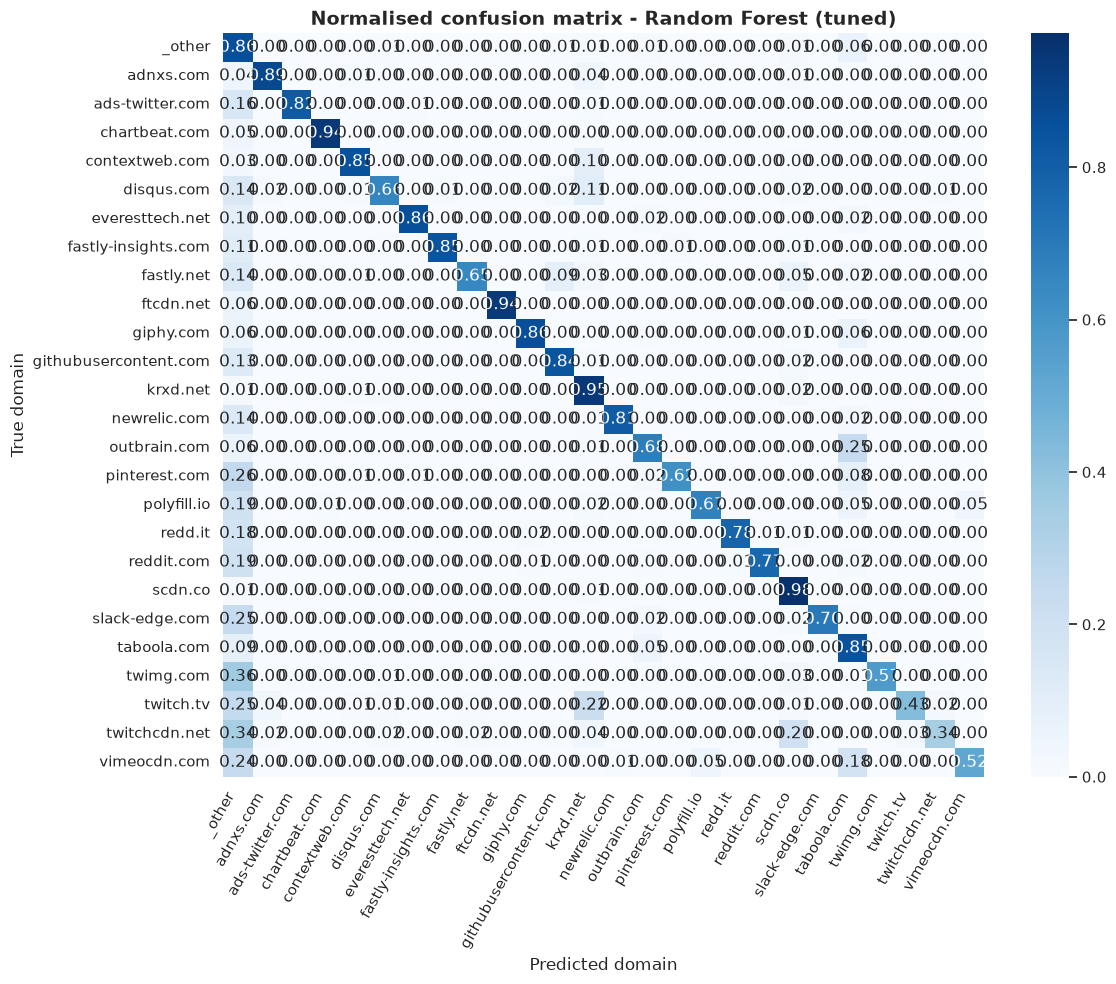

                       precision    recall  f1-score   support

               _other      0.820     0.860     0.840     34777
            adnxs.com      0.941     0.886     0.913      2942
      ads-twitter.com      0.976     0.819     0.891      1135
        chartbeat.com      0.949     0.942     0.945      1717
       contextweb.com      0.891     0.852     0.871      2383
           disqus.com      0.852     0.657     0.741      3246
      everesttech.net      0.937     0.861     0.898      2894
  fastly-insights.com      0.948     0.845     0.894       686
           fastly.net      0.924     0.651     0.764      1455
            ftcdn.net      0.992     0.941     0.966      1607
            giphy.com      0.922     0.864     0.892      1730
githubusercontent.com      0.889     0.838     0.863      4477
             krxd.net      0.874     0.945     0.908     11171
         newrelic.com      0.908     0.814     0.858      1604
         outbrain.com      0.690     0.683     0.687  

In [18]:
# ---------------------------------------------------------------------------
# Evaluate default models on the test set (first test-set use)
# ---------------------------------------------------------------------------
# The test set was intentionally NOT used during Sections 2.1 and 2.2.
# Now that all model selection and tuning decisions are finalised, we
# evaluate the default models on the official test set for comparison
# with the tuned models.
# ---------------------------------------------------------------------------

classification_default_results, _ = evaluate_classification_models(
    {name: trained_default_models[name] for name in trained_default_models},
    X_train_cv,
    y_train_cv,
    X_test_cv,
    y_test_cv
)

print("\nDefault model results on official test set")
display(classification_default_results)

# ---------------------------------------------------------------------------
# Select the best classifier (default or tuned)
# ---------------------------------------------------------------------------
# We compare ALL trained models (default + tuned) and select the one with
# the highest test F1. This is the model we will analyse in depth.
# ---------------------------------------------------------------------------

def select_best_classifier(default_results, tuned_results, default_models, tuned_models):
    default_ranked = default_results.copy()
    default_ranked['source'] = 'default'
    tuned_ranked = tuned_results.copy()
    tuned_ranked['source'] = 'tuned'
    all_results = pd.concat([default_ranked, tuned_ranked], ignore_index=True)
    best_row = all_results.sort_values('test_f1_weighted', ascending=False).iloc[0]
    model_name = best_row['model']
    source = best_row['source']
    model = tuned_models[model_name] if source == 'tuned' else default_models[model_name]
    return model_name, source, model, all_results


best_clf_name, best_clf_source, best_clf, all_classification_results = select_best_classifier(
    classification_default_results,
    tuned_test_results,
    trained_default_models,
    tunbest_models
)

print(f"Best classifier: {best_clf_name} ({best_clf_source})")
display(all_classification_results.sort_values('test_f1_weighted', ascending=False))

# -- Predictions on the test set --
y_pred_best = pd.Series(
    best_clf.predict(X_test_cv),
    index=y_test_cv.index,
    name='predicted_label'
)

# -- Normalised confusion matrix --
# Normalisation by true label (rows sum to 1) shows the recall per class
# and highlights which domains are most often confused with each other.
cm = confusion_matrix(y_test_cv, y_pred_best, labels=best_clf.classes_, normalize='true')
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=best_clf.classes_, yticklabels=best_clf.classes_)
plt.title(f'Normalised confusion matrix - {best_clf_name} ({best_clf_source})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted domain')
plt.ylabel('True domain')
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_test_cv, y_pred_best, digits=3))


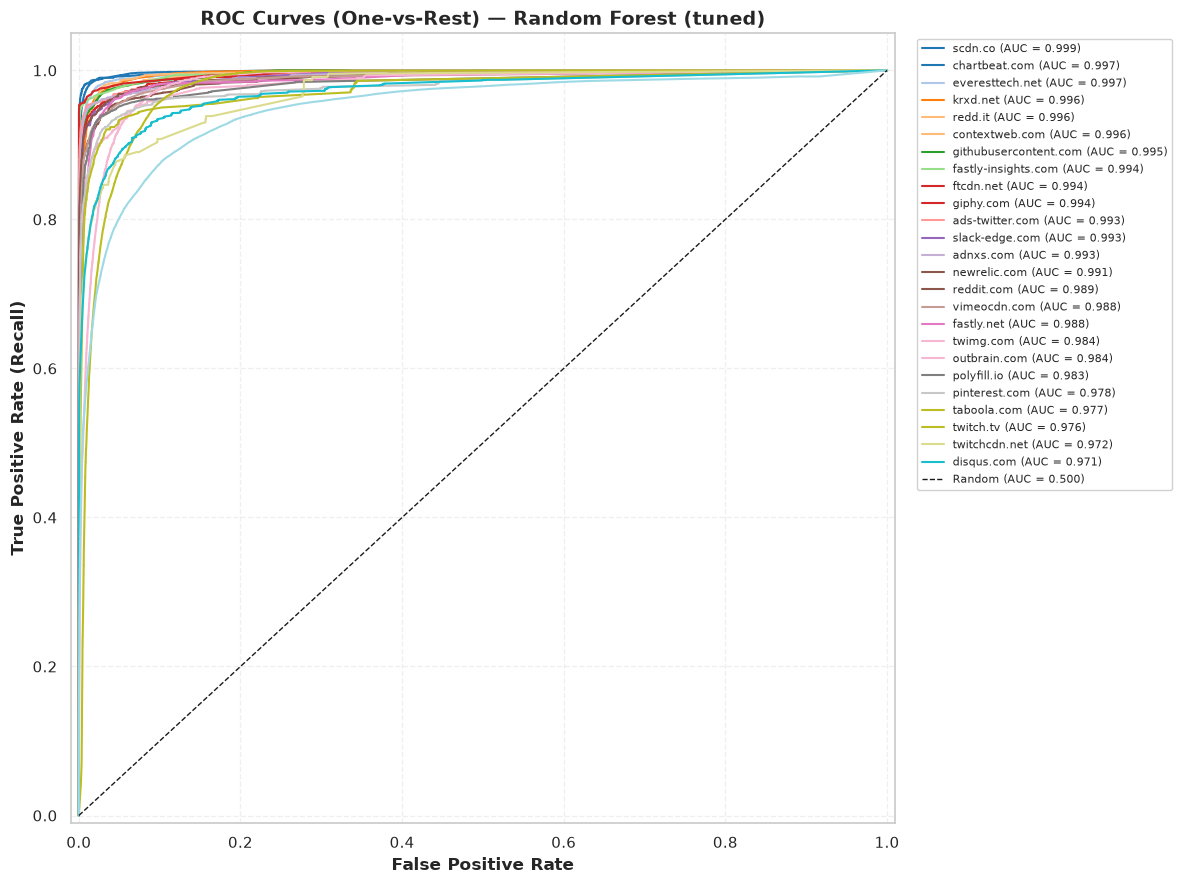


AUC Summary — Random Forest (tuned)
  Macro-average AUC: 0.9873
  Weighted-average AUC: 0.9774
  Min AUC: 0.9501 (_other)
  Max AUC: 0.9985 (scdn.co)


,Domain,AUC,Support
0,scdn.co,0.998549,13223
1,chartbeat.com,0.996930,1717
2,everesttech.net,0.996616,2894
3,krxd.net,0.996138,11171
4,redd.it,0.996083,1855
5,contextweb.com,0.995607,2383
6,githubusercontent.com,0.995216,4477
7,fastly-insights.com,0.994333,686
8,ftcdn.net,0.994288,1607
9,giphy.com,0.993793,1730


In [19]:
# ---------------------------------------------------------------------------
# ROC Curves and AUC — One-vs-Rest (OvR) strategy
# ---------------------------------------------------------------------------
# The ROC curve shows the model's ability to *rank* class probabilities
# correctly, independently of the decision threshold. This is complementary
# to the F1-score, which evaluates performance at a fixed threshold (0.5).
#
# A domain can have a moderate F1-score but a high AUC: this means the model
# understands the class well but the default threshold is suboptimal (common
# for minority classes). Conversely, a low AUC indicates genuine confusion
# between classes that no threshold adjustment can fix.
#
# We use the One-vs-Rest (OvR) strategy: for each domain, we binarise the
# labels into "this domain" vs "all others" and compute the ROC curve on the
# predicted probabilities.
# ---------------------------------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = best_clf.classes_
y_test_bin = label_binarize(y_test_cv, classes=classes)
y_score = best_clf.predict_proba(X_test_cv)

# -- Compute per-class ROC and AUC --
fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i, cls in enumerate(classes):
    fpr_dict[cls], tpr_dict[cls], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_dict[cls] = auc(fpr_dict[cls], tpr_dict[cls])

# -- Sort classes by AUC for the legend --
sorted_classes = sorted(auc_dict, key=auc_dict.get, reverse=True)

# -- Plot --
fig, ax = plt.subplots(figsize=(12, 9))

cmap = plt.cm.tab20
for idx, cls in enumerate(sorted_classes):
    ax.plot(fpr_dict[cls], tpr_dict[cls],
            color=cmap(idx / len(sorted_classes)),
            linewidth=1.5,
            label=f'{cls} (AUC = {auc_dict[cls]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
ax.set_title(f'ROC Curves (One-vs-Rest) — {best_clf_name} ({best_clf_source})',
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.show()

# -- Summary table --
auc_df = pd.DataFrame([
    {'Domain': cls, 'AUC': auc_dict[cls], 'Support': int((y_test_cv == cls).sum())}
    for cls in sorted_classes
])
print(f"\nAUC Summary — {best_clf_name} ({best_clf_source})")
print(f"  Macro-average AUC: {auc_df['AUC'].mean():.4f}")
print(f"  Weighted-average AUC: {np.average(auc_df['AUC'], weights=auc_df['Support']):.4f}")
print(f"  Min AUC: {auc_df['AUC'].min():.4f} ({auc_df.iloc[-1]['Domain']})")
print(f"  Max AUC: {auc_df['AUC'].max():.4f} ({auc_df.iloc[0]['Domain']})")
display(auc_df)

In [20]:
# ---------------------------------------------------------------------------
# FP / FN analysis
# ---------------------------------------------------------------------------
# For each domain we compute:
# - FP (False Positives): flows from OTHER domains predicted as this domain
#   -> precision loss. High FP means the model "attracts" flows it shouldn't.
# - FN (False Negatives): flows of this domain predicted as another domain
#   -> recall loss. High FN means the model "loses" flows it should catch.
# - FP_rate = FP / (TP + FP): fraction of predicted positives that are wrong.
# - FN_rate = FN / (TP + FN): fraction of actual positives that are missed.
# ---------------------------------------------------------------------------

def build_fp_fn_table(y_true, y_pred):
    """Build a per-class FP/FN table sorted by most problematic domains."""
    labels = sorted(pd.unique(pd.concat([pd.Series(y_true), pd.Series(y_pred)])))
    rows = []
    for label in labels:
        true_mask = (y_true == label)
        pred_mask = (y_pred == label)
        tp = int((true_mask & pred_mask).sum())
        fp = int((~true_mask & pred_mask).sum())
        fn = int((true_mask & ~pred_mask).sum())
        support = int(true_mask.sum())
        rows.append({
            'label': label,
            'support': support,
            'TP': tp, 'FP': fp, 'FN': fn,
            'precision_loss_FP_rate': fp / max(int(pred_mask.sum()), 1),
            'recall_loss_FN_rate': fn / max(support, 1)
        })
    return pd.DataFrame(rows).sort_values(['FN', 'FP'], ascending=False)


fp_fn_table = build_fp_fn_table(y_test_cv, y_pred_best)
print('Labels with most false negatives / false positives')
display(fp_fn_table.head(12))

# -- Most frequent confusion pairs --
# This answers the question: "Which specific domain pairs get mixed up?"
# High-count pairs suggest that those domains have very similar traffic patterns.
confusions = pd.DataFrame({'true': y_test_cv, 'predicted': y_pred_best})
confusion_pairs = (
    confusions[confusions['true'] != confusions['predicted']]
    .value_counts(['true', 'predicted'])
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)
print('\nMost frequent confusion pairs')
display(confusion_pairs.head(15))

Labels with most false negatives / false positives


,label,support,TP,FP,FN,precision_loss_FP_rate,recall_loss_FN_rate
0,_other,34777,29924,6564,4853,0.179895,0.139546
21,taboola.com,15764,13394,4015,2370,0.230628,0.150343
14,outbrain.com,4426,3023,1356,1403,0.309660,0.316991
5,disqus.com,3246,2131,371,1115,0.148281,0.343500
11,githubusercontent.com,4477,3753,470,724,0.111295,0.161715
12,krxd.net,11171,10558,1527,613,0.126355,0.054874
15,pinterest.com,1542,952,74,590,0.072125,0.382620
8,fastly.net,1455,947,78,508,0.076098,0.349141
25,vimeocdn.com,965,505,110,460,0.178862,0.476684
17,redd.it,1855,1444,109,411,0.070187,0.221563



Most frequent confusion pairs


,true,predicted,count
0,_other,taboola.com,2233
1,taboola.com,_other,1350
2,outbrain.com,taboola.com,1087
3,taboola.com,outbrain.com,813
4,githubusercontent.com,_other,577
5,_other,scdn.co,471
6,disqus.com,_other,466
7,_other,outbrain.com,408
8,pinterest.com,_other,397
9,disqus.com,krxd.net,352


### Final Test Set Evaluation

This section provides the **definitive comparison** of all models (default and tuned) on the official test set. The test set was held out throughout the entire process:
- It was **not** used during default training or cross-validation (Section 2.1).
- It was **not** used during hyper-parameter tuning (Section 2.2).
- It is used here only once for the final, unbiased performance estimate.

The leaderboard ranks all model configurations by test F1-score. We also visualise the train–test gap for each model to assess generalisation: a large gap indicates overfitting, while similar train and test scores indicate good generalisation.


 FINAL MODEL LEADERBOARD



,Model,Train F1,Test F1,Train Acc,Test Acc,Gap,Diagnosis
1,Random Forest (Default),1.000000,0.850325,1.000000,0.852077,0.149675,acceptable generalisation (F1 gap=0.150)
3,Random Forest (Tuned),0.985882,0.847428,0.985906,0.849319,0.138454,acceptable generalisation (F1 gap=0.138)
4,Decision Tree (Tuned),0.975239,0.822031,0.975241,0.821636,0.153207,possible overfitting (F1 gap=0.153)
0,Decision Tree (Default),1.000000,0.802751,1.000000,0.801938,0.197249,possible overfitting (F1 gap=0.197)
5,K-Nearest Neighbors (Tuned),0.947601,0.561478,0.947715,0.564741,0.386123,possible overfitting (F1 gap=0.386)
2,K-Nearest Neighbors (Default),0.749519,0.484027,0.757323,0.497678,0.265491,possible overfitting (F1 gap=0.265)



 WINNER: Random Forest (Default)
    Test F1:  0.8503
    Test Acc: 0.8521
    Gap:      0.1497



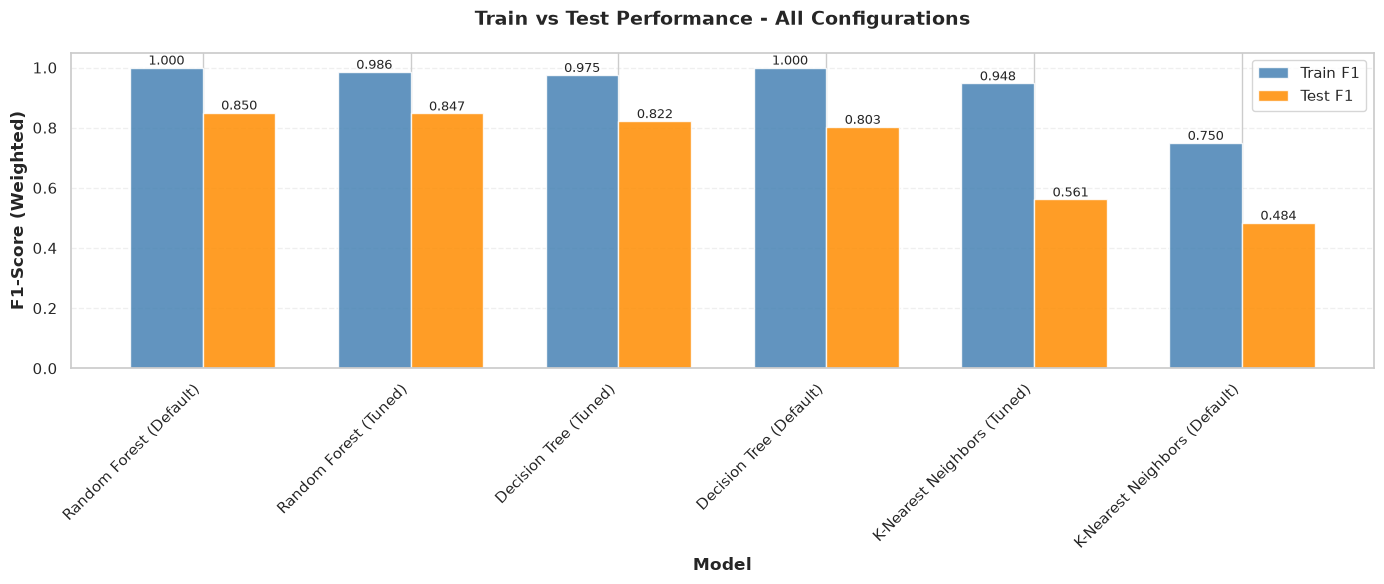


 CLASSIFICATION SUMMARY
  Models evaluated:  6
  Best model:        Random Forest (Default)
  Best Test F1:      0.8503
  Generalisation:    acceptable generalisation (F1 gap=0.150)



In [24]:
print(f"\n{'='*80}")
print(" FINAL MODEL LEADERBOARD")
print(f"{'='*80}\n")

# -- Collect all models --
all_models = {}
for name, model in trained_default_models.items():
    all_models[f"{name} (Default)"] = model
for name, model in tunbest_models.items():
    all_models[f"{name} (Tuned)"] = model

# -- Evaluate each model --
leaderboard_rows = []
for model_label, model in all_models.items():
    y_pred_train = model.predict(X_train_cv)
    y_pred_test = model.predict(X_test_cv)

    f1_train = f1_score(y_train_cv, y_pred_train, average='weighted')
    f1_test = f1_score(y_test_cv, y_pred_test, average='weighted')
    acc_train = accuracy_score(y_train_cv, y_pred_train)
    acc_test = accuracy_score(y_test_cv, y_pred_test)
    gap = f1_train - f1_test

    leaderboard_rows.append({
        'Model': model_label,
        'Train F1': f1_train,
        'Test F1': f1_test,
        'Train Acc': acc_train,
        'Test Acc': acc_test,
        'Gap': gap,
        'Diagnosis': diagnose_classification_fit(f1_train, f1_test)
    })

leaderboard_df = pd.DataFrame(leaderboard_rows).sort_values('Test F1', ascending=False)
display(leaderboard_df)

# -- Winner --
winner_row = leaderboard_df.iloc[0]
print(f"\n{'='*80}")
print(f" WINNER: {winner_row['Model']}")
print(f"    Test F1:  {winner_row['Test F1']:.4f}")
print(f"    Test Acc: {winner_row['Test Acc']:.4f}")
print(f"    Gap:      {winner_row['Gap']:.4f}")
print(f"{'='*80}\n")

# -- Visual comparison: Train vs Test F1 --
fig, ax = plt.subplots(figsize=(14, 6))
models_list = leaderboard_df['Model'].tolist()
x = range(len(models_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               leaderboard_df['Train F1'].values,
               width, label='Train F1', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x],
               leaderboard_df['Test F1'].values,
               width, label='Test F1', color='darkorange', alpha=0.85)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score (Weighted)', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test Performance - All Configurations',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# -- Summary --
print(f"\n{'='*80}")
print(f" CLASSIFICATION SUMMARY")
print(f"{'='*80}")
print(f"  Models evaluated:  {len(all_models)}")
print(f"  Best model:        {winner_row['Model']}")
print(f"  Best Test F1:      {winner_row['Test F1']:.4f}")
print(f"  Generalisation:    {winner_row['Diagnosis']}")
print(f"{'='*80}\n")

## 3. Unsupervised Learning - Clustering Domain Names

In [5]:
## FEATURE ENG
def feature_eng_for_cluser(df,agg_dict):
  df["intLabel"] = pd.factorize(df["label"])[0] + 1
  y_int = df["intLabel"].values


  df_grouped = df.groupby('label').agg(agg_dict)
  df_grouped.columns = ['_'.join(col).strip() for col in df_grouped.columns.values]
  df_grouped = df_grouped.replace([np.inf, -np.inf], np.nan)
  df_grouped = df_grouped.fillna(0)

  # aggiungi intLabel per le righe di df_grouped (1..N)
  df_grouped["intLabel"] = pd.factorize(df_grouped.index)[0] + 1

  # Standardization
  scaler = StandardScaler()
  df_scaled = scaler.fit_transform(df_grouped)

  # PCA
  pca = PCA(n_components=min(10, df_grouped.shape[1], df_grouped.shape[0]))
  df_pca = pca.fit_transform(df_scaled)
  print(f"Shape AFTER PCA: {df_pca.shape}")
  print(f"Variance of 5 first component of PCA: {sum(pca.explained_variance_ratio_[:5])*100:.1f}%")

  y = df_grouped.index.to_numpy()  # domain name

  return df_grouped, df_pca, pca, y

In [6]:
#feature aggregation
#df copy + call function (retunt df_grouped and pca on aggregation)

agg_dict = {
    # Payload
    '_c_bytes_all': ['mean', 'std', 'max'],
    '_s_bytes_all': ['mean', 'std', 'max'],
    '_c_pkts_all': ['mean', 'std'],
    '_s_pkts_all': ['mean', 'std',],
    '_c_rtt_avg': ['mean', 'std', 'min', 'max'],
    '_s_rtt_avg': ['mean', 'std', 'min', 'max'],
    '_durat':       ['mean', 'max','std'],

    # Connnection
    '_c_pkts_retx': [ 'mean'],
    '_s_pkts_retx': ['mean'],
    '_s_rst_cnt':   ['mean'],
    '_s_mss':       ['max'],
    '_s_win_scl':   ['max'],
    '_c_msgsize1':  ['mean'],
    '_c_pkts_ooo': ['mean'],
    '_s_pkts_ooo': [ 'mean'],
    '_tls_session_stat': ['mean'],

    # n conn
    'c_ip': 'count'
}
df_to_work = train_raw.copy()
df_grouped, df_pca, pca, y = feature_eng_for_cluser(df_to_work,agg_dict)


Shape AFTER PCA: (26, 10)
Variance of 5 first component of PCA: 75.7%


In [14]:
# =========================
# 2)  FIND K
# =========================
def find_best_k_elbow(X_pca, y_true=None, k_min=3, k_max=12, random_state=42, n_init=50,plot=True):


    if isinstance(X_pca, pd.DataFrame):
        X = X_pca.to_numpy()
    else:
        X = X_pca

    # y_true opzionale (può essere string o int)
    if y_true is not None:
        y_true = np.ravel(y_true)


    n_samples = X.shape[0]


    ks = list(range(k_min, k_max + 1))
    inertias = []
    mse_inertias = []
    silos = []
    ris = []
    aris = []

    for k in ks:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        labels = km.fit_predict(X)

        inertias.append(km.inertia_)
        mse_inertias.append(km.inertia_ / n_samples)
        silos.append(silhouette_score(X, labels))

        if y_true is not None:
            aris.append(adjusted_rand_score(y_true, labels))

    inertias = np.array(inertias)
    mse_inertias = np.array(mse_inertias)
    silos = np.array(silos)
    aris = np.array(aris) if y_true is not None else None

    # elbow via max distance from line
    x1, y1 = ks[0], inertias[0]
    x2, y2 = ks[-1], inertias[-1]
    line_vec = np.array([x2 - x1, y2 - y1])
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for k, iner in zip(ks, inertias):
        p = np.array([k, iner])
        p1 = np.array([x1, y1])
        proj_len = np.dot(p - p1, line_vec_norm)
        proj_point = p1 + proj_len * line_vec_norm
        dist = np.linalg.norm(p - proj_point)
        distances.append(dist)

    distances = np.array(distances)
    best_k_elbow = ks[int(np.argmax(distances))]
    best_k_silhouette = ks[int(np.argmax(silos))]

    print(f"\n=== K-Means elbow & silhouette analysis with random state = {random_state}===")
    if y_true is None:
        print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'Distance':>10}")
        print("-" * 55)
        for k, iner, sil, dist in zip(ks, inertias, silos, distances):
            marker = " <--" if (k == best_k_elbow or k == best_k_silhouette) else ""
            print(f"{k:3d} | {iner:12.2e} | {sil:10.3f} | {dist:10.3f}{marker}")
    else:
        print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'ARI':>8} | {'Distance':>10}")
        print("-" * 85)
        for k, iner, sil, ari, dist in zip(ks, inertias, silos, aris, distances):
            marker = " <--" if (k == best_k_elbow or k == best_k_silhouette) else ""
            print(f"{k:3d} | {iner:12.2e} | {sil:10.3f} | {ari:8.3f} | {dist:10.3f}{marker}")

    print(f"\nBest K by ELBOW method    : {best_k_elbow}")
    print(f"Best K by SILHOUETTE score: {best_k_silhouette}")

    # Plot
    idx_elbow = ks.index(best_k_elbow)
    print("\n--- Metrics at best elbow k ---")
    print("Sum of squared distances of the samples from their centroid (SSE):", inertias[idx_elbow])
    print("Mean squared distances of the samples from their centroid (MSE):", mse_inertias[idx_elbow])
    print("Silhouette score of the samples:", silos[idx_elbow])

    # 3) Plot
    if plot:
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))

        # Plot 1: Elbow (Inertia)
        axs[0].plot(ks, inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
        axs[0].axvline(best_k_elbow, linestyle="--", color='red',
                       label=f'Elbow at k={best_k_elbow}', linewidth=2)
        axs[0].set_xlabel("Number of Clusters (k)", fontsize=11)
        axs[0].set_ylabel("Inertia", fontsize=11)
        axs[0].set_title("Elbow Method", fontsize=13, fontweight='bold')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend()

        axs[1].plot(ks, distances, 'o-', linewidth=2, markersize=8, color='orange')
        axs[1].axvline(best_k_elbow, linestyle="--", color='red',
                       label=f'Max distance at k={best_k_elbow}', linewidth=2)
        axs[1].set_xlabel("Number of Clusters (k)", fontsize=11)
        axs[1].set_ylabel("Distance from line", fontsize=11)
        axs[1].set_title("Elbow Detection (Distance)", fontsize=13, fontweight='bold')
        axs[1].grid(True, alpha=0.3)
        axs[1].legend()



        # Plot 2: Silhouette
        axs[2].plot(ks, silos, 'o-', linewidth=2, markersize=8, color='green')
        axs[2].axvline(best_k_silhouette, linestyle="--", color='red',
                       label=f'Best k={best_k_silhouette}', linewidth=2)
        axs[2].set_xlabel("Number of Clusters (k)", fontsize=11)
        axs[2].set_ylabel("Silhouette Score", fontsize=11)
        axs[2].set_title("Silhouette Analysis", fontsize=13, fontweight='bold')
        axs[2].grid(True, alpha=0.3)
        axs[2].legend()

        plt.tight_layout()
        plt.savefig("Elbow_and_Shilo.png", bbox_inches='tight', dpi=300)
        plt.show()

        # Plot 3: Distance from line (elbow detection)

        plt.close()

    return ks, inertias, silos, best_k_elbow, best_k_silhouette, distances, ris, aris





=== K-Means elbow & silhouette analysis with random state = 15===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000
  4 |     3.94e+02 |      0.261 |    0.000 |      0.745
  5 |     3.23e+02 |      0.266 |    0.000 |      1.300
  6 |     2.57e+02 |      0.271 |    0.000 |      1.726
  7 |     1.97e+02 |      0.285 |    0.000 |      2.022 <--
  8 |     1.53e+02 |      0.328 |    0.000 |      1.964 <--
  9 |     1.20e+02 |      0.266 |    0.000 |      1.693
 10 |     9.18e+01 |      0.221 |    0.000 |      1.297
 11 |     7.42e+01 |      0.242 |    0.000 |      0.679
 12 |     5.94e+01 |      0.223 |    0.000 |      0.000

Best K by ELBOW method    : 7
Best K by SILHOUETTE score: 8

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 196.86439139032436
Mean squared distances of the samples from 

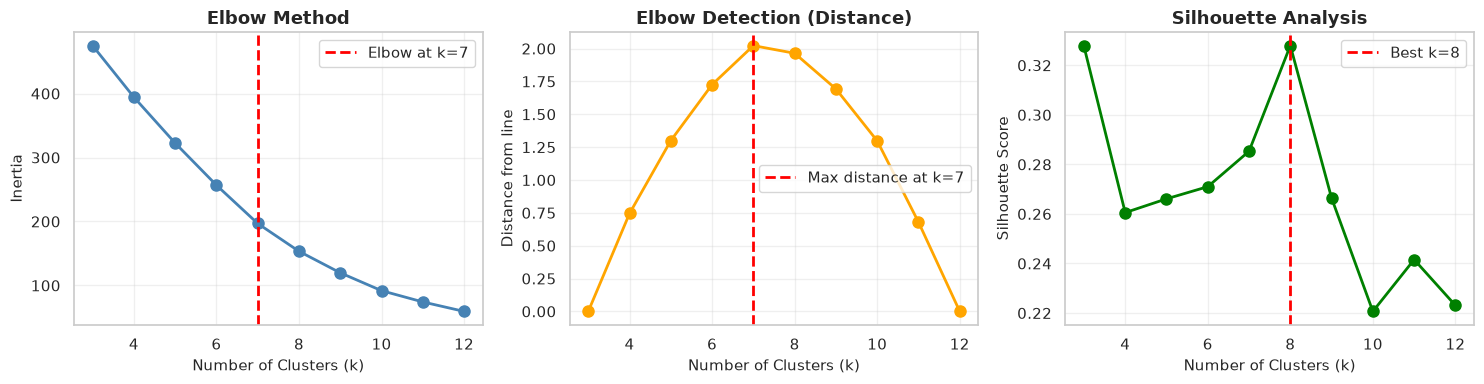


=== K-Means elbow & silhouette analysis with random state = 42===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000
  4 |     3.96e+02 |      0.303 |    0.000 |      0.702
  5 |     3.24e+02 |      0.264 |    0.000 |      1.274
  6 |     2.57e+02 |      0.272 |    0.000 |      1.728
  7 |     1.97e+02 |      0.285 |    0.000 |      2.028 <--
  8 |     1.53e+02 |      0.328 |    0.000 |      1.971
  9 |     1.20e+02 |      0.332 |    0.000 |      1.693 <--
 10 |     9.30e+01 |      0.244 |    0.000 |      1.280
 11 |     7.42e+01 |      0.242 |    0.000 |      0.688
 12 |     5.98e+01 |      0.206 |    0.000 |      0.000

Best K by ELBOW method    : 7
Best K by SILHOUETTE score: 9

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 196.86439139032433
Mean squared distances of the samples from 

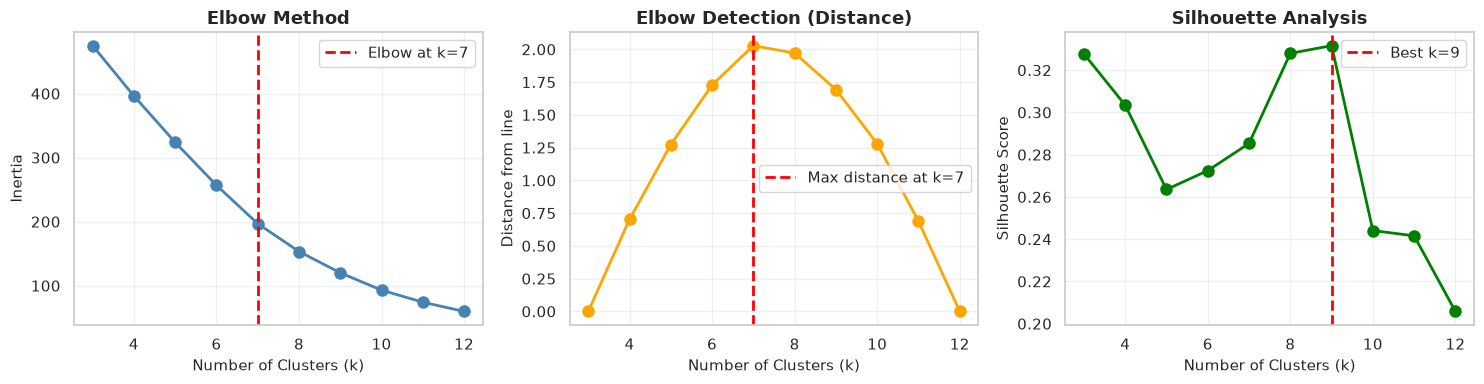


=== K-Means elbow & silhouette analysis with random state = 73===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000 <--
  4 |     3.94e+02 |      0.261 |    0.000 |      0.750
  5 |     3.24e+02 |      0.264 |    0.000 |      1.279
  6 |     2.55e+02 |      0.268 |    0.000 |      1.782
  7 |     1.97e+02 |      0.318 |    0.000 |      2.026 <--
  8 |     1.52e+02 |      0.319 |    0.000 |      2.006
  9 |     1.20e+02 |      0.270 |    0.000 |      1.705
 10 |     9.18e+01 |      0.221 |    0.000 |      1.319
 11 |     7.42e+01 |      0.242 |    0.000 |      0.702
 12 |     6.05e+01 |      0.200 |    0.000 |      0.000

Best K by ELBOW method    : 7
Best K by SILHOUETTE score: 3

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 197.42104855837667
Mean squared distances of the samples from 

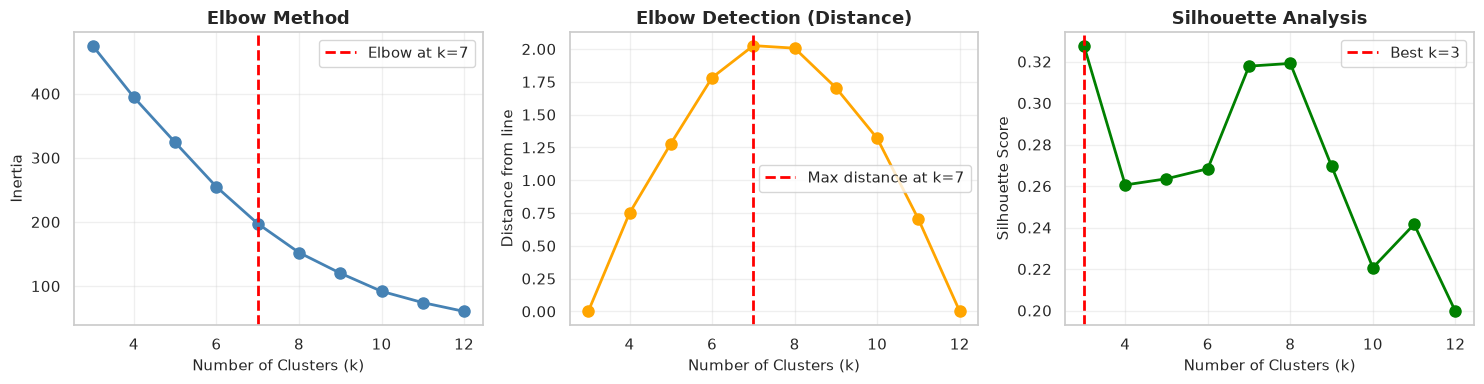


=== K-Means elbow & silhouette analysis with random state = 11===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000
  4 |     3.94e+02 |      0.261 |    0.000 |      0.749
  5 |     3.23e+02 |      0.266 |    0.000 |      1.307
  6 |     2.57e+02 |      0.271 |    0.000 |      1.736
  7 |     1.97e+02 |      0.318 |    0.000 |      2.023 <--
  8 |     1.53e+02 |      0.328 |    0.000 |      1.979 <--
  9 |     1.20e+02 |      0.270 |    0.000 |      1.701
 10 |     9.18e+01 |      0.221 |    0.000 |      1.315
 11 |     7.42e+01 |      0.242 |    0.000 |      0.698
 12 |     6.03e+01 |      0.180 |    0.000 |      0.000

Best K by ELBOW method    : 7
Best K by SILHOUETTE score: 8

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 197.42104855837664
Mean squared distances of the samples from 

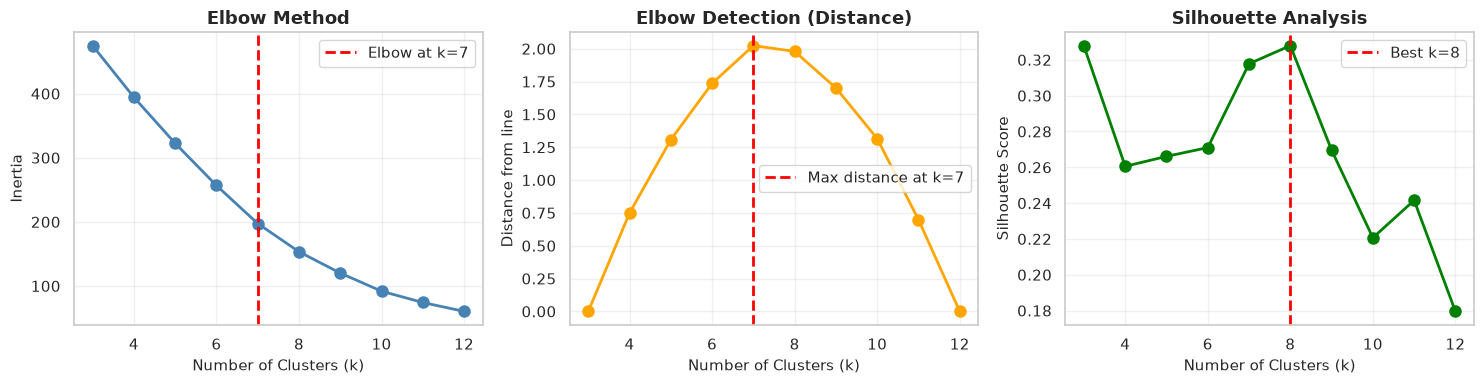


=== K-Means elbow & silhouette analysis with random state = 99===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000
  4 |     3.92e+02 |      0.265 |    0.000 |      0.807
  5 |     3.21e+02 |      0.273 |    0.000 |      1.339
  6 |     2.55e+02 |      0.268 |    0.000 |      1.774
  7 |     2.07e+02 |      0.301 |    0.000 |      1.806
  8 |     1.53e+02 |      0.328 |    0.000 |      1.971 <--
  9 |     1.20e+02 |      0.270 |    0.000 |      1.692
 10 |     9.18e+01 |      0.221 |    0.000 |      1.306
 11 |     7.42e+01 |      0.242 |    0.000 |      0.688
 12 |     5.98e+01 |      0.206 |    0.000 |      0.000

Best K by ELBOW method    : 8
Best K by SILHOUETTE score: 8

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 153.3836076619986
Mean squared distances of the samples from their

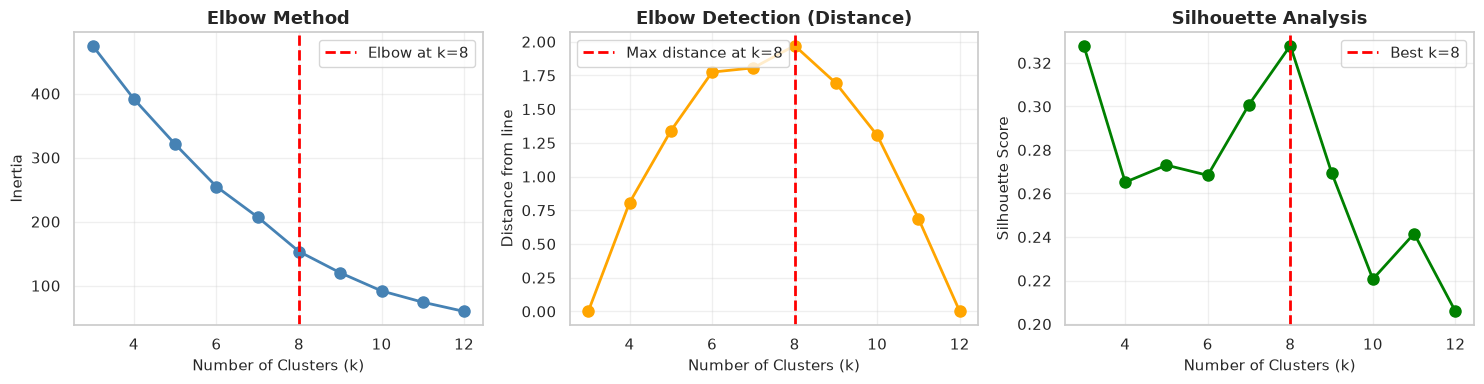


=== K-Means elbow & silhouette analysis with random state = 3===
  K |      Inertia | Silhouette |      ARI |   Distance
-------------------------------------------------------------------------------------
  3 |     4.75e+02 |      0.328 |    0.000 |      0.000
  4 |     3.93e+02 |      0.277 |    0.000 |      0.783
  5 |     3.23e+02 |      0.266 |    0.000 |      1.303
  6 |     2.59e+02 |      0.302 |    0.000 |      1.686
  7 |     1.97e+02 |      0.285 |    0.000 |      2.028 <--
  8 |     1.53e+02 |      0.328 |    0.000 |      1.971 <--
  9 |     1.20e+02 |      0.307 |    0.000 |      1.701
 10 |     9.18e+01 |      0.221 |    0.000 |      1.306
 11 |     7.42e+01 |      0.242 |    0.000 |      0.688
 12 |     5.98e+01 |      0.206 |    0.000 |      0.000

Best K by ELBOW method    : 7
Best K by SILHOUETTE score: 8

--- Metrics at best elbow k ---
Sum of squared distances of the samples from their centroid (SSE): 196.86439139032433
Mean squared distances of the samples from t

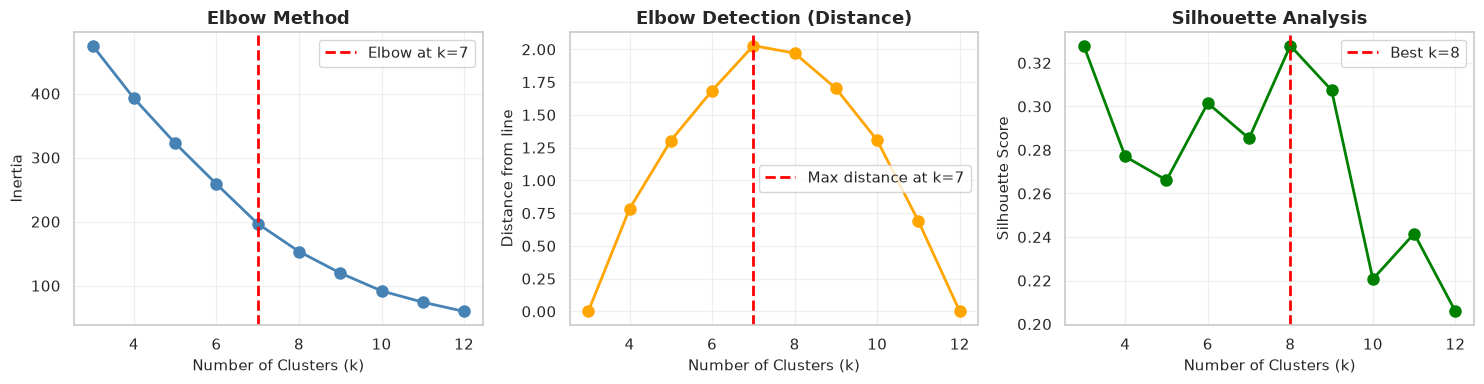

In [15]:
randomnumber=[15,42,73,11,99,3]

for num in randomnumber:
    y_int = df_grouped["intLabel"].values
    find_best_k_elbow(df_pca, y_true=y_int,random_state=num)

In [20]:
## KMEANS PLOT

def kmeans_plt(k, df_grouped, pca):
  kmeans2 = KMeans(n_clusters=k, n_init=10, random_state=15)
  labels2 = kmeans2.fit_predict(df_pca)
  inertia2 = kmeans2.inertia_
  sil2 = silhouette_score(df_pca, labels2)



  print(f"\n=== K-MEANS WITH k = {k} ===")
  print(f"\n=== data visualization ===")
  print(f"Inertia: {inertia2:.2f}")
  print(f"Silhouette: {sil2:.3f}")

  y = df_grouped.index.to_numpy()  # domain name
  domains_clusters2 = pd.DataFrame({"domain": y, "cluster": labels2})

  print(f"\n=== Cluster ===")
  for c in sorted(domains_clusters2["cluster"].unique()):
      doms = domains_clusters2[domains_clusters2.cluster == c]["domain"].tolist()
      print(f"\nCluster {c} ({len(doms)} domini):")

      print(doms)  # mostra solo i primi 10

  #Centroids
  projection = pd.DataFrame(df_pca[:, :2], columns=["PC1", "PC2"])
  projection["domain"] = y
  projection["cluster"] = labels2

  fig, ax = plt.subplots(1, 1, figsize=(10, 8))
  colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] #choose what u whant

  for c in sorted(projection["cluster"].unique()):
      subdf = projection[projection["cluster"] == c]
      ax.scatter(subdf["PC1"], subdf["PC2"],
                label=f"Cluster {c}",
                s=50,
                alpha=0.6,
                color=colors[c % len(colors)])

  #PC1 and PC2 centroids
  centroids_pca = kmeans2.cluster_centers_
  for idx in range(centroids_pca.shape[0]):
      cx = centroids_pca[idx, 0]
      cy = centroids_pca[idx, 1]
      ax.scatter(cx, cy,
                marker='x',
                s=50,
                c='red',
                edgecolors='black',
                linewidths=2,
                zorder=10,
                label=f"Centroid {idx}" if idx == 0 else "")

  ax.grid(True, alpha=0.3)
  ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
  ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
  ax.set_title(f"K-Means Clustering (k={k}) - PCA Space", fontsize=14, fontweight='bold')
  ax.legend(loc="best", framealpha=0.9)

  plt.tight_layout()
  plt.savefig(f"k{k}_kmeans_plot.png")
  plt.show()


  centroids_df = pd.DataFrame(
      centroids_pca[:, :5],
      columns=[f"PC{i+1}" for i in range(5)],
      index=[f"Cluster {i}" for i in range(k)]
  )
  print("Centroids of firsts 5 PC:")
  print(centroids_df)



=== K-MEANS WITH k = 2 ===

=== data visualization ===
Inertia: 574.85
Silhouette: 0.279

=== Cluster ===

Cluster 0 (17 domini):
['adnxs.com', 'ads-twitter.com', 'chartbeat.com', 'contextweb.com', 'disqus.com', 'everesttech.net', 'fastly-insights.com', 'fastly.net', 'ftcdn.net', 'githubusercontent.com', 'krxd.net', 'newrelic.com', 'outbrain.com', 'pinterest.com', 'polyfill.io', 'twitch.tv', 'twitchcdn.net']

Cluster 1 (9 domini):
['_other', 'giphy.com', 'redd.it', 'reddit.com', 'scdn.co', 'slack-edge.com', 'taboola.com', 'twimg.com', 'vimeocdn.com']


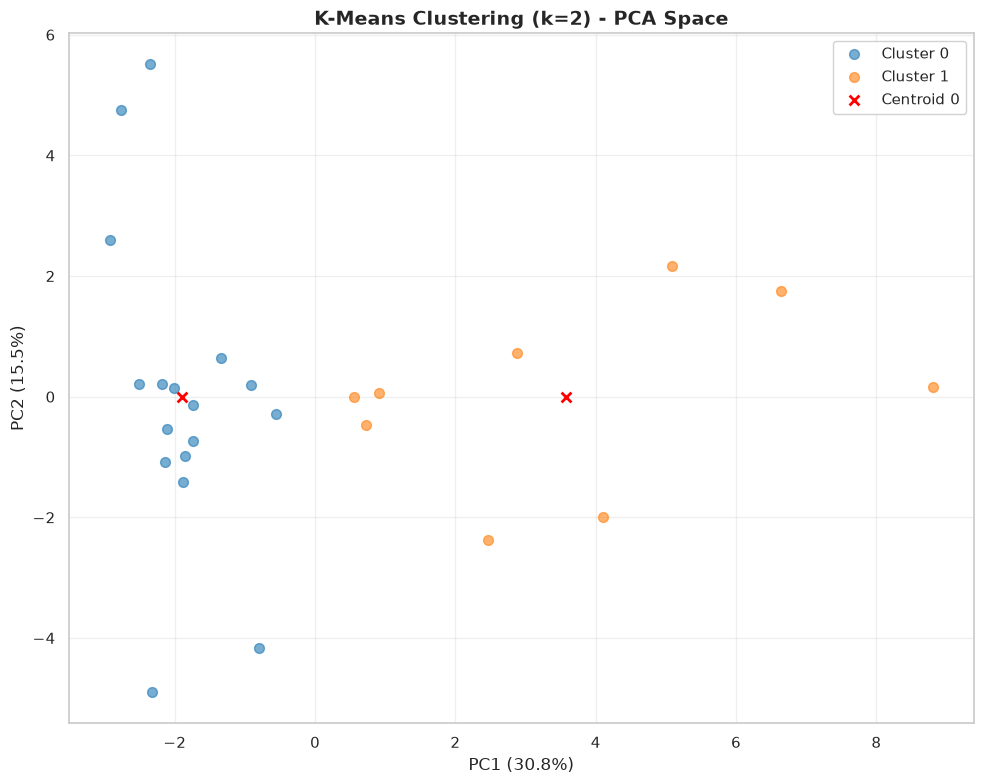

Centroids of firsts 5 PC:
                PC1       PC2       PC3       PC4       PC5
Cluster 0 -1.892302  0.000764  0.212883 -0.011393  0.432576
Cluster 1  3.574348 -0.001442 -0.402112  0.021520 -0.817087

=== K-MEANS WITH k = 7 ===

=== data visualization ===
Inertia: 201.91
Silhouette: 0.316

=== Cluster ===

Cluster 0 (1 domini):
['scdn.co']

Cluster 1 (14 domini):
['adnxs.com', 'ads-twitter.com', 'chartbeat.com', 'contextweb.com', 'disqus.com', 'everesttech.net', 'fastly.net', 'githubusercontent.com', 'krxd.net', 'newrelic.com', 'outbrain.com', 'pinterest.com', 'polyfill.io', 'twimg.com']

Cluster 2 (6 domini):
['ftcdn.net', 'giphy.com', 'redd.it', 'reddit.com', 'slack-edge.com', 'taboola.com']

Cluster 3 (1 domini):
['vimeocdn.com']

Cluster 4 (1 domini):
['_other']

Cluster 5 (2 domini):
['twitch.tv', 'twitchcdn.net']

Cluster 6 (1 domini):
['fastly-insights.com']


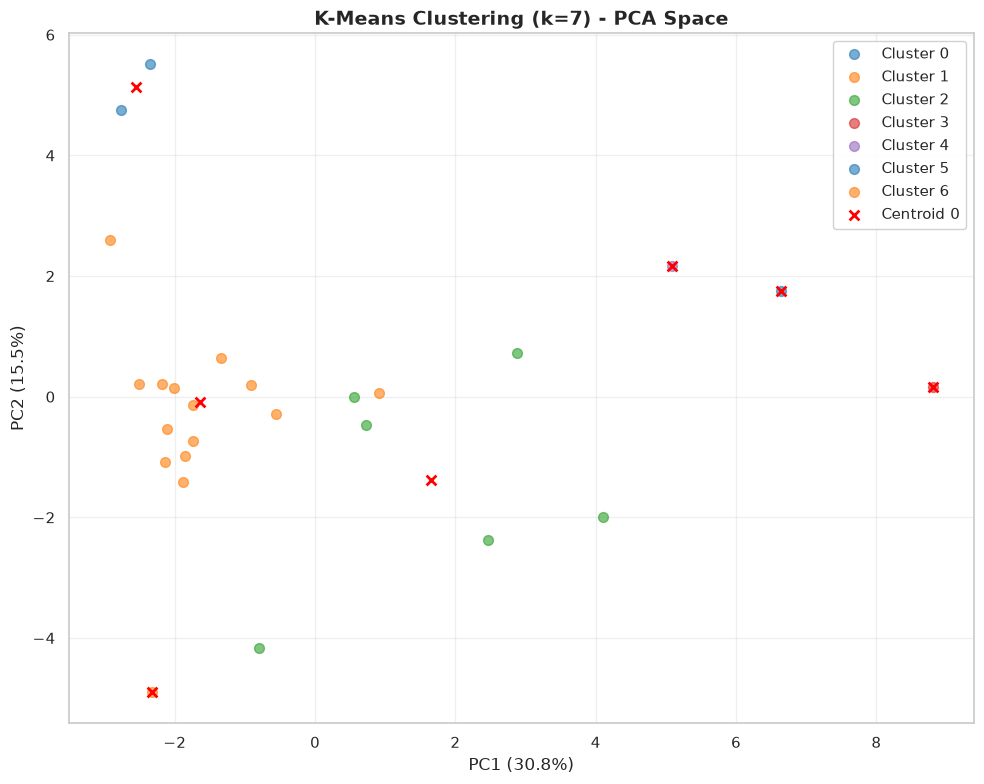

Centroids of firsts 5 PC:
                PC1       PC2       PC3       PC4       PC5
Cluster 0  6.633189  1.747579 -4.536715  2.812464  3.055359
Cluster 1 -1.644568 -0.081468  0.006808 -0.050579  0.508709
Cluster 2  1.655323 -1.383896 -1.169256 -0.471800 -1.926856
Cluster 3  8.804607  0.153777  5.031836 -4.284055  2.190110
Cluster 4  5.087468  2.169926  3.499040  5.470044 -1.041043
Cluster 5 -2.557728  5.130881  0.354106 -0.885229 -0.485997
Cluster 6 -2.317796 -4.889112  2.217854  1.310910  1.206784

=== K-MEANS WITH k = 8 ===

=== data visualization ===
Inertia: 153.38
Silhouette: 0.328

=== Cluster ===

Cluster 0 (1 domini):
['scdn.co']

Cluster 1 (14 domini):
['adnxs.com', 'ads-twitter.com', 'chartbeat.com', 'contextweb.com', 'disqus.com', 'everesttech.net', 'fastly.net', 'githubusercontent.com', 'krxd.net', 'newrelic.com', 'outbrain.com', 'pinterest.com', 'polyfill.io', 'twimg.com']

Cluster 2 (1 domini):
['vimeocdn.com']

Cluster 3 (5 domini):
['giphy.com', 'redd.it', 'reddit.com

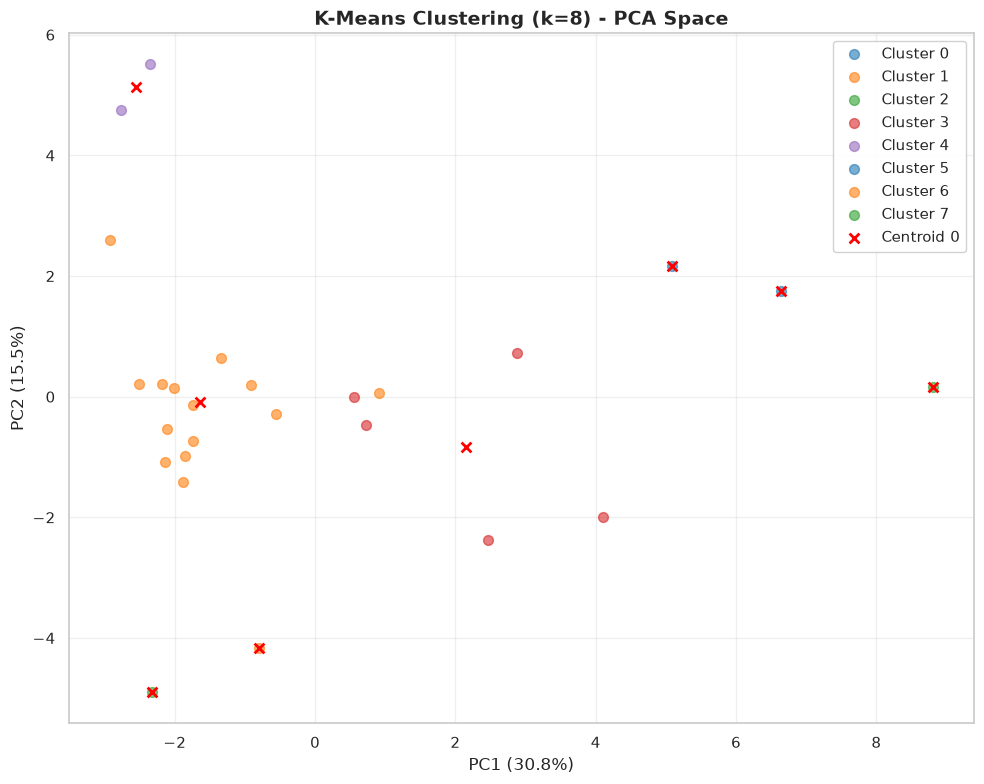

Centroids of firsts 5 PC:
                PC1       PC2       PC3       PC4       PC5
Cluster 0  6.633189  1.747579 -4.536715  2.812464  3.055359
Cluster 1 -1.644568 -0.081468  0.006808 -0.050579  0.508709
Cluster 2  8.804607  0.153777  5.031836 -4.284055  2.190110
Cluster 3  2.147194 -0.828787 -1.282302 -0.444054 -2.410528
Cluster 4 -2.557728  5.130881  0.354106 -0.885229 -0.485997
Cluster 5  5.087468  2.169926  3.499040  5.470044 -1.041043
Cluster 6 -0.804035 -4.159439 -0.604031 -0.610533  0.491500
Cluster 7 -2.317796 -4.889112  2.217854  1.310910  1.206784


In [21]:
k_founded=[2,7,8]

for k_to_plot in k_founded:
  kmeans_plt(k_to_plot,df_grouped,pca)

In [22]:
def kmeans_3d_plot(
    k,
    X_pca,
    domains,
    pca,
    random_state=15,
    n_init=50,
):
    model = KMeans(
        n_clusters=k,
        n_init=n_init,
        random_state=random_state,
    )
    labels = model.fit_predict(X_pca)

    projection = pd.DataFrame(
        X_pca[:, :3],
        columns=["PC1", "PC2", "PC3"],
    )
    projection["domain"] = domains
    projection["cluster"] = labels

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    for cluster_id in sorted(projection["cluster"].unique()):
        subdf = projection[projection["cluster"] == cluster_id]
        ax.scatter(
            subdf["PC1"],
            subdf["PC2"],
            subdf["PC3"],
            label=f"Cluster {cluster_id}",
            s=50,
            alpha=0.65,
        )

    for idx, centroid in enumerate(model.cluster_centers_):
        ax.scatter(
            centroid[0],
            centroid[1],
            centroid[2],
            marker="x",
            s=150,
            linewidths=3,
            label="Centroids" if idx == 0 else None,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
    ax.set_title(f"K-Means Clustering (k={k}) - 3D PCA Space", fontweight="bold")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"k{k}_kmeans_3D_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

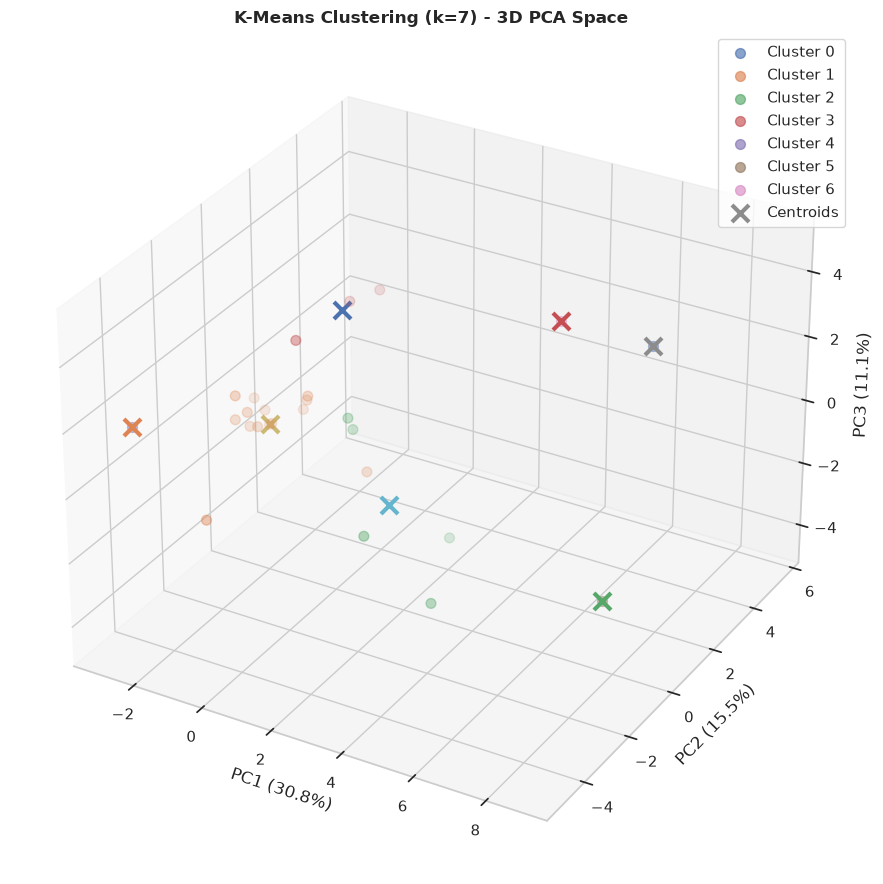

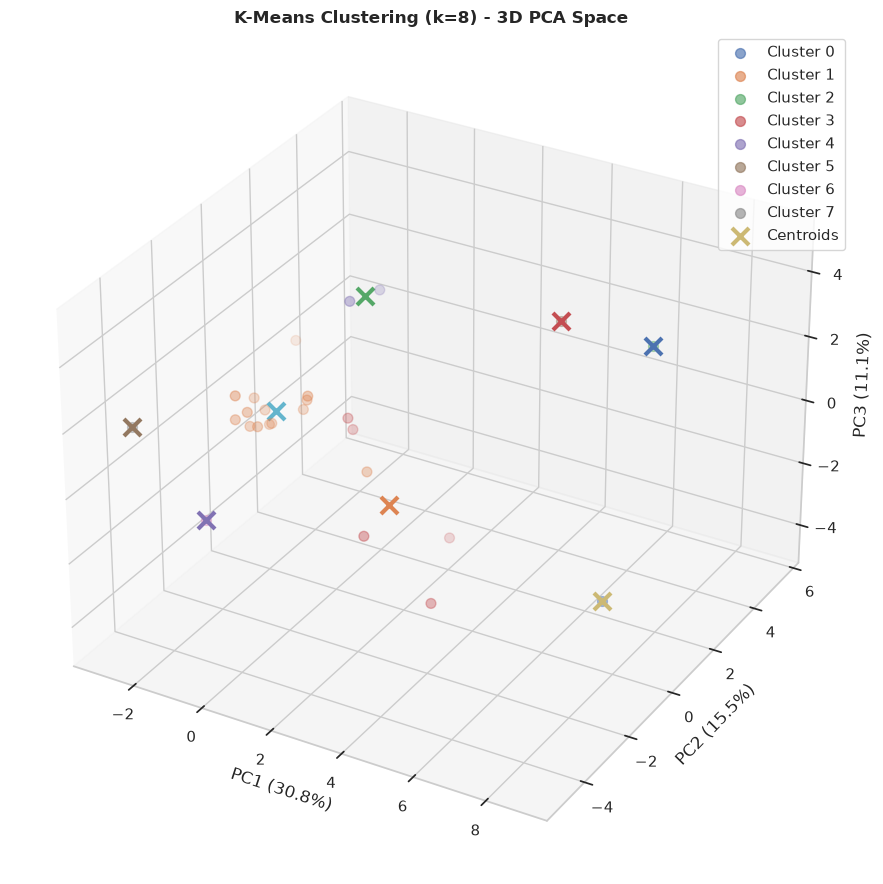

In [23]:
# 3D views are only visualizations; clustering still uses all retained PCA components.
for k_3d in [7, 8]:
    kmeans_3d_plot(k_3d, df_pca, y, pca)

In [33]:
#DBSCAN FOR OUTLIERS
#EPSILON IS TAKEN BY MSE in KMEANS
def dbscan_analysis_outliers(eps,X_db,domains,min_samples=3):
  db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_db)
  labels = db.labels_

  # core / border / noise
  core_mask = np.zeros_like(labels, dtype=bool)
  core_mask[db.core_sample_indices_] = True

  noise_mask  = labels == -1
  border_mask = (~core_mask) & (labels != -1)

  print("n_clusters:", len(set(labels)) - (1 if -1 in set(labels) else 0))
  print("noise points:", noise_mask.sum())
  print("core points:", core_mask.sum())
  print("border points:", border_mask.sum())

  # Outlier list (noise)
  outlier_domains = domains[noise_mask]
  print("\nDBSCAN outliers (noise, label=-1):")
  print(outlier_domains.tolist())

  #find score (based on distance)
  core_points = X_db[core_mask]
  nn = NearestNeighbors(n_neighbors=1).fit(core_points)
  dists, _ = nn.kneighbors(X_db)
  outlier_score = dists[:, 0]


  out_df = pd.DataFrame({
      "domain": domains,
      "label": labels,
      "is_noise": noise_mask,
      "is_border": border_mask,
      "outlier_score": outlier_score
  }).sort_values("outlier_score", ascending=False)

  print("\nTop-10 by outlier_score:")
  print(out_df.head(10))


In [34]:
#run db
domains = y            # array dei domini (index)

eps = 5.7           #circa avarage of mse in kmeans, distanza dei punti dai centroidi, trovare gli outliers
min_samples = 3     #resaonable number for 26 domain

dbscan_analysis_outliers(eps,df_pca,y,min_samples)

n_clusters: 1
noise points: 5
core points: 20
border points: 1

DBSCAN outliers (noise, label=-1):
['_other', 'fastly-insights.com', 'ftcdn.net', 'scdn.co', 'vimeocdn.com']

Top-10 by outlier_score:
                 domain  label  is_noise  is_border  outlier_score
25         vimeocdn.com     -1      True      False      10.845602
0                _other     -1      True      False       8.862413
19              scdn.co     -1      True      False       7.885597
7   fastly-insights.com     -1      True      False       7.535996
9             ftcdn.net     -1      True      False       6.163760
18           reddit.com      0     False       True       5.616852
5            disqus.com      0     False      False       0.000000
1             adnxs.com      0     False      False       0.000000
2       ads-twitter.com      0     False      False       0.000000
3         chartbeat.com      0     False      False       0.000000


In [35]:
def plot_dendrogram_cut(Z, labels, k, figsize=(14, 5)):
    # soglia che produce ~k cluster: taglia appena sotto l'ultima fusione che ridurrebbe a k-1
    thr = Z[-(k-1), 2] - 1e-12

    plt.figure(figsize=figsize)
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=thr,          # <-- colora i cluster sotto la soglia
        above_threshold_color="grey"  # <-- sopra soglia tutto grigio
    )
    plt.axhline(thr, linestyle="--", linewidth=1)
    plt.title(f"Hierarchical dendrogram (Ward) — cut at k={k}")
    plt.xlabel("Domain")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig("hier_plt_cut.png")
    plt.show()

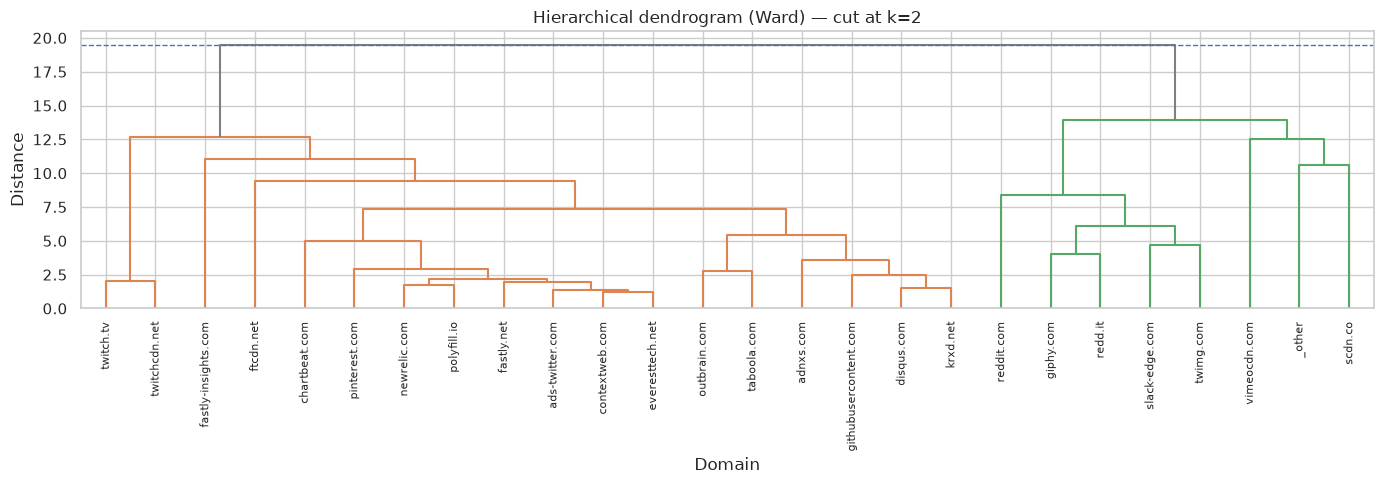

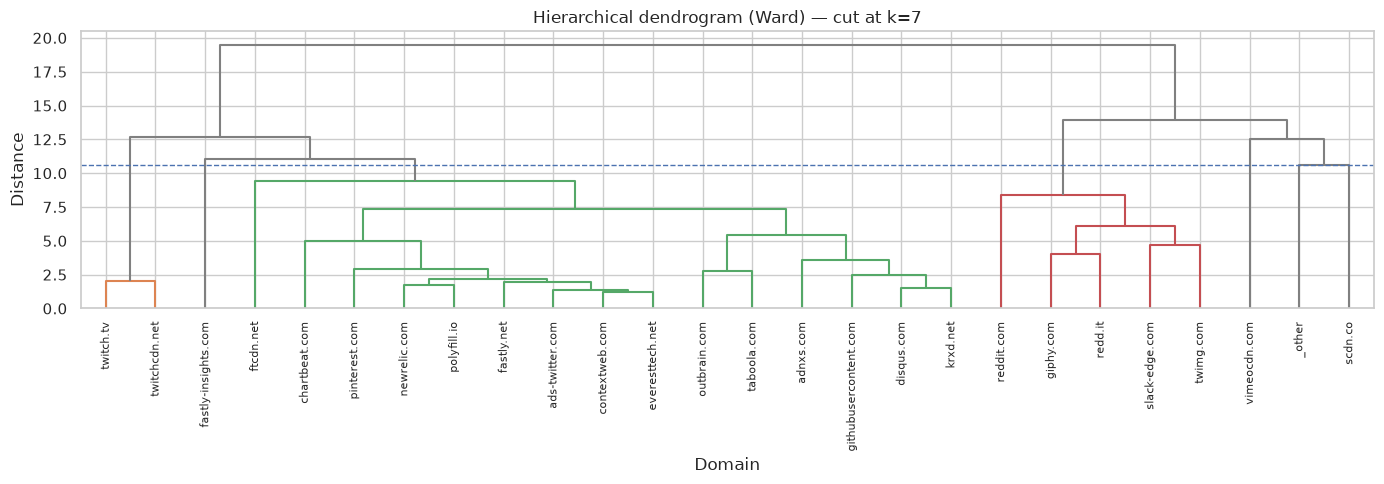

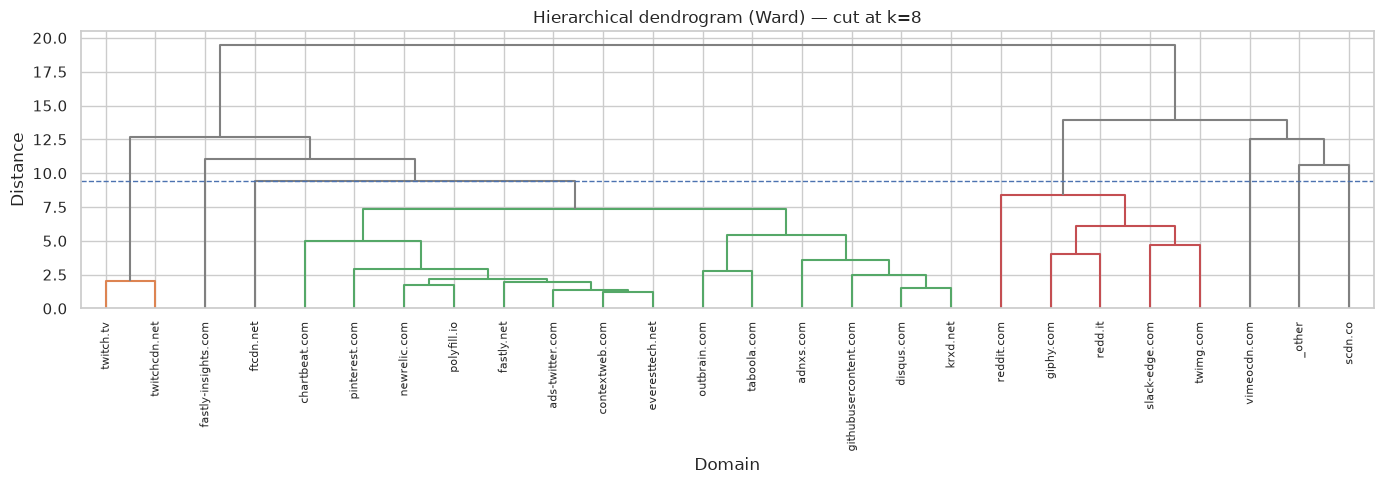

In [36]:


X_h = df_pca
labels = y  # domini
# Linkage (Ward)
Z = linkage(X_h, method="ward")
# solo le visive richieste
for k in [2, 7, 8]:
    plot_dendrogram_cut(Z, labels, k)


In [37]:
##DATA ANALYSIS PRINTING
display(df_grouped.head(5))


,_c_bytes_all_mean,_c_bytes_all_std,_c_bytes_all_max,_s_bytes_all_mean,_s_bytes_all_std,_s_bytes_all_max,_c_pkts_all_mean,_c_pkts_all_std,_s_pkts_all_mean,_s_pkts_all_std,_c_rtt_avg_mean,_c_rtt_avg_std,_c_rtt_avg_min,_c_rtt_avg_max,_s_rtt_avg_mean,_s_rtt_avg_std,_s_rtt_avg_min,_s_rtt_avg_max,_durat_mean,_durat_max,_durat_std,_c_pkts_retx_mean,_s_pkts_retx_mean,_s_rst_cnt_mean,_s_mss_max,_s_win_scl_max,_c_msgsize1_mean,_c_pkts_ooo_mean,_s_pkts_ooo_mean,_tls_session_stat_mean,c_ip_count,intLabel
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
_other,9445.071545,223338.429568,23940605.0,439105.069008,5.065862e+06,454976161.0,136.653023,1229.730622,339.551549,3693.239327,6.493417,6.689423,1.031149,476.015199,325.875353,2547.790973,0.000000,88816.387472,145383.631219,6.240620e+07,448901.498511,1.645612,1.506998,0.002024,1460.0,9.0,435.610581,0.015763,0.001767,0.733546,35083,1
adnxs.com,4489.840323,5993.242048,67822.0,31287.114092,1.278877e+05,3834831.0,21.932795,36.547323,31.684293,92.944586,5.701455,11.957824,1.088589,661.715828,329.285696,2688.876804,0.009000,100545.060498,87006.696000,1.119519e+06,131996.643566,1.660589,0.257880,0.007554,1396.0,9.0,450.405314,0.008856,0.000000,0.730138,3839,2
ads-twitter.com,1107.427170,981.385348,22792.0,4470.772075,2.285979e+03,23348.0,17.438491,11.502602,15.526038,10.734659,8.019453,4.700377,1.300623,44.686316,846.103698,4557.573978,0.007000,78986.942826,202169.117375,1.685377e+06,264375.747593,2.413585,0.218113,0.000000,1396.0,9.0,467.826415,0.000755,0.000000,0.824151,1325,3
chartbeat.com,1215.562633,573.558227,10161.0,4787.627035,3.175029e+03,25828.0,18.968861,21.436655,17.060863,23.083154,8.577467,3.306822,1.812136,29.522762,2453.766509,7381.796370,0.009333,87986.127097,238804.558303,1.848831e+07,725710.401458,2.210191,0.208776,0.000000,1396.0,9.0,465.333333,0.003539,0.000000,0.808917,1413,4
contextweb.com,2117.134207,2961.165766,107476.0,4855.751771,4.311994e+03,165696.0,15.026558,9.953043,13.050637,7.983816,7.728039,5.307615,1.595280,50.061599,550.519781,3178.983924,0.000000,49495.715809,147210.311608,2.698993e+06,175863.225011,2.599150,0.139873,0.015581,1396.0,9.0,454.323654,0.001062,0.000000,0.782578,2824,5


Cluster distribution
cluster
Tracker       13
Noisy          5
Social         5
liveStream     3
Name: count, dtype: int64
Feature axis X: c_ip_count


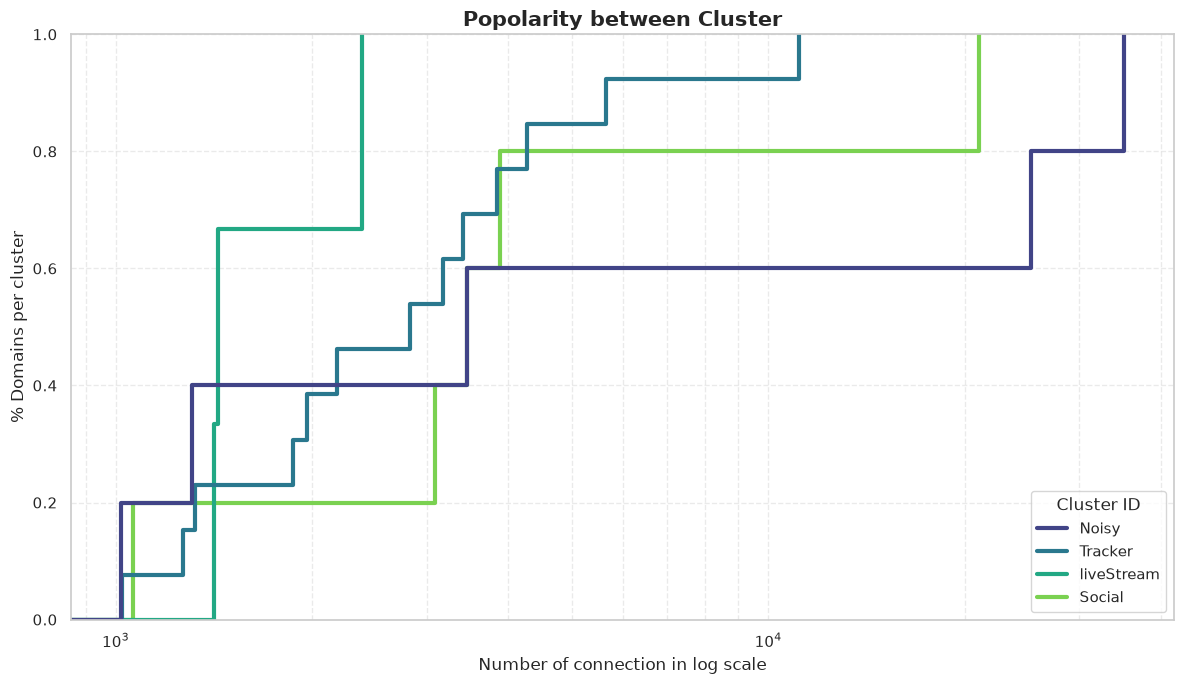

In [38]:
#add feature cluster (standard value -1)
df_grouped['cluster'] = -1
df_grouped['cluster'] = df_grouped['cluster'].astype(str)

#define the cluster
cluster_1_social = ['giphy.com', 'redd.it', 'reddit.com', 'slack-edge.com', 'taboola.com']
cluster_2_stream = ['chartbeat.com', 'twitch.tv', 'twitchcdn.net']
cluster_4_adtech = ['adnxs.com', 'ads-twitter.com', 'contextweb.com', 'disqus.com',
                    'everesttech.net', 'fastly.net', 'githubusercontent.com', 'krxd.net',
                    'newrelic.com', 'outbrain.com', 'pinterest.com', 'polyfill.io', 'twimg.com']
cluster_outliers =['vimeocdn.com', 'scdn.co', 'fastly-insights.com', 'ftcdn.net', '_other']


#set the value to ["cluser"]
valid_c1 = [d for d in cluster_1_social if d in df_grouped.index]
df_grouped.loc[valid_c1, 'cluster'] = "Social"

valid_c2 = [d for d in cluster_2_stream if d in df_grouped.index]
df_grouped.loc[valid_c2, 'cluster'] = "liveStream"

valid_c4 = [d for d in cluster_4_adtech if d in df_grouped.index]
df_grouped.loc[valid_c4, 'cluster'] = "Tracker"

valid_cO= [d for d in cluster_outliers if d in df_grouped.index]
df_grouped.loc[valid_cO, 'cluster'] = "Noisy"

print("Cluster distribution")
print(df_grouped['cluster'].value_counts())


#work on copy
df_plot = df_grouped[df_grouped['cluster'] != -1].copy()


#df_plot['cluster_label'] = df_plot['cluster'].astype(str)

plt.figure(figsize=(12, 7))

if 'c_ip_count' in df_grouped.columns:
    col_target = 'c_ip_count'
elif 'c_ip' in df_grouped.columns:
    col_target = 'c_ip'
else:
    cols = [c for c in df_grouped.columns if 'c_ip' in c]
    col_target = cols[0] if cols else df_grouped.columns[-1]

print(f"Feature axis X: {col_target}")

ax = sns.ecdfplot(
    data=df_plot,
    x=col_target,
    hue='cluster',
    palette='viridis',
    linewidth=3,
    stat='proportion'
)

plt.xscale('log')
plt.title(f'Popolarity between Cluster', fontsize=15, fontweight='bold')
plt.xlabel('Number of connection in log scale', fontsize=12)
plt.ylabel('% Domains per cluster', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.4)

try:
    sns.move_legend(ax, "lower right", title='Cluster ID')
except:
    pass

plt.tight_layout()
plt.savefig("ECDFCLUSTERCONN.png")
plt.show()

=== Cluster Sizes ===


,Cluster_ID,Domain_Count
0,Tracker,13
1,Noisy,5
2,Social,5
3,liveStream,3


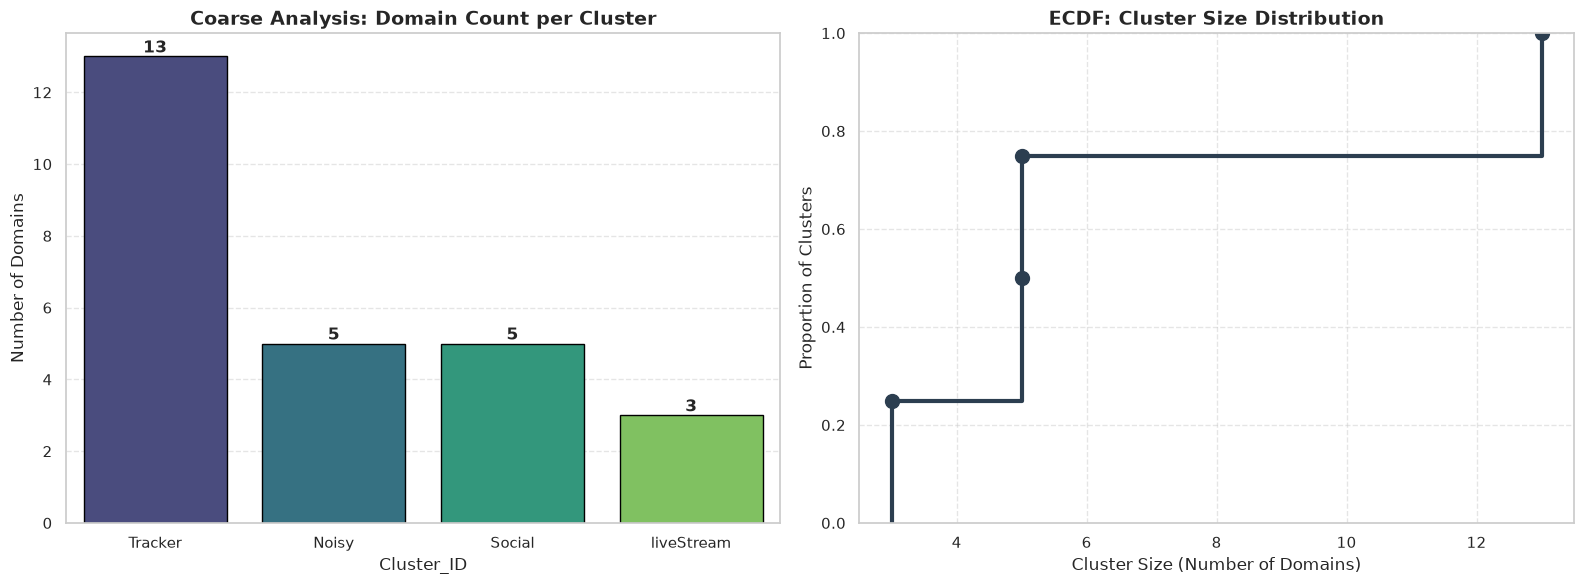

In [39]:
cluster_sizes = df_grouped['cluster'].value_counts().reset_index()
cluster_sizes.columns = ['Cluster_ID', 'Domain_Count']

print("=== Cluster Sizes ===")
display(cluster_sizes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    ax=axes[0],
    data=cluster_sizes,
    x='Cluster_ID',
    y='Domain_Count',
    palette='viridis',
    edgecolor='black'
)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Coarse Analysis: Domain Count per Cluster', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Domains', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.ecdfplot(
    ax=axes[1],
    data=cluster_sizes,
    x='Domain_Count',
    linewidth=3,
    color='#2c3e50',
    marker='o',
    markersize=10
)

axes[1].set_title('ECDF: Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster Size (Number of Domains)', fontsize=12)
axes[1].set_ylabel('Proportion of Clusters', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

from matplotlib.ticker import MaxNLocator
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Regression - Estimating Server Bytes and RTT

In [40]:
REGRESSION_TUNING_SAMPLE = None
REGRESSION_RF_MAX_TRAIN_ROWS = None
REGRESSION_PLOT_SAMPLE = min(PLOT_SAMPLE, 12_000)


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def sample_regression_training_data(X, y, max_rows=None, random_state=RANDOM_STATE):
    if max_rows is None or len(X) <= max_rows:
        return X, y

    sample_idx = np.random.default_rng(random_state).choice(len(X), size=max_rows, replace=False)
    if isinstance(X, pd.DataFrame):
        X_sample = X.iloc[sample_idx]
    else:
        X_sample = X[sample_idx]

    if isinstance(y, (pd.Series, pd.DataFrame)):
        y_sample = y.iloc[sample_idx]
    else:
        y_sample = y[sample_idx]

    return X_sample, y_sample


def build_regression_dataset(train_df, test_df, target_col, forbidden_cols, remove_zero_target=False, corr_threshold=0.985):
    if target_col not in train_df.columns or target_col not in test_df.columns:
        raise KeyError(f"Target column {target_col} must exist in both train and test data.")

    train_task = train_df.copy()
    test_task = test_df.copy()

    if remove_zero_target:
        train_task = train_task[train_task[target_col] > 0].copy().reset_index(drop=True)
        test_task = test_task[test_task[target_col] > 0].copy().reset_index(drop=True)

    forbidden_existing = [c for c in forbidden_cols if c in train_task.columns]
    y_train_task = train_task[target_col].copy()
    y_test_task = test_task[target_col].copy()

    X_train_task, X_test_task, info = build_model_matrix(
        train_task,
        test_task,
        target_col=target_col,
        drop_cols=set(forbidden_existing) | {target_col},
        corr_threshold=corr_threshold,
    )

    target_stats = pd.DataFrame({
        "split": ["train", "test"],
        "rows": [len(train_task), len(test_task)],
        "target_mean": [y_train_task.mean(), y_test_task.mean()],
        "target_median": [y_train_task.median(), y_test_task.median()],
        "target_p90": [y_train_task.quantile(0.90), y_test_task.quantile(0.90)],
        "target_max": [y_train_task.max(), y_test_task.max()],
    })

    return {
        "X_train": X_train_task,
        "X_test": X_test_task,
        "y_train": y_train_task,
        "y_test": y_test_task,
        "info": info,
        "target_col": target_col,
        "forbidden_cols": forbidden_existing,
        "remove_zero_target": remove_zero_target,
        "train_rows": len(train_task),
        "test_rows": len(test_task),
        "target_stats": target_stats,
    }


def make_default_regression_models():
    return {
        "Lasso": {
            "estimator": TransformedTargetRegressor(
                regressor=Lasso(),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "fit_max_rows": None,
        },
        "Decision Tree": {
            "estimator": TransformedTargetRegressor(
                regressor=DecisionTreeRegressor(random_state=RANDOM_STATE),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "fit_max_rows": None,
        },
        "Random Forest": {
            "estimator": TransformedTargetRegressor(
                regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "fit_max_rows": REGRESSION_RF_MAX_TRAIN_ROWS,
        },
    }


def make_tuned_regression_models():
    return {
        "Lasso": {
            "estimator": TransformedTargetRegressor(
                regressor=Lasso(max_iter=5_000),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "params": {
                "regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
            },
            "fit_max_rows": None,
        },
        "Decision Tree": {
            "estimator": TransformedTargetRegressor(
                regressor=DecisionTreeRegressor(random_state=RANDOM_STATE),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "params": {
                "regressor__max_depth": [8, 16, None],
                "regressor__min_samples_leaf": [5, 25, 75],
            },
            "fit_max_rows": None,
        },
        "Random Forest": {
            "estimator": TransformedTargetRegressor(
                regressor=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
                func=np.log1p,
                inverse_func=np.expm1,
            ),
            "params": {
                "regressor__max_depth": [12, None],
                "regressor__min_samples_leaf": [5, 25],
                "regressor__max_features": ["sqrt", 0.5],
            },
            "fit_max_rows": REGRESSION_RF_MAX_TRAIN_ROWS,
        },
    }


def evaluate_predictions(data, model, task_name, model_name, configuration, fit_rows, best_params=None, cv_score=None):
    pred_train = np.maximum(model.predict(data["X_train"]), 0)
    pred_test = np.maximum(model.predict(data["X_test"]), 0)
    train_metrics = regression_metrics(data["y_train"], pred_train)
    test_metrics = regression_metrics(data["y_test"], pred_test)

    row = {
        "task": task_name,
        "model": model_name,
        "configuration": configuration,
        "fit_rows": fit_rows,
        "train_MAE": train_metrics["MAE"],
        "test_MAE": test_metrics["MAE"],
        "train_RMSE": train_metrics["RMSE"],
        "test_RMSE": test_metrics["RMSE"],
        "train_R2": train_metrics["R2"],
        "test_R2": test_metrics["R2"],
        "R2_gap": train_metrics["R2"] - test_metrics["R2"],
        "test_target_mean": data["y_test"].mean(),
        "test_MAE_over_mean": test_metrics["MAE"] / data["y_test"].mean() if data["y_test"].mean() != 0 else np.nan,
        "cv_neg_MAE": cv_score,
        "best_params": best_params,
    }
    return row, pred_train, pred_test


def evaluate_default_regression_models(data, task_name):
    rows = []
    fitted = {}
    for model_name, config in make_default_regression_models().items():
        X_fit, y_fit = sample_regression_training_data(
            data["X_train"],
            data["y_train"],
            max_rows=config["fit_max_rows"],
        )
        model = clone(config["estimator"])
        print(f"Training default {model_name} for {task_name} on {len(X_fit):,} rows")
        model.fit(X_fit, y_fit)

        row, pred_train, pred_test = evaluate_predictions(
            data=data,
            model=model,
            task_name=task_name,
            model_name=model_name,
            configuration="default",
            fit_rows=len(X_fit),
        )
        rows.append(row)
        fitted[model_name] = {
            "model": model,
            "pred_train": pred_train,
            "pred_test": pred_test,
            "row": row,
        }

    return pd.DataFrame(rows), fitted


def tune_regression_models(data, task_name, sample_size=REGRESSION_TUNING_SAMPLE):
    X_cv, y_cv = sample_regression_training_data(data["X_train"], data["y_train"], max_rows=sample_size)
    print(f"Regression tuning sample for {task_name}: {len(X_cv):,} rows")

    cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    fitted = {}

    for model_name, config in make_tuned_regression_models().items():
        print(f"Tuning {model_name} for {task_name}")
        grid = GridSearchCV(
            estimator=config["estimator"],
            param_grid=config["params"],
            scoring="neg_mean_absolute_error",
            cv=cv,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(X_cv, y_cv)

        X_fit, y_fit = sample_regression_training_data(
            data["X_train"],
            data["y_train"],
            max_rows=config["fit_max_rows"],
        )
        best_model = clone(grid.best_estimator_)
        best_model.fit(X_fit, y_fit)

        row, pred_train, pred_test = evaluate_predictions(
            data=data,
            model=best_model,
            task_name=task_name,
            model_name=model_name,
            configuration="tuned",
            fit_rows=len(X_fit),
            best_params=grid.best_params_,
            cv_score=grid.best_score_,
        )
        rows.append(row)
        fitted[model_name] = {
            "model": best_model,
            "pred_train": pred_train,
            "pred_test": pred_test,
            "row": row,
        }
        print(f"Best params: {grid.best_params_}; test MAE: {row['test_MAE']:.2f}")

    return pd.DataFrame(rows), fitted


def diagnose_fit(row):
    if row["R2_gap"] > 0.20:
        return "overfitting"
    if row["test_R2"] < 0.10 and row["train_R2"] < 0.20:
        return "underfitting"
    if row["test_R2"] < 0:
        return "worse than mean baseline"
    return "reasonable generalization"


def add_regression_diagnosis(table):
    result = table.copy()
    result["fit_diagnosis"] = result.apply(diagnose_fit, axis=1)
    return result


def compare_default_vs_tuned_regression(default_table, tuned_table, task_name, unit):
    comparison = pd.concat([default_table, tuned_table], ignore_index=True)
    comparison = add_regression_diagnosis(comparison)
    display(comparison.sort_values(["configuration", "test_MAE"]))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=comparison, x="model", y="test_MAE", hue="configuration", ax=axes[0])
    axes[0].set_title(f"{task_name}: default vs tuned MAE")
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel(f"Test MAE ({unit})")
    axes[0].tick_params(axis="x", rotation=15)

    sns.barplot(data=comparison, x="model", y="test_R2", hue="configuration", ax=axes[1])
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"{task_name}: default vs tuned R2")
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Test R2")
    axes[1].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    plt.show()
    return comparison


def plot_regression_diagnostics(data, fitted, task_name, unit, configuration):
    selected_name = max(fitted, key=lambda name: fitted[name]["row"]["cv_neg_MAE"])
    pred = fitted[selected_name]["pred_test"]
    y_true = data["y_test"].to_numpy()

    if len(y_true) > REGRESSION_PLOT_SAMPLE:
        idx = np.random.default_rng(RANDOM_STATE).choice(len(y_true), size=REGRESSION_PLOT_SAMPLE, replace=False)
        y_plot = y_true[idx]
        pred_plot = pred[idx]
    else:
        y_plot = y_true
        pred_plot = pred

    residuals = y_plot - pred_plot
    y_plot_positive = np.maximum(y_plot, 1e-9)
    pred_plot_positive = np.maximum(pred_plot, 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_plot_positive, pred_plot_positive, s=12, alpha=0.35)
    min_v = min(y_plot_positive.min(), pred_plot_positive.min())
    max_v = max(y_plot_positive.max(), pred_plot_positive.max())
    axes[0].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_title(f"{task_name}: predictions vs true ({selected_name}, {configuration})")
    axes[0].set_xlabel(f"True value ({unit}, log scale)")
    axes[0].set_ylabel(f"Predicted value ({unit}, log scale)")

    axes[1].scatter(pred_plot_positive, residuals, s=12, alpha=0.35, color="darkorange")
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_xscale("log")
    axes[1].set_title(f"{task_name}: residuals ({selected_name}, {configuration})")
    axes[1].set_xlabel(f"Predicted value ({unit}, log scale)")
    axes[1].set_ylabel(f"Residual ({unit})")

    plt.tight_layout()
    plt.show()

    return selected_name


### Default Models And Hyperparameter Tuning

The default stage fits the three requested regressors without tuning their main modelling hyperparameters, then evaluates them on both training and test sets. The train-test `R2` gap is used to identify overfitting, while low train and test `R2` indicates underfitting.

The tuning stage uses shuffled 3-fold cross-validation and `neg_mean_absolute_error`, because the project explicitly asks to compare Mean Absolute Error. The final run uses every task-specific training row in cross-validation and refits each selected configuration on the complete training set. The tuned Random Forest keeps 100 trees, matching the default ensemble size, so the comparison isolates the searched depth, leaf-size and feature-sampling parameters. Model selection uses CV MAE only; the official test metrics are reported after selection.


REGRESSION TASK 1: PREDICTING _s_bytes_all
Rows - train: 147,863, test: 114,580
Features after leakage guard and correlation pruning: 88
Explicit leakage/forbidden columns removed: ['_s_bytes_uniq', '_s_appdataB']


,split,rows,target_mean,target_median,target_p90,target_max
0,train,147863,359310.891859,7617.0,268364.8,4.549762e+08
1,test,114580,346466.436804,7170.0,186259.9,2.623575e+09


Training default Lasso for _s_bytes_all on 147,863 rows
Training default Decision Tree for _s_bytes_all on 147,863 rows
Training default Random Forest for _s_bytes_all on 147,863 rows


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
0,_s_bytes_all,Lasso,default,147863,343965.380628,334364.748492,4.005185e+06,9.281318e+06,0.006684,0.003851,0.002834,346466.436804,0.965071,None,None,underfitting
1,_s_bytes_all,Decision Tree,default,147863,0.000014,44010.843865,2.600580e-03,7.718738e+06,1.000000,0.311034,0.688966,346466.436804,0.127028,None,None,overfitting
2,_s_bytes_all,Random Forest,default,147863,2642.303652,37462.965183,3.427329e+05,7.286076e+06,0.992726,0.386107,0.606619,346466.436804,0.108129,None,None,overfitting


Regression tuning sample for _s_bytes_all: 147,863 rows
Tuning Lasso for _s_bytes_all
Best params: {'regressor__alpha': 0.0001}; test MAE: 23888.77
Tuning Decision Tree for _s_bytes_all
Best params: {'regressor__max_depth': 16, 'regressor__min_samples_leaf': 5}; test MAE: 43433.13
Tuning Random Forest for _s_bytes_all
Best params: {'regressor__max_depth': 12, 'regressor__max_features': 0.5, 'regressor__min_samples_leaf': 5}; test MAE: 46481.46


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
0,_s_bytes_all,Lasso,tuned,147863,19658.406095,23888.770855,345028.337580,1.090812e+06,0.992629,0.986240,0.006388,346466.436804,0.068950,-19679.786604,{'regressor__alpha': 0.0001},reasonable generalization
1,_s_bytes_all,Decision Tree,tuned,147863,6084.045802,43433.131540,650317.870378,7.403349e+06,0.973813,0.366186,0.607626,346466.436804,0.125360,-12079.688413,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting
2,_s_bytes_all,Random Forest,tuned,147863,7161.880752,46481.462557,798060.772366,7.747562e+06,0.960562,0.305879,0.654683,346466.436804,0.134159,-10970.177135,"{'regressor__max_depth': 12, 'regressor__max_f...",overfitting


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
2,_s_bytes_all,Random Forest,default,147863,2642.303652,37462.965183,3.427329e+05,7.286076e+06,0.992726,0.386107,0.606619,346466.436804,0.108129,None,None,overfitting
1,_s_bytes_all,Decision Tree,default,147863,0.000014,44010.843865,2.600580e-03,7.718738e+06,1.000000,0.311034,0.688966,346466.436804,0.127028,None,None,overfitting
0,_s_bytes_all,Lasso,default,147863,343965.380628,334364.748492,4.005185e+06,9.281318e+06,0.006684,0.003851,0.002834,346466.436804,0.965071,None,None,underfitting
3,_s_bytes_all,Lasso,tuned,147863,19658.406095,23888.770855,3.450283e+05,1.090812e+06,0.992629,0.986240,0.006388,346466.436804,0.068950,-19679.786604,{'regressor__alpha': 0.0001},reasonable generalization
4,_s_bytes_all,Decision Tree,tuned,147863,6084.045802,43433.131540,6.503179e+05,7.403349e+06,0.973813,0.366186,0.607626,346466.436804,0.125360,-12079.688413,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting
5,_s_bytes_all,Random Forest,tuned,147863,7161.880752,46481.462557,7.980608e+05,7.747562e+06,0.960562,0.305879,0.654683,346466.436804,0.134159,-10970.177135,"{'regressor__max_depth': 12, 'regressor__max_f...",overfitting


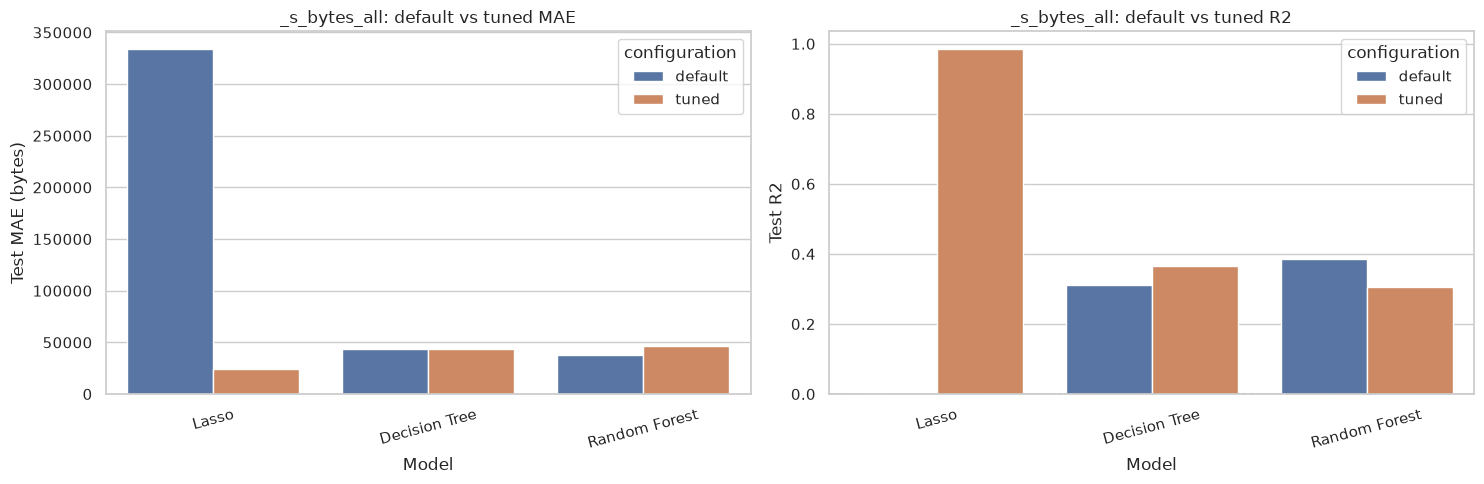

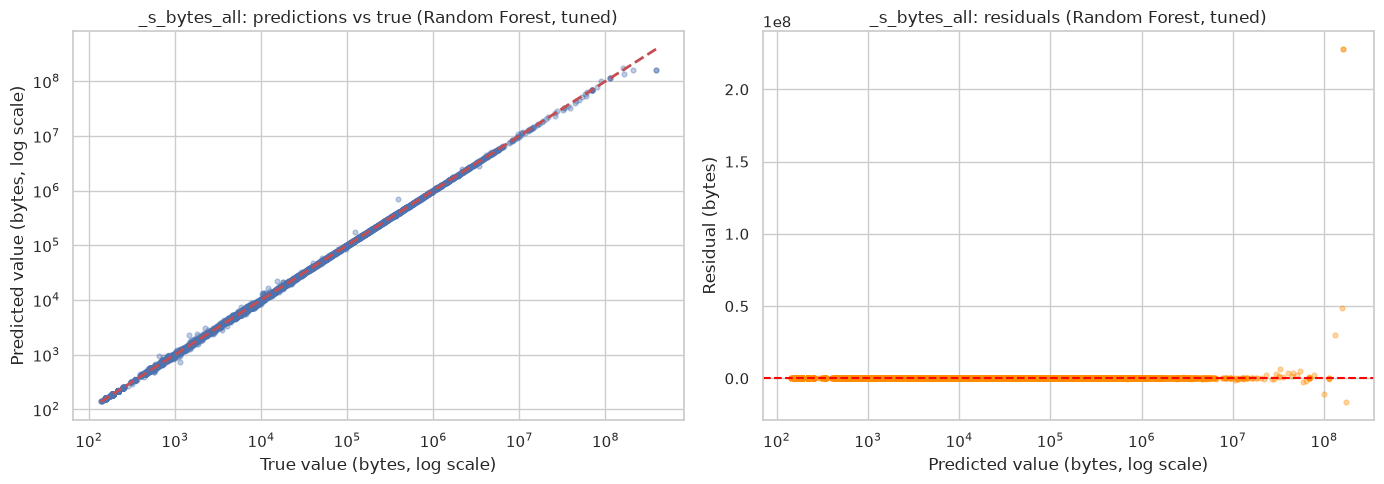

CV-selected tuned model for _s_bytes_all: Random Forest


In [41]:
bytes_forbidden = ["_s_bytes_uniq", "_s_appdataB"]
bytes_data = build_regression_dataset(
    train_clean,
    test_clean,
    target_col="_s_bytes_all",
    forbidden_cols=bytes_forbidden,
    remove_zero_target=False,
)

print("=" * 80)
print("REGRESSION TASK 1: PREDICTING _s_bytes_all")
print("=" * 80)
print(f"Rows - train: {bytes_data['train_rows']:,}, test: {bytes_data['test_rows']:,}")
print(f"Features after leakage guard and correlation pruning: {bytes_data['X_train'].shape[1]}")
print(f"Explicit leakage/forbidden columns removed: {bytes_data['forbidden_cols']}")
display(bytes_data["target_stats"])

bytes_default_table, bytes_default_fitted = evaluate_default_regression_models(
    bytes_data,
    "_s_bytes_all",
)
display(add_regression_diagnosis(bytes_default_table))

bytes_tuned_table, bytes_tuned_fitted = tune_regression_models(
    bytes_data,
    "_s_bytes_all",
)
display(add_regression_diagnosis(bytes_tuned_table))

bytes_model_comparison = compare_default_vs_tuned_regression(
    bytes_default_table,
    bytes_tuned_table,
    "_s_bytes_all",
    "bytes",
)

best_bytes_model = plot_regression_diagnostics(
    bytes_data,
    bytes_tuned_fitted,
    "_s_bytes_all",
    "bytes",
    "tuned",
)
print(f"CV-selected tuned model for _s_bytes_all: {best_bytes_model}")


REGRESSION TASK 2: PREDICTING _s_rtt_avg
Rows after removing zero RTT - train: 147,832, test: 114,555
Features after leakage guard and correlation pruning: 80
RTT-related columns removed: ['_c_rtt_avg', '_c_rtt_cnt', '_c_rtt_max', '_c_rtt_min', '_c_rtt_std', '_s_rtt_cnt', '_s_rtt_max', '_s_rtt_min', '_s_rtt_std']


,split,rows,target_mean,target_median,target_p90,target_max
0,train,147832,426.453624,9.906368,75.505356,100682.272924
1,test,114555,511.033490,9.115155,87.754215,116853.665161


Training default Lasso for _s_rtt_avg on 147,832 rows
Training default Decision Tree for _s_rtt_avg on 147,832 rows
Training default Random Forest for _s_rtt_avg on 147,832 rows


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
0,_s_rtt_avg,Lasso,default,147832,4.223390e+02,507.755904,3.081313e+03,3212.495683,-0.01833,-0.024619,0.006289,511.03349,0.993586,None,None,underfitting
1,_s_rtt_avg,Decision Tree,default,147832,1.793829e-13,507.445776,1.588177e-12,2989.104943,1.00000,0.112927,0.887073,511.03349,0.992979,None,None,overfitting
2,_s_rtt_avg,Random Forest,default,147832,1.842303e+02,377.188597,1.640078e+03,2638.568217,0.71150,0.308784,0.402716,511.03349,0.738090,None,None,overfitting


Regression tuning sample for _s_rtt_avg: 147,832 rows
Tuning Lasso for _s_rtt_avg
Best params: {'regressor__alpha': 0.01}; test MAE: 501.16
Tuning Decision Tree for _s_rtt_avg
Best params: {'regressor__max_depth': 16, 'regressor__min_samples_leaf': 5}; test MAE: 390.93
Tuning Random Forest for _s_rtt_avg
Best params: {'regressor__max_depth': None, 'regressor__max_features': 0.5, 'regressor__min_samples_leaf': 5}; test MAE: 399.88


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
0,_s_rtt_avg,Lasso,tuned,147832,415.989783,501.162531,3071.354453,3241.203302,-0.011758,-0.043013,0.031255,511.03349,0.980684,-415.901850,{'regressor__alpha': 0.01},underfitting
1,_s_rtt_avg,Decision Tree,tuned,147832,194.184735,390.929546,1691.593191,2569.944179,0.693092,0.344271,0.348821,511.03349,0.764978,-288.964077,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting
2,_s_rtt_avg,Random Forest,tuned,147832,259.758280,399.877182,2140.708965,2764.148265,0.508490,0.241423,0.267068,511.03349,0.782487,-310.316042,"{'regressor__max_depth': None, 'regressor__max...",overfitting


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis
2,_s_rtt_avg,Random Forest,default,147832,1.842303e+02,377.188597,1.640078e+03,2638.568217,0.711500,0.308784,0.402716,511.03349,0.738090,None,None,overfitting
1,_s_rtt_avg,Decision Tree,default,147832,1.793829e-13,507.445776,1.588177e-12,2989.104943,1.000000,0.112927,0.887073,511.03349,0.992979,None,None,overfitting
0,_s_rtt_avg,Lasso,default,147832,4.223390e+02,507.755904,3.081313e+03,3212.495683,-0.018330,-0.024619,0.006289,511.03349,0.993586,None,None,underfitting
4,_s_rtt_avg,Decision Tree,tuned,147832,1.941847e+02,390.929546,1.691593e+03,2569.944179,0.693092,0.344271,0.348821,511.03349,0.764978,-288.964077,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting
5,_s_rtt_avg,Random Forest,tuned,147832,2.597583e+02,399.877182,2.140709e+03,2764.148265,0.508490,0.241423,0.267068,511.03349,0.782487,-310.316042,"{'regressor__max_depth': None, 'regressor__max...",overfitting
3,_s_rtt_avg,Lasso,tuned,147832,4.159898e+02,501.162531,3.071354e+03,3241.203302,-0.011758,-0.043013,0.031255,511.03349,0.980684,-415.90185,{'regressor__alpha': 0.01},underfitting


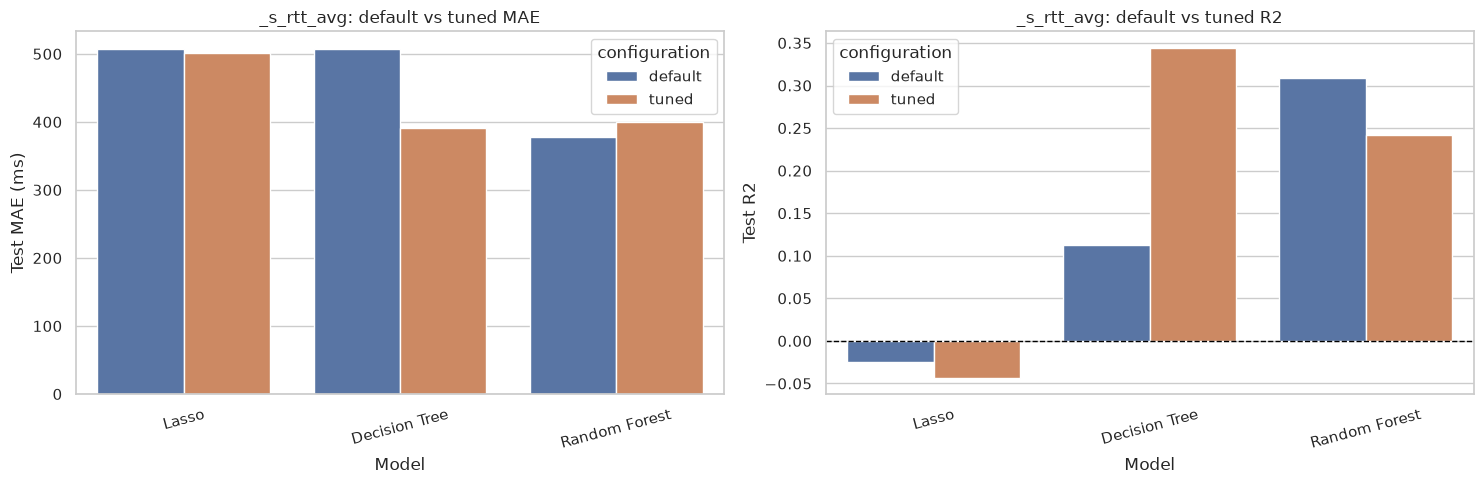

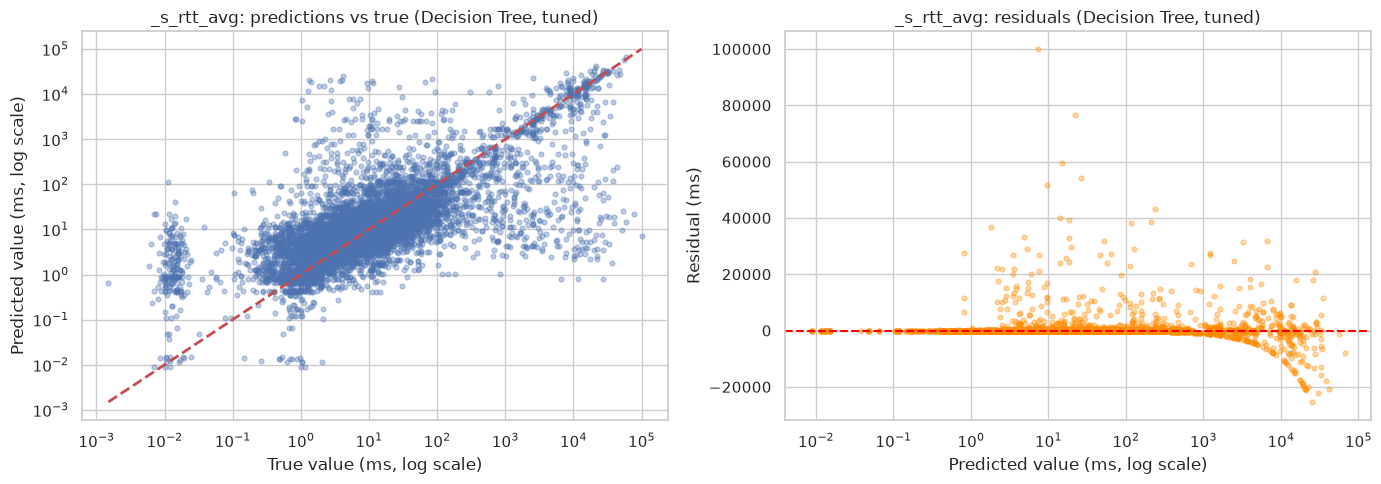

CV-selected tuned model for _s_rtt_avg: Decision Tree


In [42]:
rtt_forbidden = [c for c in numeric_feature_columns(train_clean) if "rtt" in c.lower() and c != "_s_rtt_avg"]
rtt_data = build_regression_dataset(
    train_clean,
    test_clean,
    target_col="_s_rtt_avg",
    forbidden_cols=rtt_forbidden,
    remove_zero_target=True,
)

print("=" * 80)
print("REGRESSION TASK 2: PREDICTING _s_rtt_avg")
print("=" * 80)
print(f"Rows after removing zero RTT - train: {rtt_data['train_rows']:,}, test: {rtt_data['test_rows']:,}")
print(f"Features after leakage guard and correlation pruning: {rtt_data['X_train'].shape[1]}")
print(f"RTT-related columns removed: {rtt_data['forbidden_cols']}")
display(rtt_data["target_stats"])

rtt_default_table, rtt_default_fitted = evaluate_default_regression_models(
    rtt_data,
    "_s_rtt_avg",
)
display(add_regression_diagnosis(rtt_default_table))

rtt_tuned_table, rtt_tuned_fitted = tune_regression_models(
    rtt_data,
    "_s_rtt_avg",
)
display(add_regression_diagnosis(rtt_tuned_table))

rtt_model_comparison = compare_default_vs_tuned_regression(
    rtt_default_table,
    rtt_tuned_table,
    "_s_rtt_avg",
    "ms",
)

best_rtt_model = plot_regression_diagnostics(
    rtt_data,
    rtt_tuned_fitted,
    "_s_rtt_avg",
    "ms",
    "tuned",
)
print(f"CV-selected tuned model for _s_rtt_avg: {best_rtt_model}")


,task,model,configuration,fit_rows,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,R2_gap,test_target_mean,test_MAE_over_mean,cv_neg_MAE,best_params,fit_diagnosis,unit
2,_s_bytes_all,Random Forest,default,147863,2.642304e+03,37462.965183,3.427329e+05,7.286076e+06,0.992726,0.386107,0.606619,346466.436804,0.108129,None,None,overfitting,bytes
1,_s_bytes_all,Decision Tree,default,147863,1.352634e-05,44010.843865,2.600580e-03,7.718738e+06,1.000000,0.311034,0.688966,346466.436804,0.127028,None,None,overfitting,bytes
0,_s_bytes_all,Lasso,default,147863,3.439654e+05,334364.748492,4.005185e+06,9.281318e+06,0.006684,0.003851,0.002834,346466.436804,0.965071,None,None,underfitting,bytes
3,_s_bytes_all,Lasso,tuned,147863,1.965841e+04,23888.770855,3.450283e+05,1.090812e+06,0.992629,0.986240,0.006388,346466.436804,0.068950,-19679.786604,{'regressor__alpha': 0.0001},reasonable generalization,bytes
4,_s_bytes_all,Decision Tree,tuned,147863,6.084046e+03,43433.131540,6.503179e+05,7.403349e+06,0.973813,0.366186,0.607626,346466.436804,0.125360,-12079.688413,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting,bytes
5,_s_bytes_all,Random Forest,tuned,147863,7.161881e+03,46481.462557,7.980608e+05,7.747562e+06,0.960562,0.305879,0.654683,346466.436804,0.134159,-10970.177135,"{'regressor__max_depth': 12, 'regressor__max_f...",overfitting,bytes
8,_s_rtt_avg,Random Forest,default,147832,1.842303e+02,377.188597,1.640078e+03,2.638568e+03,0.711500,0.308784,0.402716,511.033490,0.738090,None,None,overfitting,ms
7,_s_rtt_avg,Decision Tree,default,147832,1.793829e-13,507.445776,1.588177e-12,2.989105e+03,1.000000,0.112927,0.887073,511.033490,0.992979,None,None,overfitting,ms
6,_s_rtt_avg,Lasso,default,147832,4.223390e+02,507.755904,3.081313e+03,3.212496e+03,-0.018330,-0.024619,0.006289,511.033490,0.993586,None,None,underfitting,ms
10,_s_rtt_avg,Decision Tree,tuned,147832,1.941847e+02,390.929546,1.691593e+03,2.569944e+03,0.693092,0.344271,0.348821,511.033490,0.764978,-288.964077,"{'regressor__max_depth': 16, 'regressor__min_s...",overfitting,ms


,task,model,configuration,fit_rows,cv_MAE,test_MAE,test_RMSE,test_R2,test_MAE_over_mean,R2_gap,fit_diagnosis,unit
0,_s_bytes_all,Random Forest,tuned,147863,10970.177135,46481.462557,7.747562e+06,0.305879,0.134159,0.654683,overfitting,bytes
1,_s_rtt_avg,Decision Tree,tuned,147832,288.964077,390.929546,2.569944e+03,0.344271,0.764978,0.348821,overfitting,ms


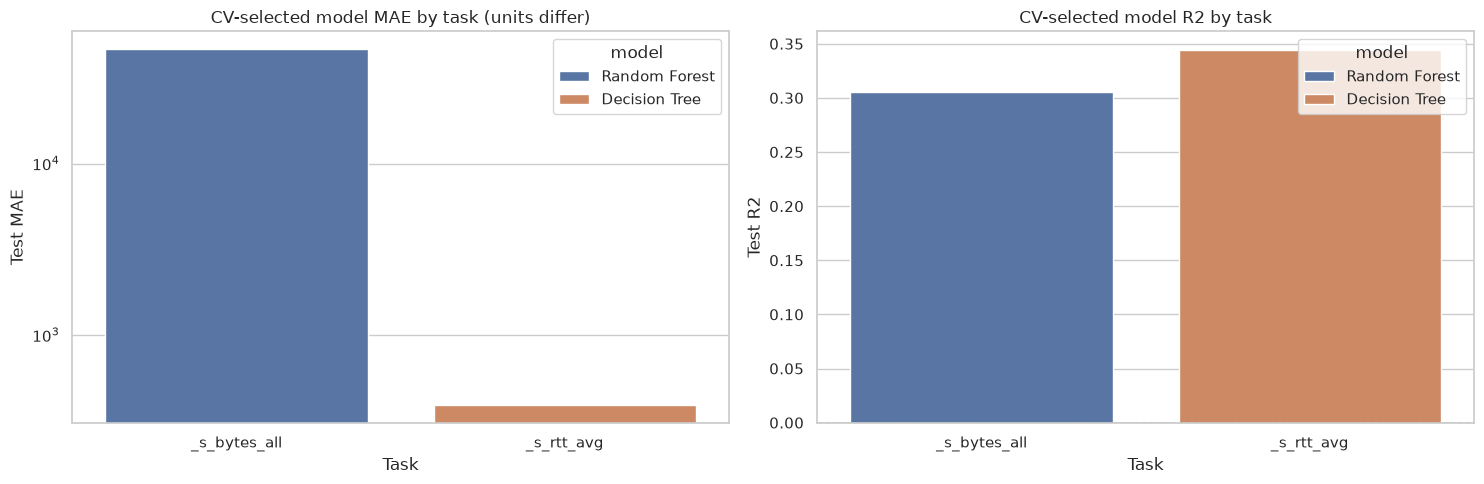

Higher absolute MAE: _s_bytes_all, measured in bytes.
Absolute MAE values use different units, so they should not be compared as if they were on the same scale.
Easier task by CV-selected model test R2: _s_rtt_avg. Harder task: _s_bytes_all.
In this dataset, bytes are usually easier when their R2 is higher because payload size is directly related to other flow counters; RTT is harder when its R2 remains low because latency is driven by external network conditions.


In [43]:
regression_comparison = pd.concat(
    [bytes_default_table, bytes_tuned_table, rtt_default_table, rtt_tuned_table],
    ignore_index=True,
)
regression_comparison = add_regression_diagnosis(regression_comparison)
regression_comparison["unit"] = regression_comparison["task"].map({
    "_s_bytes_all": "bytes",
    "_s_rtt_avg": "ms",
})

display(regression_comparison.sort_values(["task", "configuration", "test_MAE"]))

def select_tuned_model_by_cv(tuned_table):
    ranked = add_regression_diagnosis(tuned_table)
    ranked = ranked.assign(cv_MAE=-ranked["cv_neg_MAE"])
    return ranked.sort_values("cv_MAE").iloc[0]


regression_final_comparison = pd.DataFrame([
    select_tuned_model_by_cv(bytes_tuned_table),
    select_tuned_model_by_cv(rtt_tuned_table),
])[[
    "task", "model", "configuration", "fit_rows", "cv_MAE",
    "test_MAE", "test_RMSE", "test_R2", "test_MAE_over_mean",
    "R2_gap", "fit_diagnosis",
]].reset_index(drop=True)
regression_final_comparison["unit"] = regression_final_comparison["task"].map({
    "_s_bytes_all": "bytes",
    "_s_rtt_avg": "ms",
})
display(regression_final_comparison)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=regression_final_comparison, x="task", y="test_MAE", hue="model", dodge=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("CV-selected model MAE by task (units differ)")
axes[0].set_xlabel("Task")
axes[0].set_ylabel("Test MAE")

sns.barplot(data=regression_final_comparison, x="task", y="test_R2", hue="model", dodge=False, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("CV-selected model R2 by task")
axes[1].set_xlabel("Task")
axes[1].set_ylabel("Test R2")
plt.tight_layout()
plt.show()

bytes_row = regression_final_comparison[regression_final_comparison["task"] == "_s_bytes_all"].iloc[0]
rtt_row = regression_final_comparison[regression_final_comparison["task"] == "_s_rtt_avg"].iloc[0]

if bytes_row["test_MAE"] > rtt_row["test_MAE"]:
    higher_abs = "_s_bytes_all"
    higher_unit = "bytes"
else:
    higher_abs = "_s_rtt_avg"
    higher_unit = "ms"

if bytes_row["test_R2"] >= rtt_row["test_R2"]:
    easier_task = "_s_bytes_all"
    harder_task = "_s_rtt_avg"
else:
    easier_task = "_s_rtt_avg"
    harder_task = "_s_bytes_all"

print(f"Higher absolute MAE: {higher_abs}, measured in {higher_unit}.")
print("Absolute MAE values use different units, so they should not be compared as if they were on the same scale.")
print(f"Easier task by CV-selected model test R2: {easier_task}. Harder task: {harder_task}.")
print("In this dataset, bytes are usually easier when their R2 is higher because payload size is directly related to other flow counters; RTT is harder when its R2 remains low because latency is driven by external network conditions.")
